# WGCNA
weighted gene co-expression network analysis

# Phase 2

following [Hovrath Lab Tutorial](https://www.dropbox.com/scl/fo/4vqfiysan6rlurfo2pbnk/h?dl=0&e=1&preview=Consensus-NetworkConstruction-man.pdf&rlkey=thqg8wlpdn4spu3ihjuc1kmlu)

## 0. load libraries

In [3]:
library(tidyverse)
library(DESeq2)
library(WGCNA)
library(janitor) # for row_to_names()
library(zoo)
library(ComplexHeatmap)
library(circlize)
library(reshape)
library(fastDummies) # create 0/1 factor columns
library(ape) # for read.gff
library(cowplot) # for plot_grid()

In [4]:
# important setting, cannot omit
options(stringsAsFactors = FALSE)

In [5]:
# allow multi-threading within WGCNA
enableWGCNAThreads()

Allowing parallel execution with up to 127 working processes.


In [186]:
set.seed(1)

## 1. structure WGCNA input

**Expected input**:
- Rows = samples
- Columns = genes (or probes/features)
- Values = numeric expression values

### A. format vst normalized counts matrix

In [17]:
# counts matrix
dataExpr <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_rawLFC/deseq_vstCounts.csv')

# set gene name as rowname
rownames(dataExpr) <- dataExpr$X

 
dataExpr <- dataExpr %>% 
select(-X) %>% # remove gene name as column
t() # transpose so samples = rows, genes = columns

head(dataExpr)
dim(dataExpr) # 94 samples x 35466 genes

,LOC111116054,LOC111126949,LOC111110729,LOC111112434,LOC111120752,LOC111128944,LOC111128953,LOC111105691,LOC111133554,LOC111125466,⋯,CYTB,COX2,ATP6,ND2,ND4,ND5,ND6,ND3,ND1,ND4L
B1_B1_O01,7.692872,10.197580,8.354765,7.886383,9.363550,7.548551,7.548551,7.692872,7.548551,7.650623,⋯,18.94773,17.35567,16.72734,16.55278,17.40296,17.50511,15.27334,14.40950,17.08613,13.21049
B1_W5_O50,7.805746,9.653169,8.542687,7.697174,9.355360,7.548551,7.548551,7.845404,7.548551,7.548551,⋯,19.25087,17.60046,17.05547,16.54477,16.97662,17.30129,15.59674,14.95796,17.21506,13.41728
B2_B5_O51,7.871959,9.900281,8.351593,7.548551,9.509373,7.548551,7.548551,8.595408,7.548551,7.651014,⋯,19.41971,17.94342,17.27196,17.23549,17.79404,18.11808,15.98559,15.64247,17.74181,13.77409
B2_C4_O40,7.843091,9.718856,8.513945,7.687586,9.284512,7.548551,7.548551,8.101515,7.843091,7.548551,⋯,18.86611,17.79882,17.27281,16.61824,17.19524,17.19285,15.14694,14.83363,17.01083,13.11047
B3_B4_O41,7.548551,9.612738,8.518601,7.940109,9.198871,7.548551,7.548551,8.014009,7.548551,7.661902,⋯,19.71514,18.17021,17.54836,17.11674,17.49138,17.97654,15.71235,15.28878,17.71717,13.87237
B3_C3_O30,7.909124,9.545333,8.653091,7.989592,9.337765,7.548551,7.710140,8.149132,7.828140,7.926626,⋯,19.27273,17.87689,17.64807,17.08072,17.29751,17.13546,15.58747,15.14063,17.14174,13.28853


[1]    94 35466

### B. identify and remove genes with missing data 
genes with too many NAs or zero-counts

In [18]:
gsg <- goodSamplesGenes(dataExpr, verbose = 3)
gsg$allOK

dataExpr <- dataExpr[gsg$goodSamples, gsg$goodGenes]
dim(dataExpr) # 94 samples x 35396 genes

 Flagging genes and samples with too many missing values...
  ..step 1
  ..Excluding 70 genes from the calculation due to too many missing samples or zero variance.
  ..step 2


[1] FALSE

[1]    94 35396

### C. Sample size and gene filtering

removing low-variance genes first:

In [19]:
dataExpr <- dataExpr[, apply(dataExpr, 2, var) > quantile(apply(dataExpr, 2, var), 0.25)]
dim(dataExpr) # 94 samples x 26547 genes

[1]    94 26547

### D. Sample outlier detection

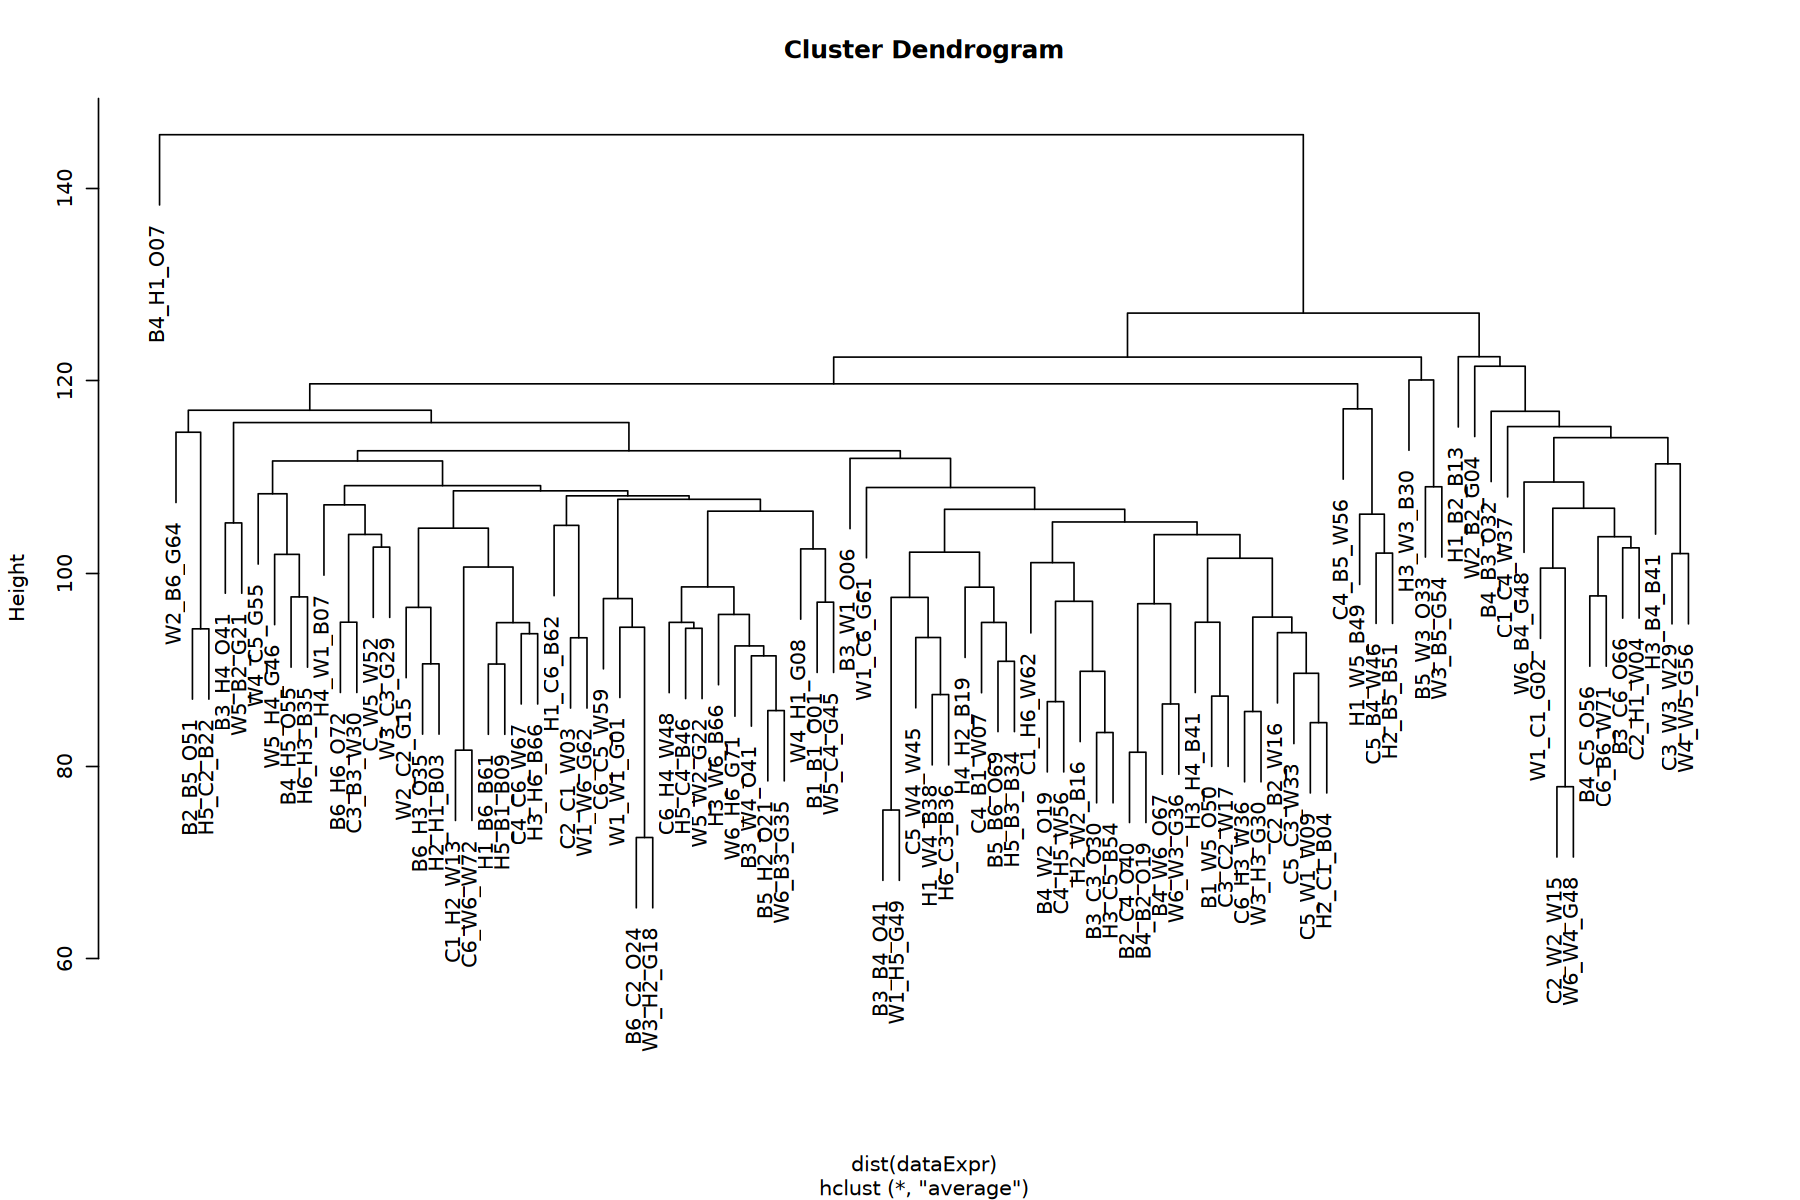

In [20]:
options(repr.plot.width = 15, repr.plot.height = 10)

sampleTree <- hclust(dist(dataExpr), method = "average")
plot(sampleTree)

only obvious outlier - B4_H1_O07 - becuase it clusters above the rest of the tree and is separated from the main cluster - going to remove it from analysis

In [21]:
dataExpr <- dataExpr[!rownames(dataExpr) %in% c("B4_H1_O07"), ]
dim(dataExpr) # 93 samples x 26547 genes

[1]    93 26547

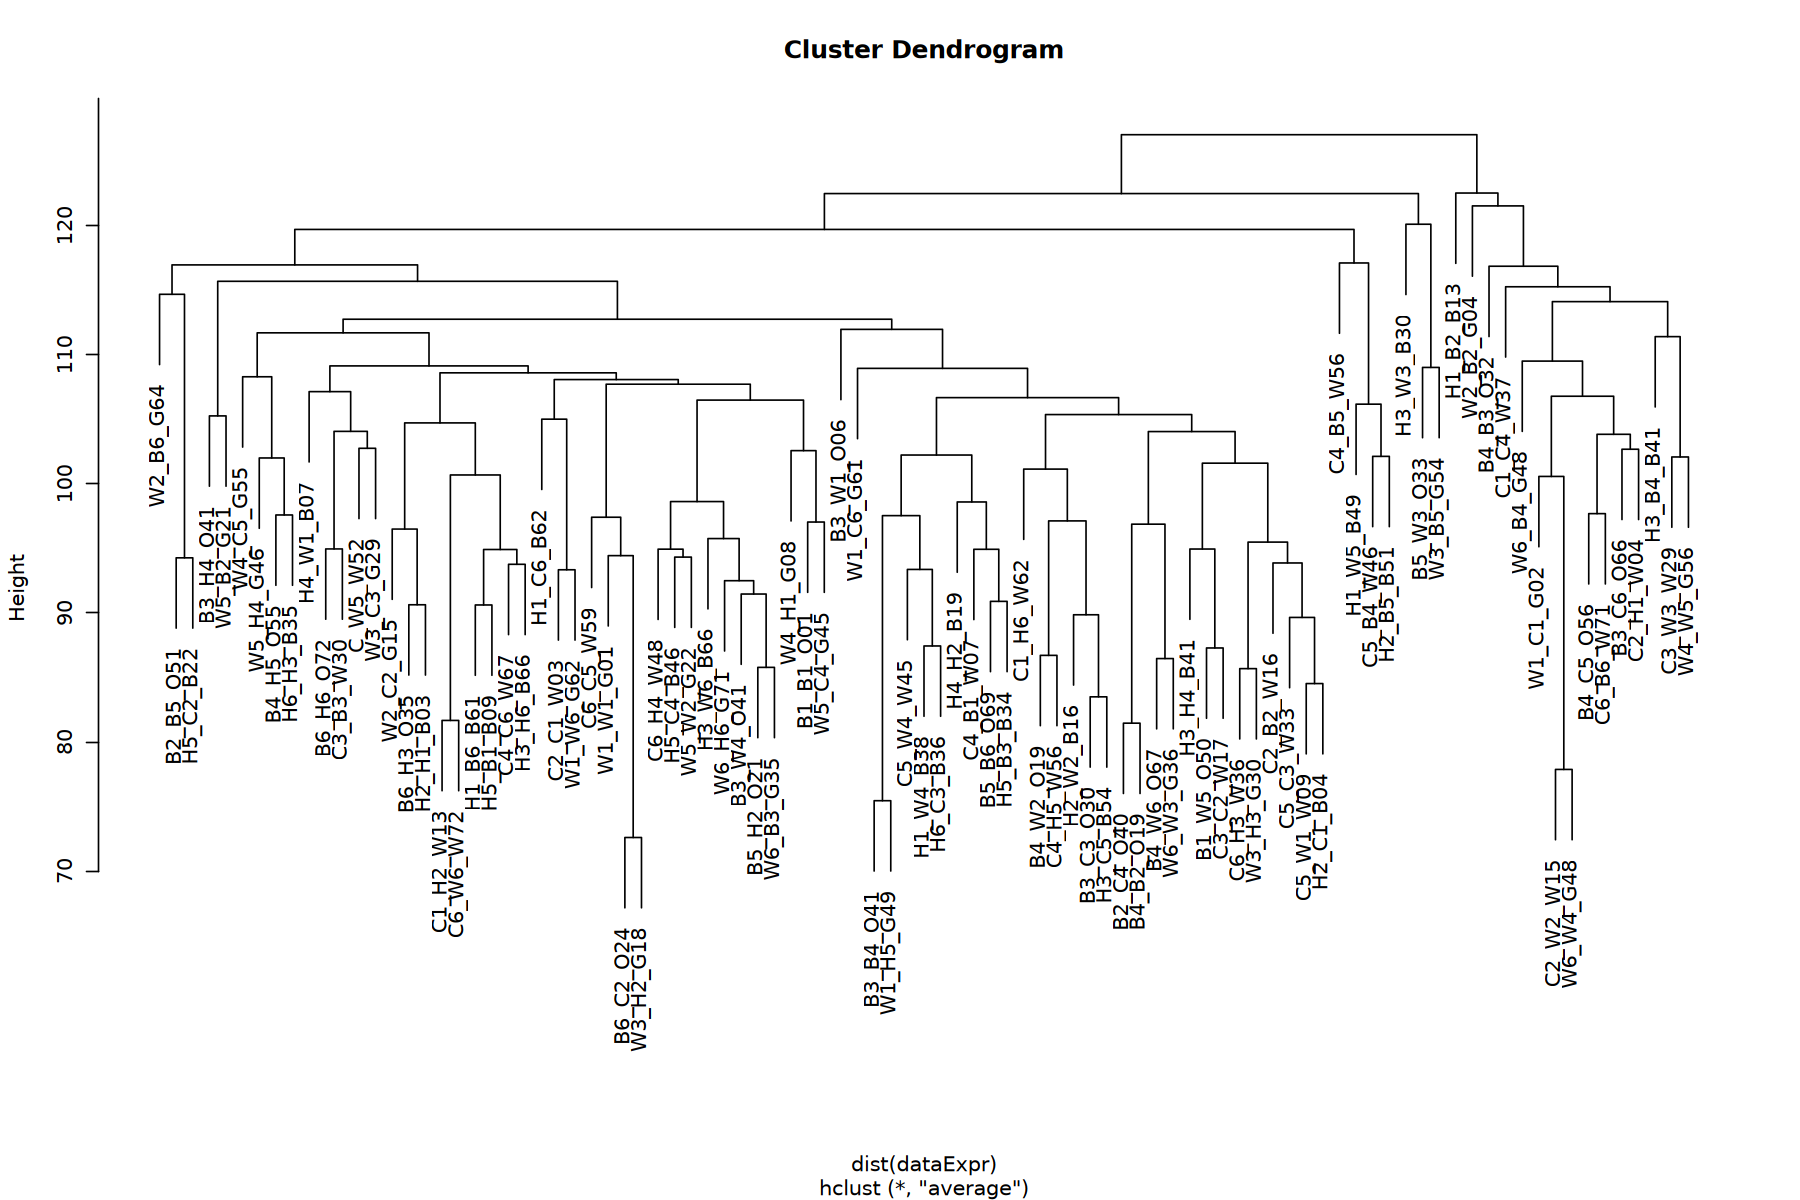

In [22]:
# replot without outliers
sampleTree <- hclust(dist(dataExpr), method = "average")
plot(sampleTree)

looks much better!

### meta data
could add phenotypic data to this ...

In [23]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') %>%
filter(!grepl("Nu", Sample)) # filter out phase 1 samples - only want phase 2

# setting samples as rownames and deleting col from df
rownames(meta) <- meta$Sample
meta <- meta[, !colnames(meta) %in% "Sample"]

# removing same samples as dataExpr
meta <- meta[rownames(meta) %in% rownames(dataExpr), ]

head(meta)
dim(meta) # 92 samples

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4
B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3


[1] 93  8

creating new column for 'complete' treatment - so I can easily compare phase 1 to phase 2

In [24]:
meta$complete_trtmt <- paste(meta$Phase1_treatment, meta$Phase2_treatment)

In [25]:
# double checking the samples in rownames are the same
all(rownames(meta) == rownames(dataExpr))

[1] TRUE

## 2. simple WGCNA network construction and module identification
start with simple, can progress to consensus if deemed necessary

In [26]:
# final QC check
gsg <- goodSamplesGenes(dataExpr, verbose = 3)
if (!gsg$allOK) {
  dataExpr <- dataExpr[gsg$goodSamples, gsg$goodGenes]
}

gsg$allOK

 Flagging genes and samples with too many missing values...
  ..step 1


[1] TRUE

### A. choose soft thresholding power (β)
analysis of network topology

In [ ]:
powers <- c(1:20)
sft <- pickSoftThreshold(
  dataExpr,
  powerVector = powers,
  networkType = "signed",
  verbose = 5
)


pickSoftThreshold: will use block size 1685.
 pickSoftThreshold: calculating connectivity for given powers...
   ..working on genes 1 through 1685 of 26547


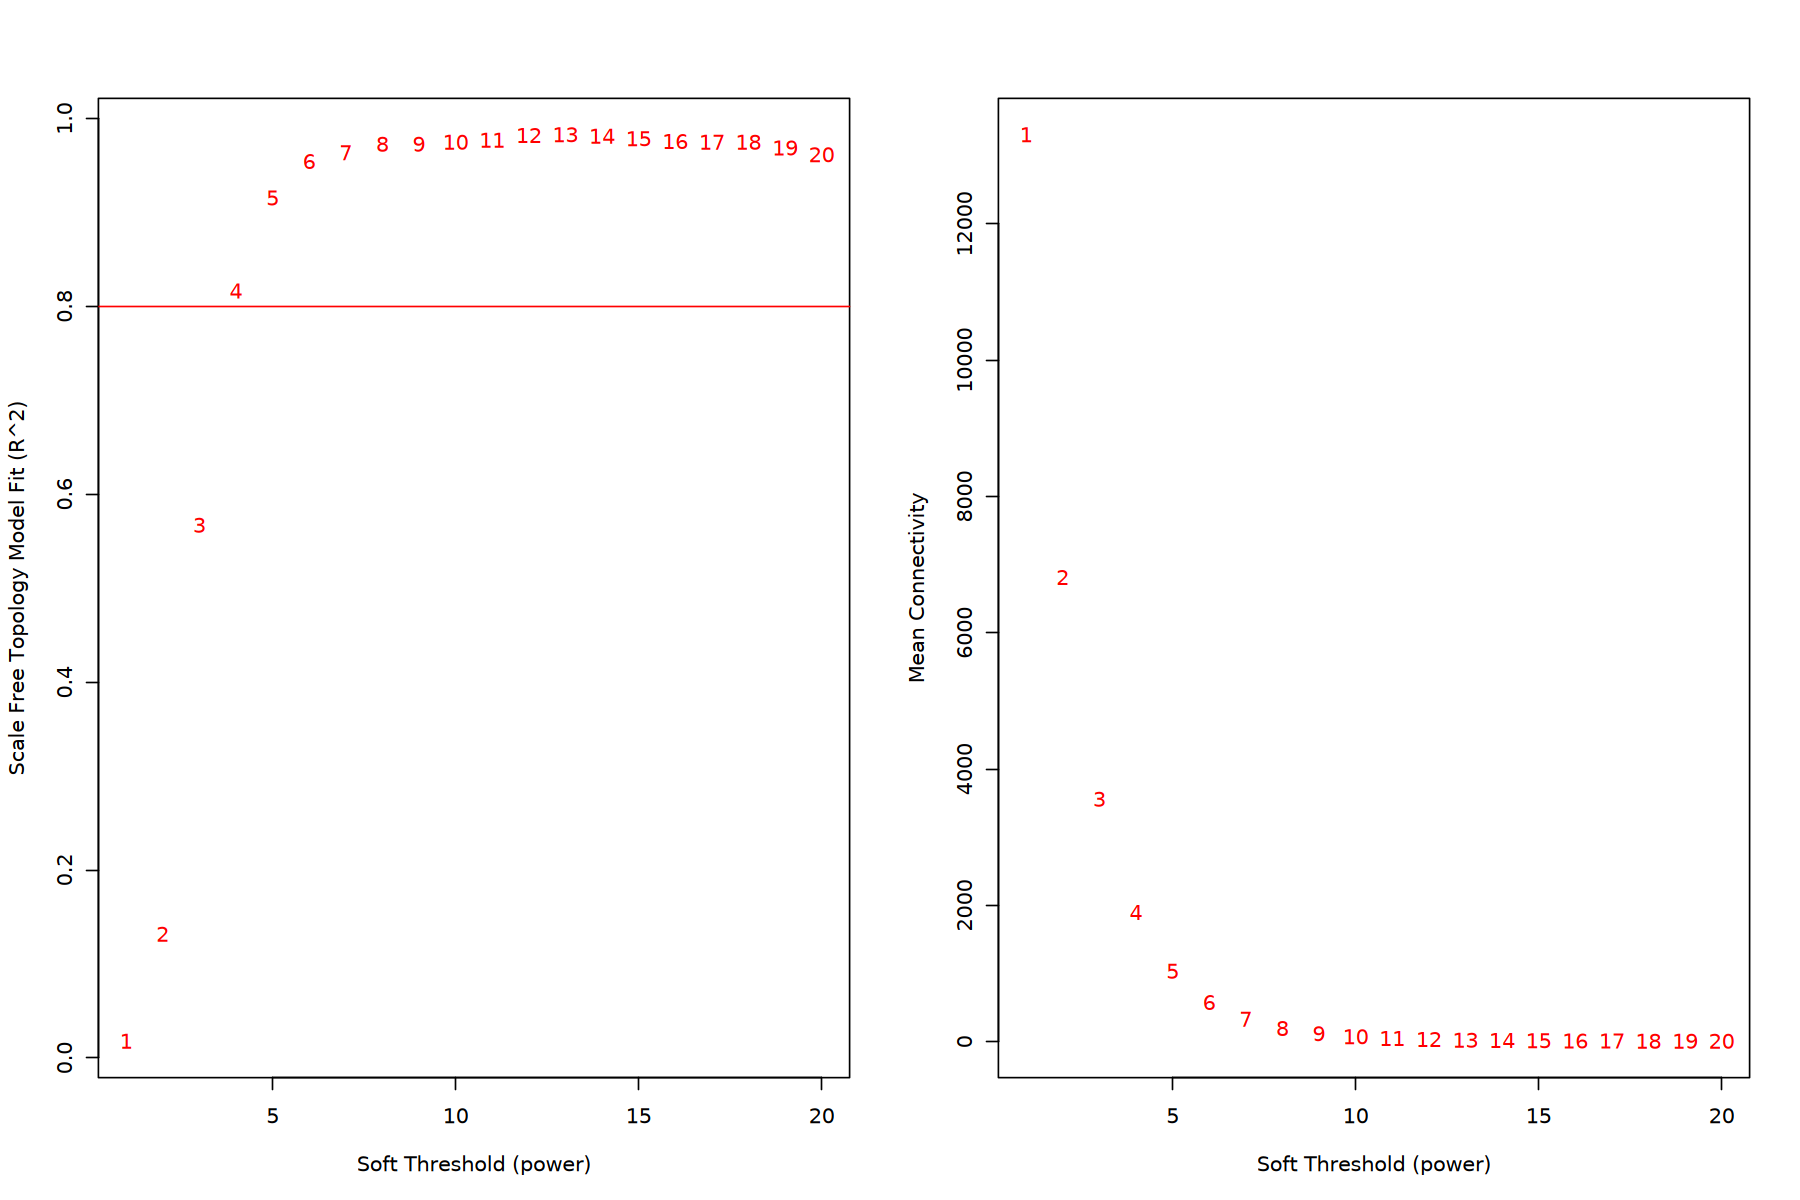

In [28]:
par(mfrow = c(1,2))
plot(
  sft$fitIndices[,1],
  -sign(sft$fitIndices[,3]) * sft$fitIndices[,2],
  xlab = "Soft Threshold (power)",
  ylab = "Scale Free Topology Model Fit (R^2)",
  type = "n"
)
text(
  sft$fitIndices[,1],
  -sign(sft$fitIndices[,3]) * sft$fitIndices[,2],
  labels = powers,
  col = "red"
)
abline(h = 0.8, col = "red")

plot(
  sft$fitIndices[,1],
  sft$fitIndices[,5],
  xlab = "Soft Threshold (power)",
  ylab = "Mean Connectivity",
  type = "n"
)
text(
  sft$fitIndices[,1],
  sft$fitIndices[,5],
  labels = powers,
  col = "red"
)


#### left plot - scale-free topology
the red line is where R^2 is 0.8 - you want the lowest power that reaches this - 4 is just above 0.8 and anything after 6 plateaus

#### right plot - mean connectivity
connectivity should not collapse to 0 - by power 8-10, the connectivity approaches 0

based on this, I think power of 5 should be appropriate

### B. co-expression similarity and adjacency

creating adjacency matrix

In [29]:
softPower <- 5

calculate co-expression adjacency using soft threshold power of 5

can do this signed or unsigned (default) - at this point, I'm not too sure what the difference is

In [30]:
# unsigned
adjacency_unsign <- adjacency(dataExpr, power = softPower, type = 'unsigned') 
head(adjacency_unsign)

# signed
adjacency_sign <- adjacency(dataExpr, power = softPower, type = 'signed') 
head(adjacency_sign)

,LOC111126949,LOC111120752,LOC111105691,LOC111113860,LOC111109550,LOC111109753,LOC111109452,LOC111124802,LOC111101273,LOC111101250,⋯,CYTB,COX2,ATP6,ND2,ND4,ND5,ND6,ND3,ND1,ND4L
LOC111126949,1.000000e+00,1.782543e-03,2.752219e-08,4.600205e-07,9.155717e-05,1.656267e-05,8.391595e-13,2.581975e-03,1.319233e-02,4.230721e-05,⋯,7.160573e-07,1.558930e-05,5.919973e-06,1.493077e-04,2.374682e-09,5.391527e-09,5.879192e-05,1.105667e-08,2.965007e-06,6.959330e-07
LOC111120752,1.782543e-03,1.000000e+00,1.716104e-06,3.146263e-08,7.358584e-05,1.762023e-09,1.690230e-05,1.070843e-05,3.894397e-02,1.183032e-05,⋯,8.026964e-03,6.595698e-03,1.598050e-02,4.779981e-03,3.795156e-02,4.617818e-03,2.676368e-02,1.774048e-02,1.566690e-02,1.381881e-02
LOC111105691,2.752219e-08,1.716104e-06,1.000000e+00,1.084102e-06,1.915999e-05,2.407908e-07,6.601852e-07,6.362332e-11,5.738142e-08,2.303477e-04,⋯,2.204940e-04,1.582523e-08,5.902503e-10,4.193395e-08,1.465177e-06,4.447607e-05,2.631513e-11,1.409498e-07,1.039271e-05,2.704959e-09
LOC111113860,4.600205e-07,3.146263e-08,1.084102e-06,1.000000e+00,2.333026e-05,8.882854e-06,3.091483e-04,1.303715e-07,1.645528e-07,5.683632e-07,⋯,6.034621e-06,4.048877e-04,1.244493e-03,1.803356e-04,7.549985e-06,2.280600e-06,6.601983e-04,4.168502e-05,2.332036e-04,4.252386e-04
LOC111109550,9.155717e-05,7.358584e-05,1.915999e-05,2.333026e-05,1.000000e+00,4.656518e-06,4.186890e-08,2.371397e-05,2.300438e-07,1.194374e-06,⋯,6.849831e-15,2.213905e-04,7.697647e-08,7.936029e-06,4.187663e-07,8.517485e-10,7.454661e-10,5.411355e-08,1.497762e-07,1.762907e-14
LOC111109753,1.656267e-05,1.762023e-09,2.407908e-07,8.882854e-06,4.656518e-06,1.000000e+00,2.298499e-08,2.020960e-04,8.740811e-04,2.179421e-08,⋯,3.920238e-05,1.177167e-06,4.570454e-16,3.930212e-07,8.284044e-07,1.910615e-04,1.535774e-07,4.270411e-05,1.626405e-04,1.795192e-05


,LOC111126949,LOC111120752,LOC111105691,LOC111113860,LOC111109550,LOC111109753,LOC111109452,LOC111124802,LOC111101273,LOC111101250,⋯,CYTB,COX2,ATP6,ND2,ND4,ND5,ND6,ND3,ND1,ND4L
LOC111126949,1.00000000,0.00596421,0.02673096,0.02367334,0.06443312,0.05280483,0.03185524,0.11767250,0.002037204,0.01527023,⋯,0.04162633,0.017520275,0.019496087,0.01218261,0.02841485,0.03487613,0.014487059,0.02744560,0.04558078,0.041560431
LOC111120752,0.00596421,1.00000000,0.02170610,0.03650792,0.06259823,0.02857326,0.05291190,0.05064454,0.255646300,0.01810499,⋯,0.15696330,0.148799263,0.191643328,0.13676826,0.25339540,0.13556982,0.225477159,0.19787840,0.19049290,0.183436092
LOC111105691,0.02673096,0.02170610,1.00000000,0.04263922,0.05358685,0.03940373,0.02317122,0.02984845,0.037227386,0.01108081,⋯,0.01119240,0.035795722,0.029084096,0.03683972,0.02196268,0.01515245,0.032464819,0.03850535,0.01837367,0.028342929
LOC111113860,0.02367334,0.03650792,0.04263922,1.00000000,0.05469640,0.01869409,0.01032832,0.02521879,0.038753608,0.02338274,⋯,0.01945904,0.009637944,0.006821705,0.01170431,0.01901998,0.02123009,0.008394532,0.01530505,0.01104935,0.009512618
LOC111109550,0.06443312,0.06259823,0.05358685,0.05469640,1.00000000,0.04716812,0.03683787,0.05479113,0.024561187,0.02228596,⋯,0.03102108,0.011182048,0.037616489,0.01892067,0.04045961,0.03372294,0.028983659,0.03715280,0.03860167,0.030973609
LOC111109753,0.05280483,0.02857326,0.03940373,0.01869409,0.04716812,1.00000000,0.02688139,0.07223356,0.007690798,0.02692491,⋯,0.05793885,0.042853010,0.031116627,0.04033135,0.04197053,0.07161344,0.038641818,0.05852193,0.06989560,0.053233270


In [31]:
# write.csv(data.frame(gene = rownames(adjacency_sign)), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/p2.wgcna_UniversalGeneList.csv', row.names = FALSE)

### C. Topological Overlap Matrix (TOM)
transform adjacency into TOM to minimize effects of noise and spurious associations - calculate corresponding dissimilarity

In [32]:
## UNSIGNED
# turn adjacency into topological overlap
TOM_unsign <- TOMsimilarity(adjacency_unsign)
head(TOM_unsign)

# calculate dissimilarity
dissTOM_unsign <- 1-TOM_unsign
head(dissTOM_unsign)


## SIGNED
# turn adjacency into topological overlap
TOM_sign <- TOMsimilarity(adjacency_sign)
head(TOM_sign)

# calculate dissimilarity
dissTOM_sign <- 1-TOM_sign
head(dissTOM_sign)

..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.


1.0000000000,0.0042933083,1.852709e-04,5.818304e-04,0.0005404566,0.0003144408,0.0005682741,0.0020470717,0.0071768146,0.0037048014,⋯,0.0004408250,0.0005759230,0.0005677051,0.0004982259,0.0008827370,0.0003837645,0.0007463244,0.0005814072,0.0006610943,0.0004647112
0.0042933083,1.0000000000,2.773913e-04,1.873669e-03,0.0004478330,0.0001914498,0.0012254369,0.0010705347,0.0226939637,0.0030848120,⋯,0.0164825038,0.0195005626,0.0236828804,0.0198913808,0.0231048502,0.0120065692,0.0230095491,0.0235759301,0.0164464391,0.0184666636
0.0001852709,0.0002773913,1.000000e+00,5.565506e-05,0.0001184485,0.0002327076,0.0001395993,0.0001562924,0.0001999636,0.0007183777,⋯,0.0003600078,0.0001663546,0.0001553802,0.0001165873,0.0002603584,0.0002545397,0.0002055112,0.0002058637,0.0003232873,0.0001910332
0.0005818304,0.0018736690,5.565506e-05,1.000000e+00,0.0001005873,0.0001449656,0.0014757616,0.0003609820,0.0011261494,0.0016916643,⋯,0.0005621569,0.0006108221,0.0007841932,0.0004435304,0.0007163779,0.0004381356,0.0010218126,0.0006395913,0.0008489379,0.0006412816
0.0005404566,0.0004478330,1.184485e-04,1.005873e-04,1.0000000000,0.0003099846,0.0001955092,0.0004039726,0.0003043675,0.0003599073,⋯,0.0002965254,0.0003927036,0.0002604835,0.0001557174,0.0003543204,0.0002128943,0.0003100519,0.0003067601,0.0003578739,0.0002432699
0.0003144408,0.0001914498,2.327076e-04,1.449656e-04,0.0003099846,1.0000000000,0.0001828311,0.0004006687,0.0004618206,0.0001673186,⋯,0.0008082062,0.0004760549,0.0001727626,0.0003480783,0.0003218440,0.0011239916,0.0002740738,0.0007224079,0.0027691623,0.0018399482


0.0000000,0.9957067,0.9998147,0.9994182,0.9994595,0.9996856,0.9994317,0.9979529,0.9928232,0.9962952,⋯,0.9995592,0.9994241,0.9994323,0.9995018,0.9991173,0.9996162,0.9992537,0.9994186,0.9993389,0.9995353
0.9957067,0.0000000,0.9997226,0.9981263,0.9995522,0.9998086,0.9987746,0.9989295,0.9773060,0.9969152,⋯,0.9835175,0.9804994,0.9763171,0.9801086,0.9768951,0.9879934,0.9769905,0.9764241,0.9835536,0.9815333
0.9998147,0.9997226,0.0000000,0.9999443,0.9998816,0.9997673,0.9998604,0.9998437,0.9998000,0.9992816,⋯,0.9996400,0.9998336,0.9998446,0.9998834,0.9997396,0.9997455,0.9997945,0.9997941,0.9996767,0.9998090
0.9994182,0.9981263,0.9999443,0.0000000,0.9998994,0.9998550,0.9985242,0.9996390,0.9988739,0.9983083,⋯,0.9994378,0.9993892,0.9992158,0.9995565,0.9992836,0.9995619,0.9989782,0.9993604,0.9991511,0.9993587
0.9994595,0.9995522,0.9998816,0.9998994,0.0000000,0.9996900,0.9998045,0.9995960,0.9996956,0.9996401,⋯,0.9997035,0.9996073,0.9997395,0.9998443,0.9996457,0.9997871,0.9996899,0.9996932,0.9996421,0.9997567
0.9996856,0.9998086,0.9997673,0.9998550,0.9996900,0.0000000,0.9998172,0.9995993,0.9995382,0.9998327,⋯,0.9991918,0.9995239,0.9998272,0.9996519,0.9996782,0.9988760,0.9997259,0.9992776,0.9972308,0.9981601


..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.


1.00000000,0.03203669,0.04325609,0.03859603,0.04767874,0.04841777,0.04451317,0.05394023,0.02788190,0.03691653,⋯,0.04095883,0.03843461,0.03899431,0.03807728,0.04075141,0.04319353,0.03923952,0.04058928,0.04422606,0.04232475
0.03203669,1.00000000,0.04151904,0.04947939,0.04474896,0.04240832,0.04069907,0.04546719,0.07603718,0.03576878,⋯,0.06625035,0.06621622,0.06956860,0.06530790,0.07331335,0.06192108,0.06849582,0.06912506,0.07022219,0.06638767
0.04325609,0.04151904,1.00000000,0.03602860,0.03812489,0.04259115,0.03941299,0.04030782,0.03924153,0.03933737,⋯,0.04050891,0.04099153,0.04117581,0.04055060,0.04217482,0.03939417,0.04255275,0.04350582,0.04239243,0.04209052
0.03859603,0.04947939,0.03602860,1.00000000,0.03793008,0.04057033,0.03429513,0.03711149,0.04525296,0.04092677,⋯,0.04474596,0.04012829,0.03969172,0.04049417,0.04444097,0.04076944,0.03947218,0.04203759,0.04310102,0.04108138
0.04767874,0.04474896,0.03812489,0.03793008,1.00000000,0.04515372,0.03986899,0.04416545,0.03677512,0.04383935,⋯,0.04130757,0.03881138,0.04178284,0.03773336,0.04446496,0.04154167,0.04249430,0.04248601,0.04382650,0.04165347
0.04841777,0.04240832,0.04259115,0.04057033,0.04515372,1.00000000,0.04496422,0.05007689,0.03452615,0.04054339,⋯,0.05118587,0.04825489,0.04445493,0.04639658,0.04698003,0.05398672,0.04633184,0.05064223,0.05719088,0.05367676


0.0000000,0.9679633,0.9567439,0.9614040,0.9523213,0.9515822,0.9554868,0.9460598,0.9721181,0.9630835,⋯,0.9590412,0.9615654,0.9610057,0.9619227,0.9592486,0.9568065,0.9607605,0.9594107,0.9557739,0.9576752
0.9679633,0.0000000,0.9584810,0.9505206,0.9552510,0.9575917,0.9593009,0.9545328,0.9239628,0.9642312,⋯,0.9337496,0.9337838,0.9304314,0.9346921,0.9266867,0.9380789,0.9315042,0.9308749,0.9297778,0.9336123
0.9567439,0.9584810,0.0000000,0.9639714,0.9618751,0.9574089,0.9605870,0.9596922,0.9607585,0.9606626,⋯,0.9594911,0.9590085,0.9588242,0.9594494,0.9578252,0.9606058,0.9574472,0.9564942,0.9576076,0.9579095
0.9614040,0.9505206,0.9639714,0.0000000,0.9620699,0.9594297,0.9657049,0.9628885,0.9547470,0.9590732,⋯,0.9552540,0.9598717,0.9603083,0.9595058,0.9555590,0.9592306,0.9605278,0.9579624,0.9568990,0.9589186
0.9523213,0.9552510,0.9618751,0.9620699,0.0000000,0.9548463,0.9601310,0.9558345,0.9632249,0.9561606,⋯,0.9586924,0.9611886,0.9582172,0.9622666,0.9555350,0.9584583,0.9575057,0.9575140,0.9561735,0.9583465
0.9515822,0.9575917,0.9574089,0.9594297,0.9548463,0.0000000,0.9550358,0.9499231,0.9654738,0.9594566,⋯,0.9488141,0.9517451,0.9555451,0.9536034,0.9530200,0.9460133,0.9536682,0.9493578,0.9428091,0.9463232


### D. Call the hierarchical clustering function - plot the tree
hierarchical clustering tree (dendrogram) of genes

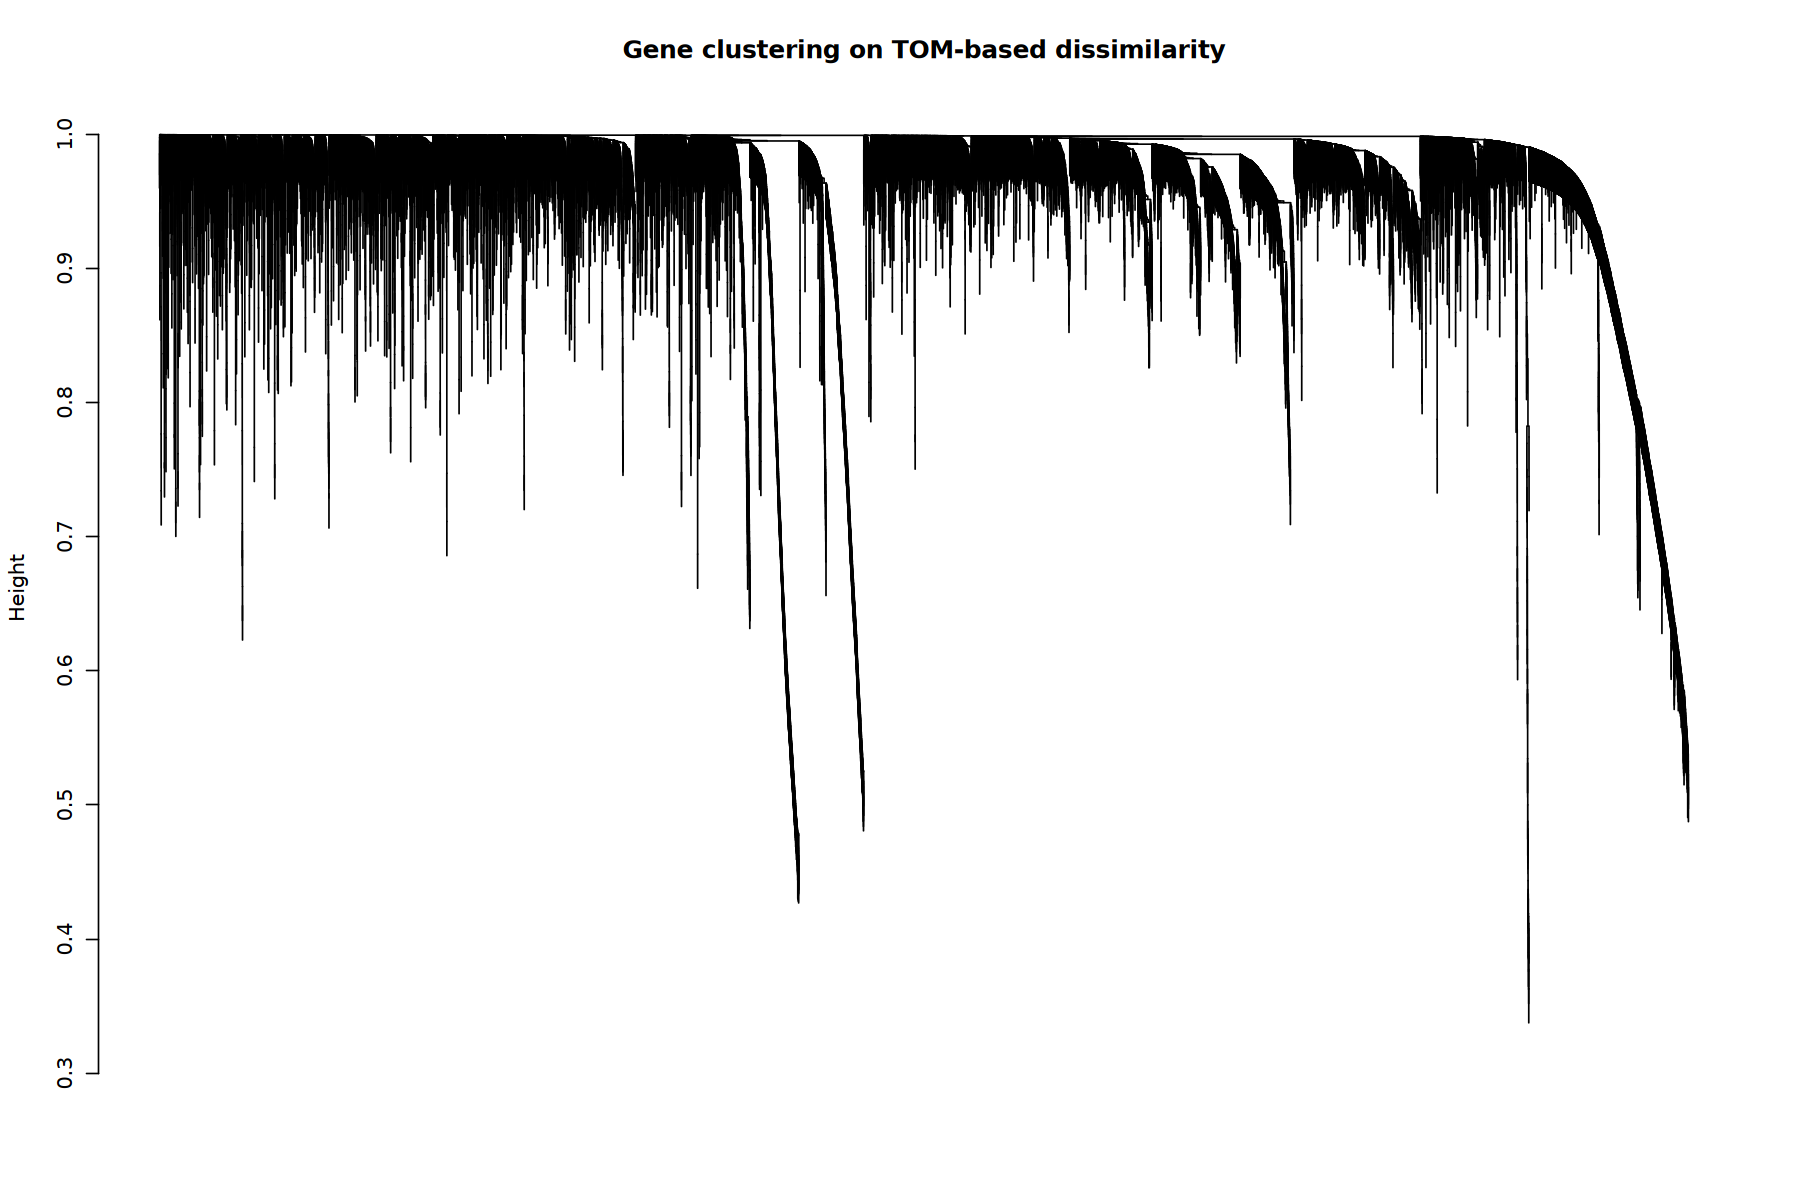

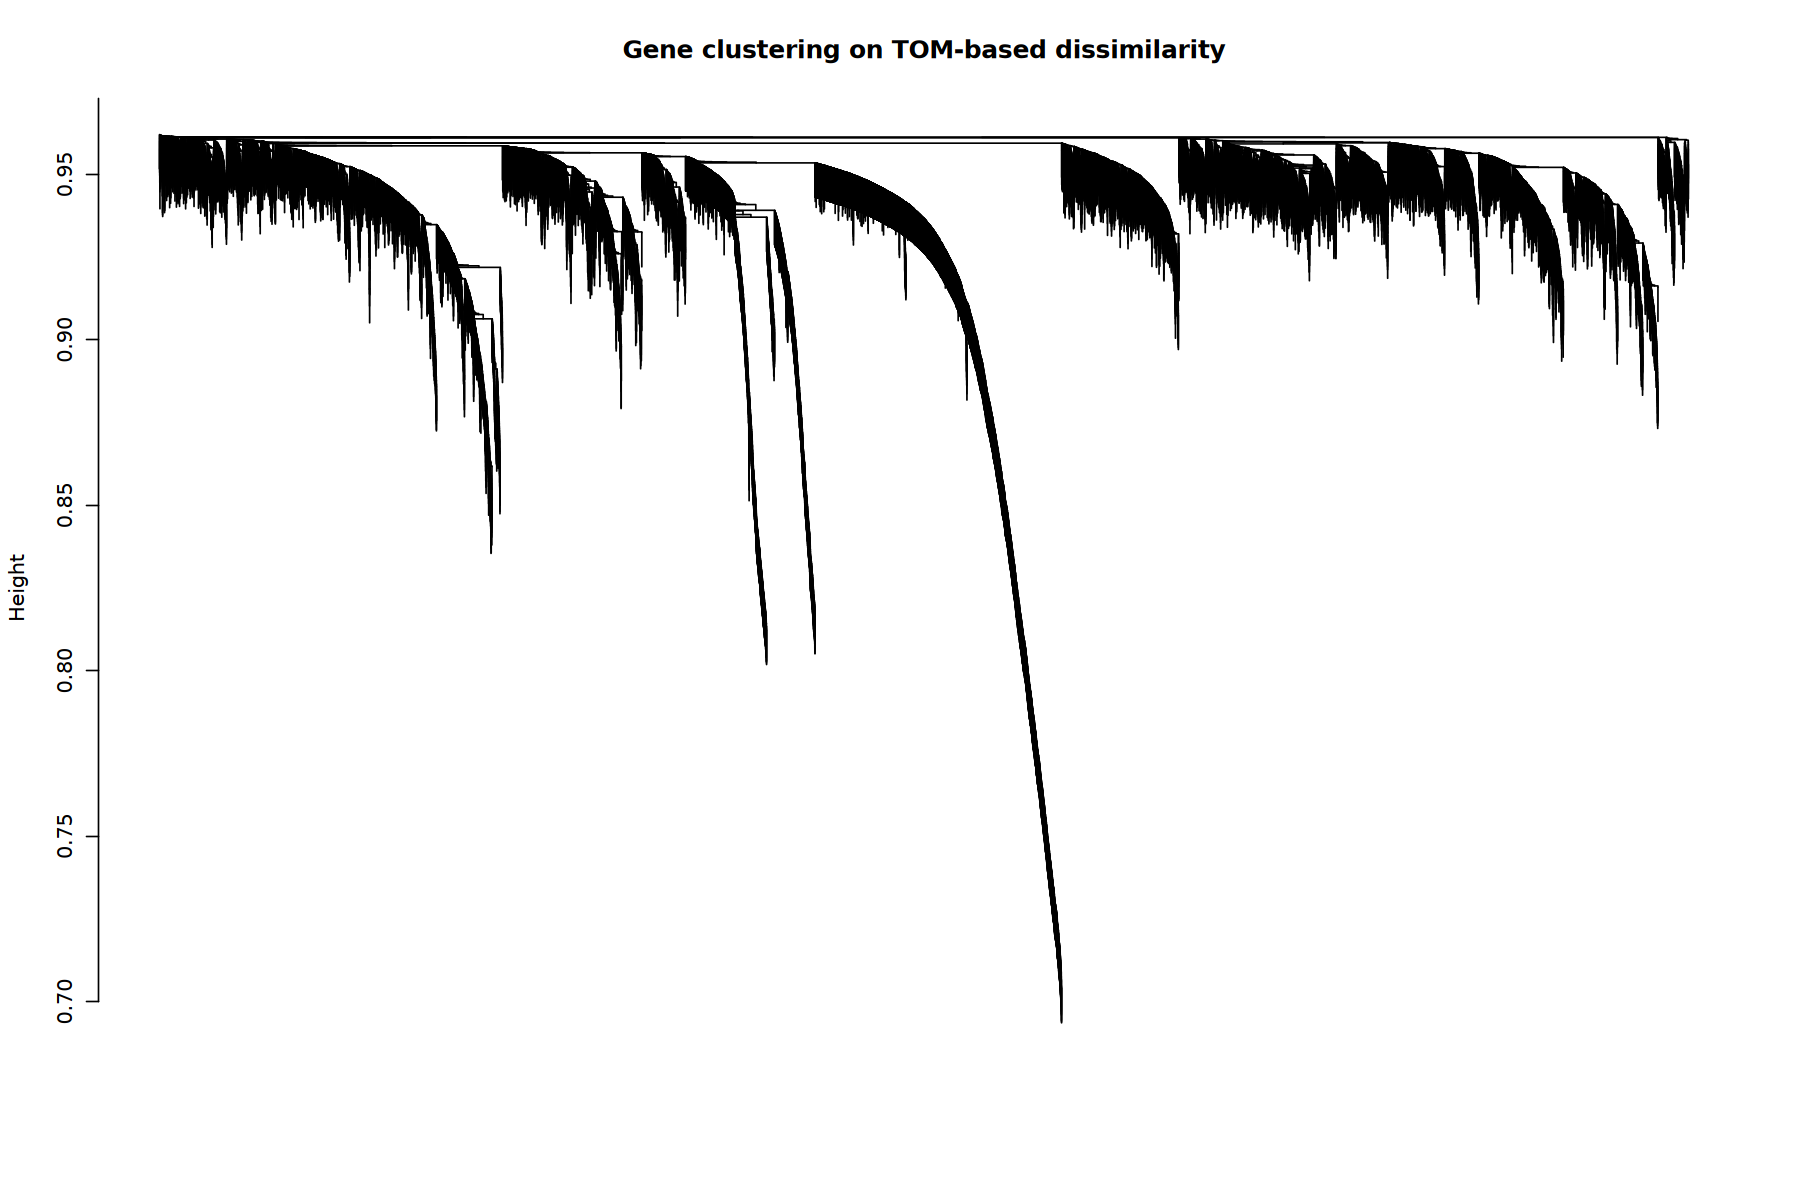

In [33]:
# call hierarchical clustering function
geneTree_unsign = hclust(as.dist(dissTOM_unsign), method = "average")
geneTree_sign = hclust(as.dist(dissTOM_sign), method = "average")

# plot the dendrogram
plot(geneTree_unsign, xlab="", sub="", main = "Gene clustering on TOM-based dissimilarity",labels = FALSE, hang = 0.04)
plot(geneTree_sign, xlab="", sub="", main = "Gene clustering on TOM-based dissimilarity",labels = FALSE, hang = 0.04)

looks like the signed adjacency matrix resulted in more distinct leafs than the unsigned matrix ...

from here on out, I'm going to use the ***signed*** correlation matrix

each leaf (short vertical line) corresponds to a gene - branches group together densely interconnected, highly co-expressed genes

module identification = cutting branches off the dendrogram

### E. module identification

set minimum module size - this is the smallest number of genes allowed to be put into a module 

then use Dynamic Tree Cut which is the default method for branch cutting and module detection

In [34]:
# would like large modules, so we set the minimum module size relatively high:
minModuleSize <- 100

## SIGNED
# Module identification using dynamic tree cut:
dynamicMods_sign <- cutreeDynamic(dendro = geneTree_sign, distM = dissTOM_sign, 
                             deepSplit = 2, pamRespectsDendro = FALSE,
                             minClusterSize = minModuleSize)
table(dynamicMods_sign) # number of genes per module

 ..cutHeight not given, setting it to 0.961  ===>  99% of the (truncated) height range in dendro.
 ..done.


dynamicMods_sign
   1    2    3    4    5    6    7    8    9   10   11   12   13   14   15 
4323 3879 3321 3210 2037 1975 1677 1629 1100  902  777  544  542  349  282 

15 modules generated

convert numeric network to colors and plots dendrogram:

dynamicColors_sign
       black         blue        brown         cyan        green  greenyellow 
        1677         3879         3321          349         2037          777 
     magenta midnightblue         pink       purple          red       salmon 
        1100          282         1629          902         1975          542 
         tan    turquoise       yellow 
         544         4323         3210 

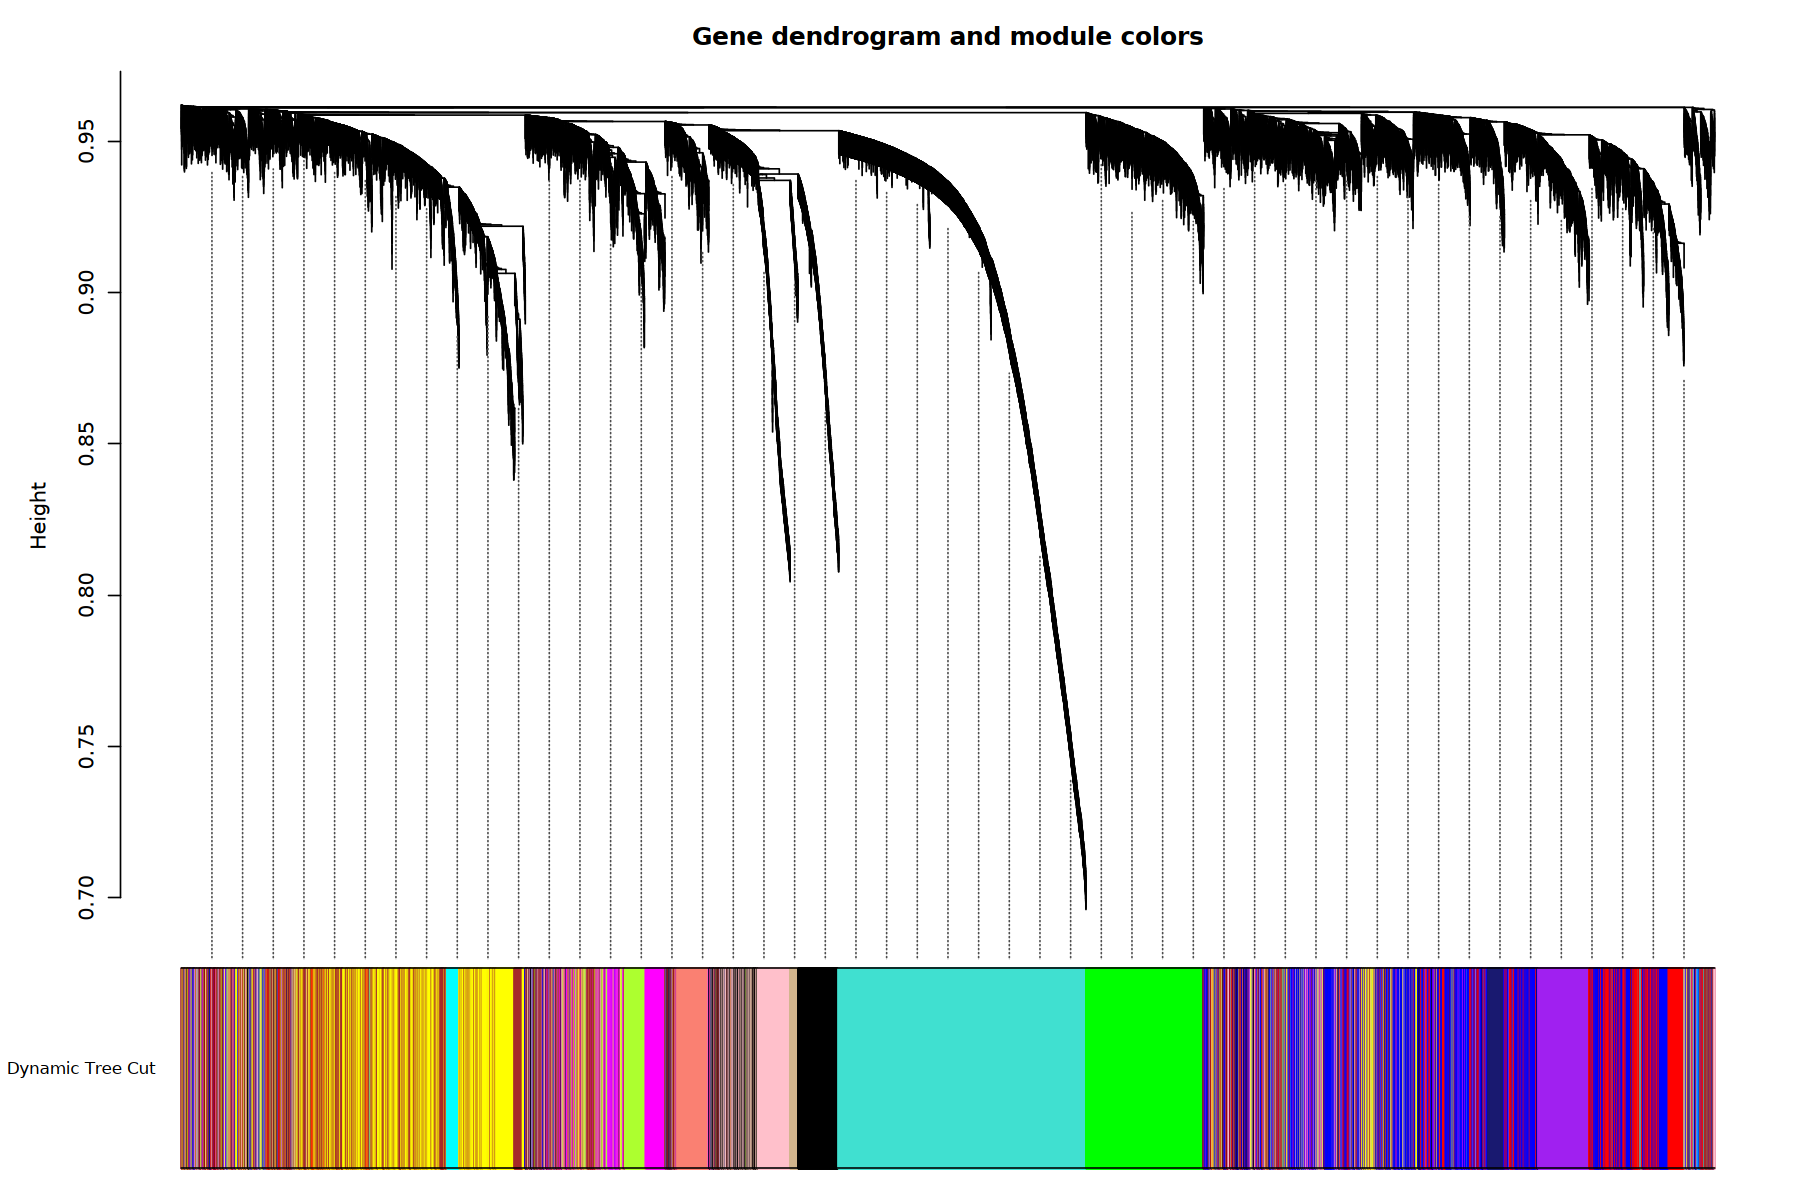

In [35]:
## SIGNED
# Convert numeric lables into colors
dynamicColors_sign <- labels2colors(dynamicMods_sign)
table(dynamicColors_sign)

# Plot the dendrogram and colors underneath
plotDendroAndColors(geneTree_sign, dynamicColors_sign, "Dynamic Tree Cut",
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05,
                    main = "Gene dendrogram and module colors")


### F. merging modules whose GE profiles are similar

this is based on eigengenes, which is the first principal component of a given a gene expression matrix/module that acts as a representative summary profile for a gene module or cluster

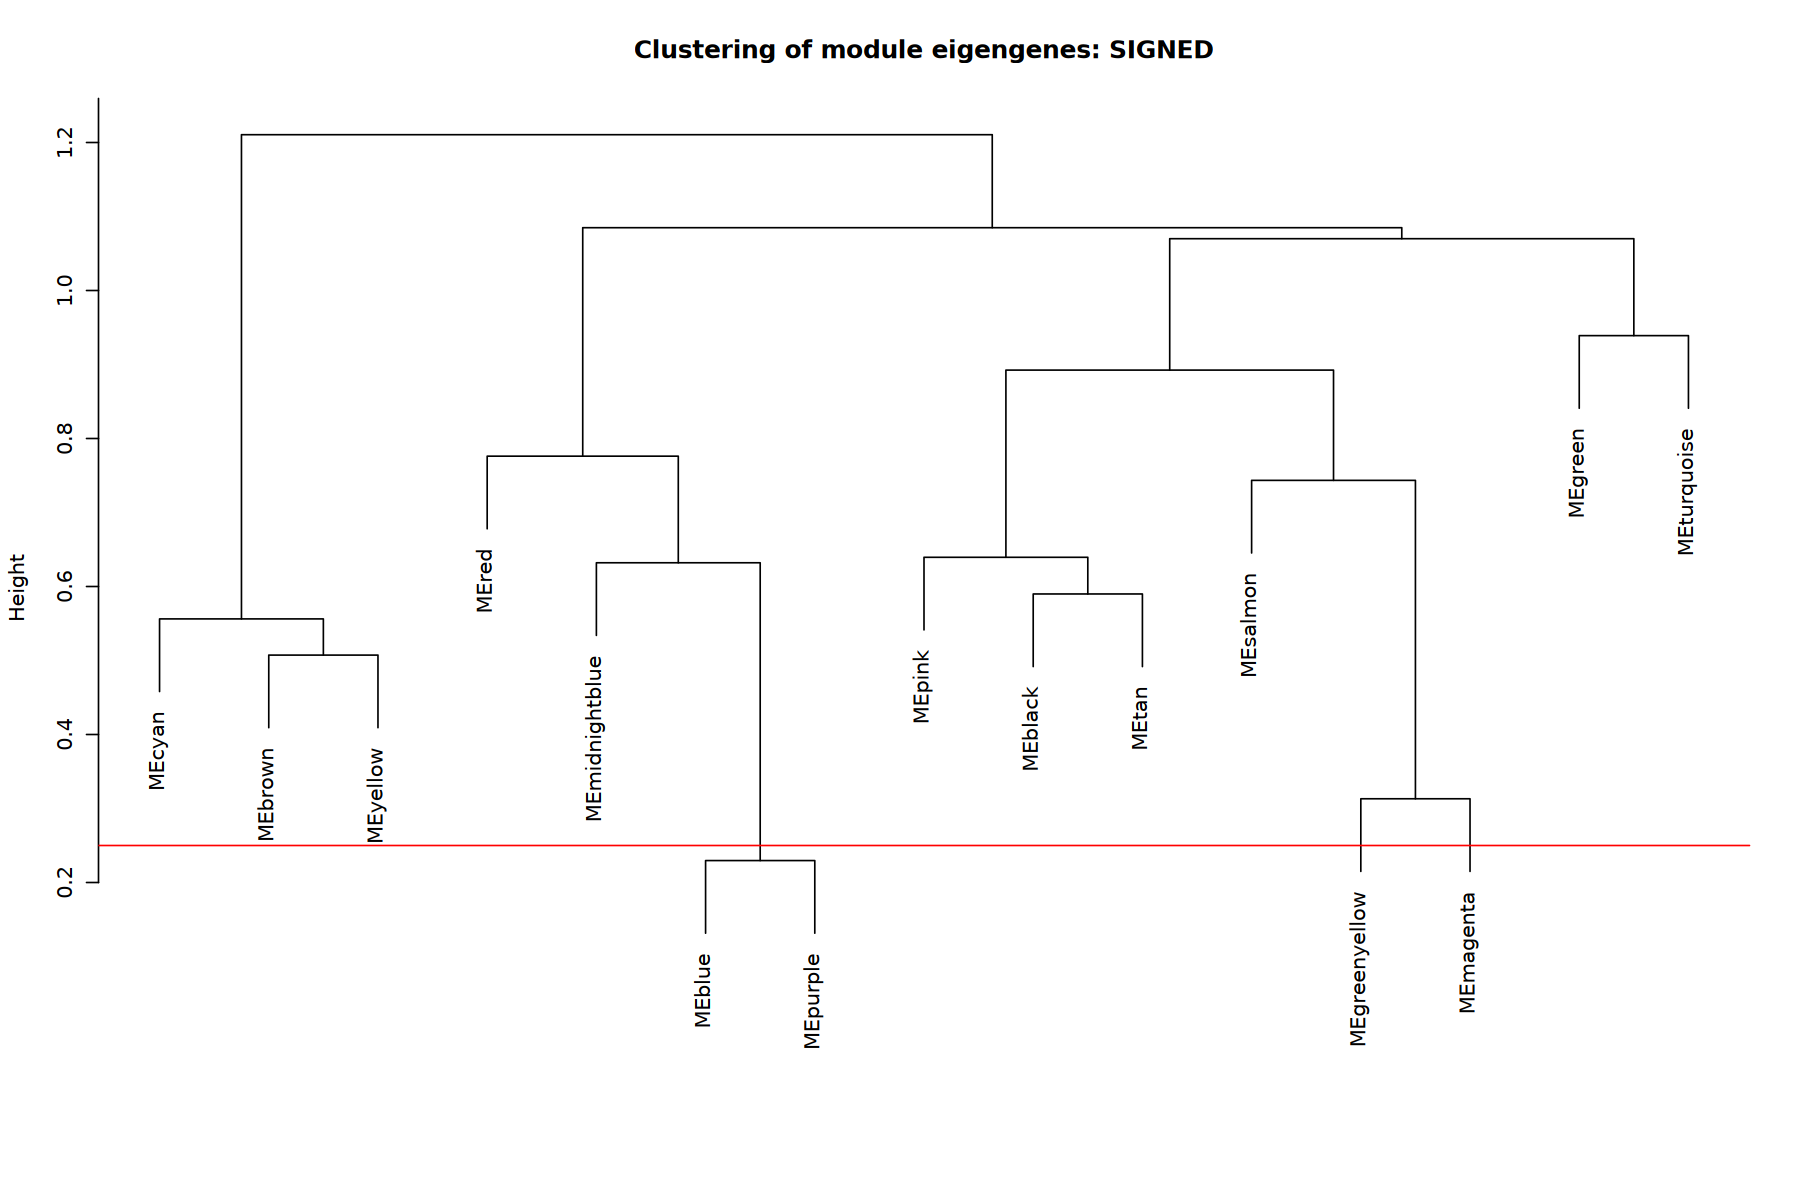

In [36]:
## SIGNED
# Calculate eigengenes
MEList_sign <- moduleEigengenes(dataExpr, colors = dynamicColors_sign)
MEs_sign <- MEList_sign$eigengenes

# Calculate dissimilarity of module eigengenes
MEDiss_sign <- 1-cor(MEs_sign)

# Cluster module eigengenes
METree_sign <- hclust(as.dist(MEDiss_sign), method = "average")

# Plot the result

# height cutoff of 0.25 - corresponds to a correlation of 0.75 to merge
MEDissThres <- 0.25

# Plot the cut line into the dendrogram
plot(METree_sign, main = "Clustering of module eigengenes: SIGNED", xlab = "", sub = "")
abline(h=MEDissThres, col = "red")

any branch with more than 75% correlation are related and will be merged - so blue and purple modules will be merged

 mergeCloseModules: Merging modules whose distance is less than 0.25
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 15 module eigengenes in given set.
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 14 module eigengenes in given set.
   Calculating new MEs...
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 14 module eigengenes in given set.


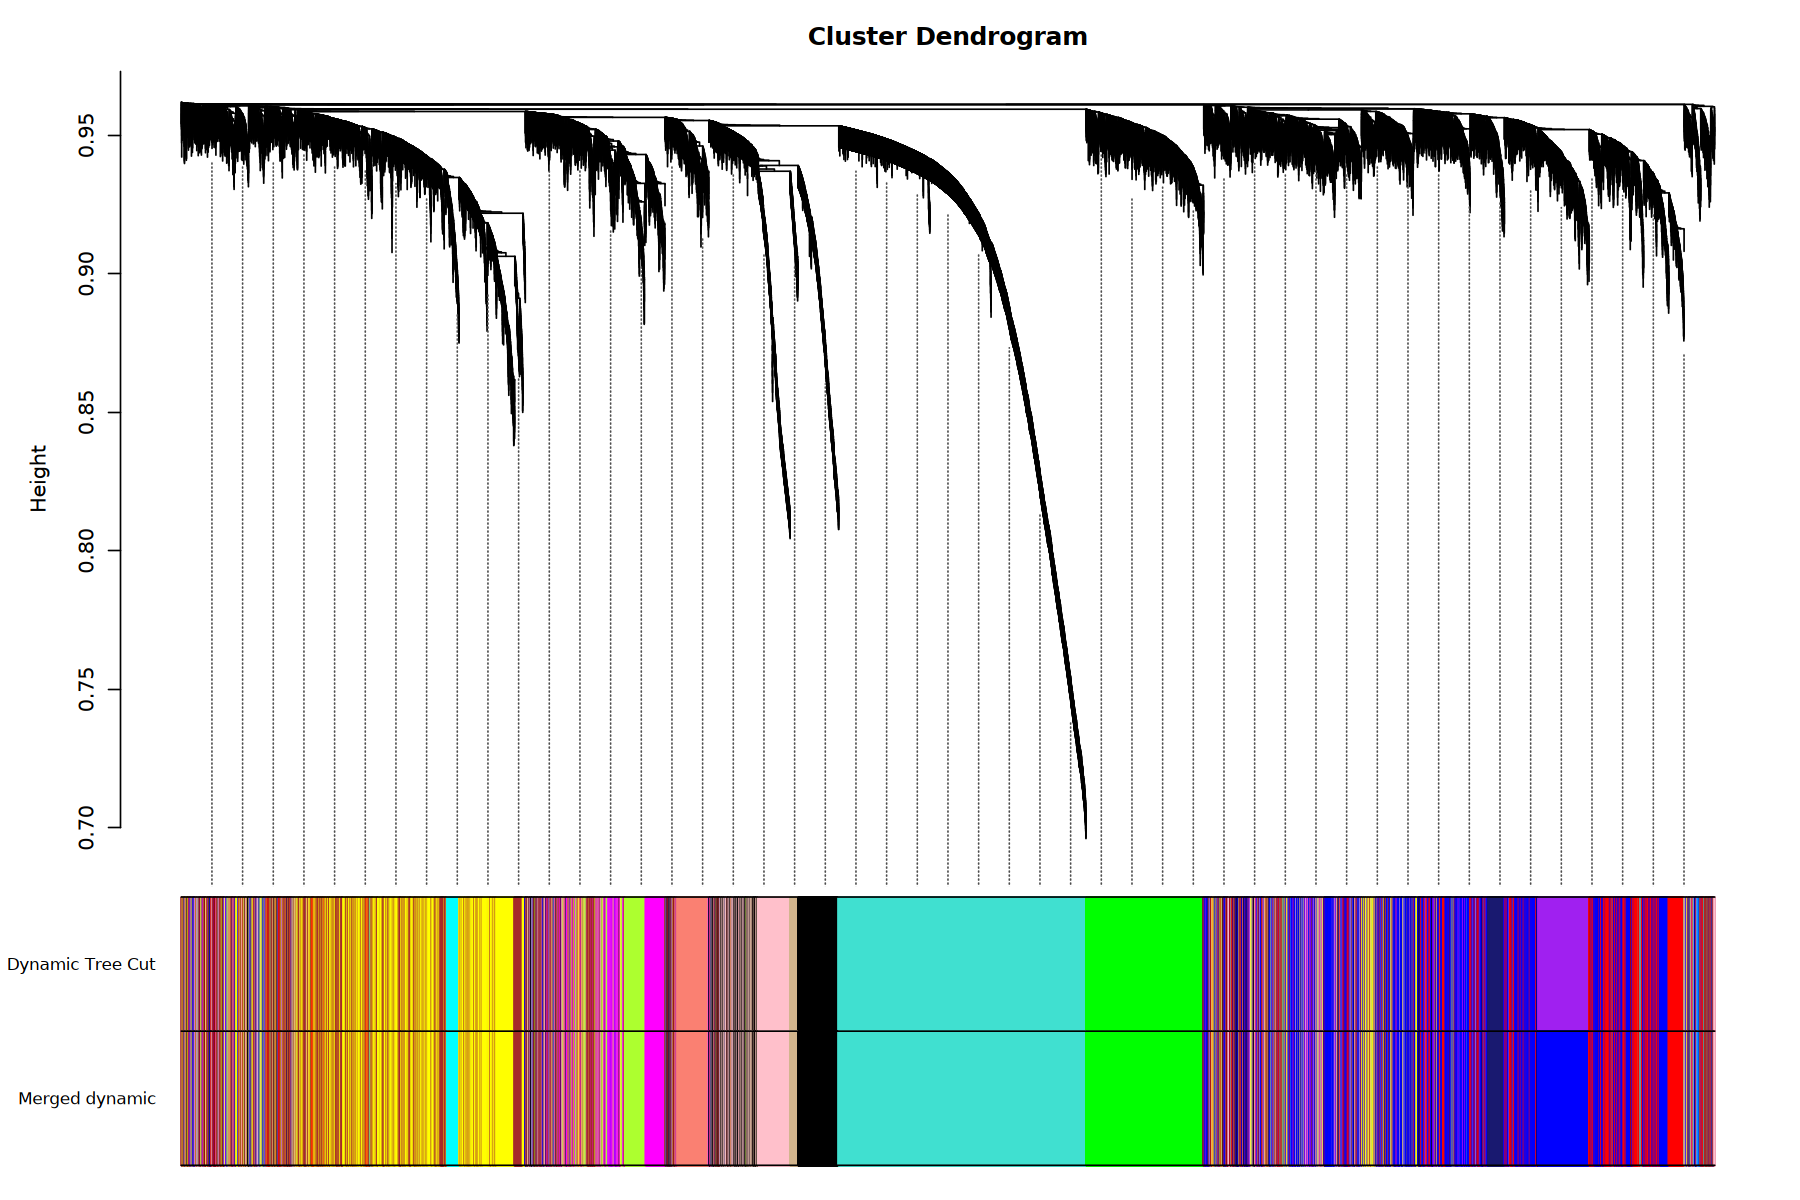

In [37]:
options(repr.plot.width = 15, repr.plot.height = 10)

## SIGNED
# Call an automatic merging function
merge_sign <- mergeCloseModules(dataExpr, dynamicColors_sign, cutHeight = MEDissThres, verbose = 3)

# The merged module colors
mergedColors_sign <- merge_sign$colors

# Eigengenes of the new merged modules:
mergedMEs_sign <- merge_sign$newMEs

# plot merged module colors
plotDendroAndColors(geneTree_sign, cbind(dynamicColors_sign, mergedColors_sign), 
                    c("Dynamic Tree Cut", "Merged dynamic"),
                    dendroLabels = FALSE, hang = 0.03,
                    addGuide = TRUE, guideHang = 0.05)


In [38]:
png("/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/plots/mergedColors_dendrogram_p2.png", 
    width = 20, height = 12, units = "in", res = 300)

plotDendroAndColors(geneTree_sign, cbind(dynamicColors_sign, mergedColors_sign),
                     c("Dynamic Tree Cut", "Merged dynamic"),
                     dendroLabels = FALSE, hang = 0.03,
                     addGuide = TRUE, guideHang = 0.05)
dev.off()

png 
  2

In [117]:
# write.csv(mergedColors_sign, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/wgcna/mergedColors_sign.csv', row.names = FALSE)

In [39]:
table(mergedColors_sign)

mergedColors_sign
       black         blue        brown         cyan        green  greenyellow 
        1677         4781         3321          349         2037          777 
     magenta midnightblue         pink          red       salmon          tan 
        1100          282         1629         1975          542          544 
   turquoise       yellow 
        4323         3210 

14 co-expression modules with between 349 and 4781 genes

## 3. quantifying module-trait associations
identify modules that are significantly associated with treatment exposures or measured traits (like growth)

### A. read in and format metadata

both treatment metadata and growth data

In [40]:
# read in phase info
dataMeta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv')

# keep only samples seen in dataExpr
dataMeta <- dataMeta[dataMeta$Sample %in% rownames(dataExpr),]

# create combo trtmt column
dataMeta$combo_trtmt <- paste0(dataMeta$Phase1_treatment, '_', dataMeta$Phase2_treatment)

# check it out
dim(dataMeta)
head(dataMeta)


[1] 93 10

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo_trtmt
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both
3,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm
4,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both_both
5,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control
7,B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4,both_both
8,B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3,both_control


values have to be numerical, so going to create a code for my treatments:

#### phase 1 and 2 treatments
1. control
2. warm
3. hypoxic
4. both

#### temperature
1. ambient
2. warm

#### dissolved oxygen
1. normoxic
2. hypoxic

In [41]:
# set factors
dataMeta$Phase1_treatment <- factor(dataMeta$Phase1_treatment, c('control', 'warm', 'hypoxic', 'both'))
dataMeta$Phase1_temp <- factor(dataMeta$Phase1_temp, c('ambient', 'warm'))
dataMeta$Phase1_DO <- factor(dataMeta$Phase1_DO, c('normoxic', 'hypoxic'))

dataMeta$Phase2_treatment <- factor(dataMeta$Phase2_treatment, c('control', 'warm', 'hypoxic', 'both'))
dataMeta$Phase2_temp <- factor(dataMeta$Phase2_temp, c('ambient', 'warm'))
dataMeta$Phase2_DO <- factor(dataMeta$Phase2_DO, c('normoxic', 'hypoxic'))

# convert categorical to numerical code for treatment info
### PHASE 1
dataMeta$P1_trtmt_code <- as.numeric(factor(dataMeta$Phase1_treatment))
dataMeta$P1_temp_code <- as.numeric(factor(dataMeta$Phase1_temp))
dataMeta$P1_DO_code <- as.numeric(factor(dataMeta$Phase1_DO))
### PHASE 2
dataMeta$P2_trtmt_code <- as.numeric(factor(dataMeta$Phase2_treatment))
dataMeta$P2_temp_code <- as.numeric(factor(dataMeta$Phase2_temp))
dataMeta$P2_DO_code <- as.numeric(factor(dataMeta$Phase2_DO))

# select only columns needed
metaData <- dataMeta[,-c(2:10)]

# set sample names as rownames
rownames(metaData) <- metaData$Sample
metaData <- metaData %>% select(-Sample)

head(metaData)


,P1_trtmt_code,P1_temp_code,P1_DO_code,P2_trtmt_code,P2_temp_code,P2_DO_code
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B1_B1_O01,4,2,2,4,2,2
B1_W5_O50,4,2,2,2,2,1
B2_B5_O51,4,2,2,4,2,2
B2_C4_O40,4,2,2,1,1,1
B3_B4_O41,4,2,2,4,2,2
B3_C3_O30,4,2,2,1,1,1


#### growth data

In [42]:
p2_growth <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/growth_phase2.1_weights.csv')

# add leading zeros to single digit tag num
p2_growth$Tag_num <- sprintf("%02d", p2_growth$Tag_num)

# make sample names same as my convention
p1_str <- str_sub(p2_growth$Phase_1_treat, 1, 1)
p2_str <- str_sub(p2_growth$Phase_2_treat, 1, 1)
p2_growth$Sample <- paste0(p1_str, p2_growth$Phase_1_rep, '_', p2_str, p2_growth$Phase_2_rep, '_', p2_growth$Tag_color, p2_growth$Tag_num)
head(p2_growth$Sample)

# pull out growth data for matching samples
p2_growth.df <- p2_growth[p2_growth$Sample %in% rownames(metaData), ]

# check it out
dim(p2_growth.df) # 91 samples
dim(metaData) # 93 samples

[1] "B1_B1_O01" "B1_B1_O02" "B1_B2_O13" "B1_B2_O14" "B1_B3_O25" "B1_B3_O26"

[1] 91 33

[1] 93  6

In [43]:
metaData[!rownames(metaData) %in% p2_growth.df$Sample,]

,P1_trtmt_code,P1_temp_code,P1_DO_code,P2_trtmt_code,P2_temp_code,P2_DO_code
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
C_W5_W52,1,1,1,2,2,1
W2_B2_G04,2,2,1,4,2,2


i think C_W5_W52 should be **C2_W5_W52** actually and W2_B2_G04 should be **W2_B1_G04**

changing the names in both metaData and dataExpr 

In [44]:
rownames(dataMeta) <- dataMeta$Sample

# add missing rep number to sample name
rownames(dataExpr)[rownames(dataExpr) == 'C_W5_W52'] <- 'C2_W5_W52'
rownames(metaData)[rownames(metaData) == 'C_W5_W52'] <- 'C2_W5_W52'
rownames(dataMeta)[rownames(dataMeta) == 'C_W5_W52'] <- 'C2_W5_W52'

# fix wrong rep number to sample name
rownames(dataExpr)[rownames(dataExpr) == 'W2_B2_G04'] <- 'W2_B1_G04'
rownames(metaData)[rownames(metaData) == 'W2_B2_G04'] <- 'W2_B1_G04'
rownames(dataMeta)[rownames(dataMeta) == 'W2_B2_G04'] <- 'W2_B1_G04'

pulling out the growth data now - should be the same number of samples ...

In [45]:
# pull out growth data for matching samples
p2_growth.df2 <- p2_growth[p2_growth$Sample %in% rownames(metaData), ]

# check it out
dim(p2_growth.df2) # 93 samples
dim(metaData) # 93 samples

[1] 93 33

[1] 93  6

so all good now with matching sample names!

now pulling out only the growth columns and merging with the other meta data df 

In [46]:
# select growth columns
p2_growth.df2 <- p2_growth.df2 %>%
select(Sample, Actual_shell_growth_mg, Actual_tissue_growth_mg, Ratio_tissue_shell_mg)

# sample is the rowname
rownames(p2_growth.df2) <- p2_growth.df2$Sample
p2_growth.df2 <- p2_growth.df2 %>% select(-Sample)


head(p2_growth.df2)

,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg
,<dbl>,<dbl>,<chr>
B1_B1_O01,210.2755,120.72448,0.574125224
B1_W5_O50,315.8883,85.61170,0.271018901
B2_B5_O51,114.3215,44.47852,0.389065292
B2_C4_O40,164.9903,55.10972,0.33401798
B3_B4_O41,197.9250,116.17500,0.586964759
B3_C3_O30,316.0466,241.35336,0.763663743


#### merge growth and treatment data

In [47]:
# merge dfs
metaData_merge <- merge(p2_growth.df2, metaData, by = 'row.names')

# set samples as rownames
metaData_merge <- metaData_merge %>% 
column_to_rownames(var = 'Row.names')

dim(metaData_merge)
head(metaData_merge)

[1] 93  9

,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,P1_trtmt_code,P1_temp_code,P1_DO_code,P2_trtmt_code,P2_temp_code,P2_DO_code
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B1_B1_O01,210.2755,120.72448,0.574125224,4,2,2,4,2,2
B1_W5_O50,315.8883,85.61170,0.271018901,4,2,2,2,2,1
B2_B5_O51,114.3215,44.47852,0.389065292,4,2,2,4,2,2
B2_C4_O40,164.9903,55.10972,0.33401798,4,2,2,1,1,1
B3_B4_O41,197.9250,116.17500,0.586964759,4,2,2,4,2,2
B3_C3_O30,316.0466,241.35336,0.763663743,4,2,2,1,1,1


In [48]:
# define # of genes and samples
nSamples <- nrow(dataExpr) # 93 samples
nGenes <- ncol(dataExpr) # 26,547 genes

eigengene ~ summary profile of the module

now can correlate eigengenes with external traits and look for most significant associations

In [49]:
# reorder columns
metaData_merge <- metaData_merge %>%
select(Actual_shell_growth_mg, Actual_tissue_growth_mg, Ratio_tissue_shell_mg, P1_trtmt_code, P2_trtmt_code, P1_temp_code, P2_temp_code, P1_DO_code, P2_DO_code)

dim(metaData_merge)
head(metaData_merge)

[1] 93  9

,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,P1_trtmt_code,P2_trtmt_code,P1_temp_code,P2_temp_code,P1_DO_code,P2_DO_code
,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B1_B1_O01,210.2755,120.72448,0.574125224,4,4,2,2,2,2
B1_W5_O50,315.8883,85.61170,0.271018901,4,2,2,2,2,1
B2_B5_O51,114.3215,44.47852,0.389065292,4,4,2,2,2,2
B2_C4_O40,164.9903,55.10972,0.33401798,4,1,2,1,2,1
B3_B4_O41,197.9250,116.17500,0.586964759,4,4,2,2,2,2
B3_C3_O30,316.0466,241.35336,0.763663743,4,1,2,1,2,1


growth meaning the growth from the beginning of phase 2 to the end of phase 2 - we do not have data on these oysters' growth before and after phase 1. The ratio of tissue to shell growth is a proxy for fitness (more tissue = investing in reproduction, more shell = investing in defense)

### B. plot module-trait relationships

In [138]:
metaData_merge.clean <- metaData_merge %>% select(-'Sample')

In [139]:
# Recalculate MEs (module eigengenes) with color labels

MEs0 <- moduleEigengenes(dataExpr, mergedColors_sign)$eigengenes # create module eigengenes

MEs <- orderMEs(MEs0) # order so more similar modules are closer together

moduleTraitCor <- cor(MEs, metaData_merge.clean, use = "p") # correlate with traits - using Pearson correlations

moduleTraitPvalue <- corPvalueStudent(moduleTraitCor, nSamples) # compute p-values - uses student's t-distribution

take the above variables and convert to a long-format df

In [152]:
head(moduleTraitCor)

,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,P1_trtmt_code,P2_trtmt_code,P1_temp_code,P2_temp_code,P1_DO_code,P2_DO_code
MEgreen,-0.11378918,0.01657001,0.12249513,-0.02558344,-0.03986448,-0.211152679,0.04105376,0.07714679,-0.06528059
MEred,0.08142665,0.04732426,0.01781062,-0.14498572,-0.12787815,0.009381518,-0.12553578,-0.16608492,-0.08085354
MEblue,-0.16590476,-0.17163775,-0.05654118,0.07494649,0.13825504,0.070849398,0.13380134,0.04798618,0.08837472
MEmidnightblue,-0.03434709,0.01911651,-0.04674705,0.01533615,-0.02410071,-0.232890827,0.01194297,0.13357086,-0.03303103
MEcyan,0.14863242,0.15531114,0.22235261,-0.02549569,-0.25791780,-0.007131999,-0.42620979,-0.02481308,-0.07660559
MEbrown,0.28207923,0.18330965,-0.01445930,-0.03470821,-0.06151098,-0.004078101,-0.05345589,-0.03659572,-0.04235414


In [159]:
# convert correlation matrix to df
cor.df <- as.data.frame(moduleTraitCor) %>% 
  rownames_to_column(var = "module") %>% 
pivot_longer(cols = !'module',
             names_to = 'Trait',
             values_to = 'Cor')

head(cor.df)

module,Trait,Cor
<chr>,<chr>,<dbl>
MEgreen,Actual_shell_growth_mg,-0.11378918
MEgreen,Actual_tissue_growth_mg,0.01657001
MEgreen,Ratio_tissue_shell_mg,0.12249513
MEgreen,P1_trtmt_code,-0.02558344
MEgreen,P2_trtmt_code,-0.03986448
MEgreen,P1_temp_code,-0.21115268


In [160]:
# convert pvalue matrix to df
pval.df <- as.data.frame(moduleTraitPvalue) %>% 
  rownames_to_column(var = "module") %>% 
pivot_longer(cols = !'module',
             names_to = 'Trait',
             values_to = 'pvalue')

head(pval.df)

module,Trait,pvalue
<chr>,<chr>,<dbl>
MEgreen,Actual_shell_growth_mg,0.2774640
MEgreen,Actual_tissue_growth_mg,0.8747365
MEgreen,Ratio_tissue_shell_mg,0.2421078
MEgreen,P1_trtmt_code,0.8076794
MEgreen,P2_trtmt_code,0.7043978
MEgreen,P1_temp_code,0.0421829


In [180]:
# merge the two dfs
module.df <- cor.df %>%
left_join(pval.df, by = c('module', 'Trait')) %>%
# add vol to denote significance for bold labeling
mutate(
    label = sprintf("%.2f\n(%.1g)", Cor, pvalue),
    sig = !is.na(pvalue) & pvalue < 0.05
  )

module.df <- module.df %>%
  mutate(
    Trait = factor(Trait, levels = sort(unique(Trait))),
    module = factor(module, levels = sort(unique(module)))
  )

head(module.df)

module,Trait,Cor,pvalue,label,sig
<fct>,<fct>,<dbl>,<dbl>,<chr>,<lgl>
MEgreen,Actual_shell_growth_mg,-0.11378918,0.2774640,-0.11 (0.3),FALSE
MEgreen,Actual_tissue_growth_mg,0.01657001,0.8747365,0.02 (0.9),FALSE
MEgreen,Ratio_tissue_shell_mg,0.12249513,0.2421078,0.12 (0.2),FALSE
MEgreen,P1_trtmt_code,-0.02558344,0.8076794,-0.03 (0.8),FALSE
MEgreen,P2_trtmt_code,-0.03986448,0.7043978,-0.04 (0.7),FALSE
MEgreen,P1_temp_code,-0.21115268,0.0421829,-0.21 (0.04),TRUE


In [185]:
df.clean <- module.df %>%
  mutate(Trait = case_match(Trait,
                           "Actual_shell_growth_mg" ~ "Shell Growth",
                           "Actual_tissue_growth_mg" ~ "Tissue Growth",
                            "Ratio_tissue_shell_mg" ~ "Tissue:Shell Growth",
                            "P1_trtmt_code" ~ "Phase 1 Interaction",
                            "P2_trtmt_code" ~ "Phase 2 Interaction",
                            "P1_temp_code" ~ "Phase 1 Temp",
                            "P2_temp_code" ~ "Phase 2 Temp",
                            "P1_DO_code" ~ "Phase 1 DO",
                            "P2_DO_code" ~ "Phase 2 DO",
                           .default = Trait)) # Keeps unchanged values as they are

head(df.clean)

module,Trait,Cor,pvalue,label,sig
<fct>,<chr>,<dbl>,<dbl>,<chr>,<lgl>
MEgreen,Shell Growth,-0.11378918,0.2774640,-0.11 (0.3),FALSE
MEgreen,Tissue Growth,0.01657001,0.8747365,0.02 (0.9),FALSE
MEgreen,Tissue:Shell Growth,0.12249513,0.2421078,0.12 (0.2),FALSE
MEgreen,Phase 1 Interaction,-0.02558344,0.8076794,-0.03 (0.8),FALSE
MEgreen,Phase 2 Interaction,-0.03986448,0.7043978,-0.04 (0.7),FALSE
MEgreen,Phase 1 Temp,-0.21115268,0.0421829,-0.21 (0.04),TRUE


In [177]:
df.clean$Trait <- factor(df.clean$Trait, levels = sort(unique(df.clean$Trait)))
df.clean$module <- factor(df.clean$module, levels = sort(unique(df.clean$module)))

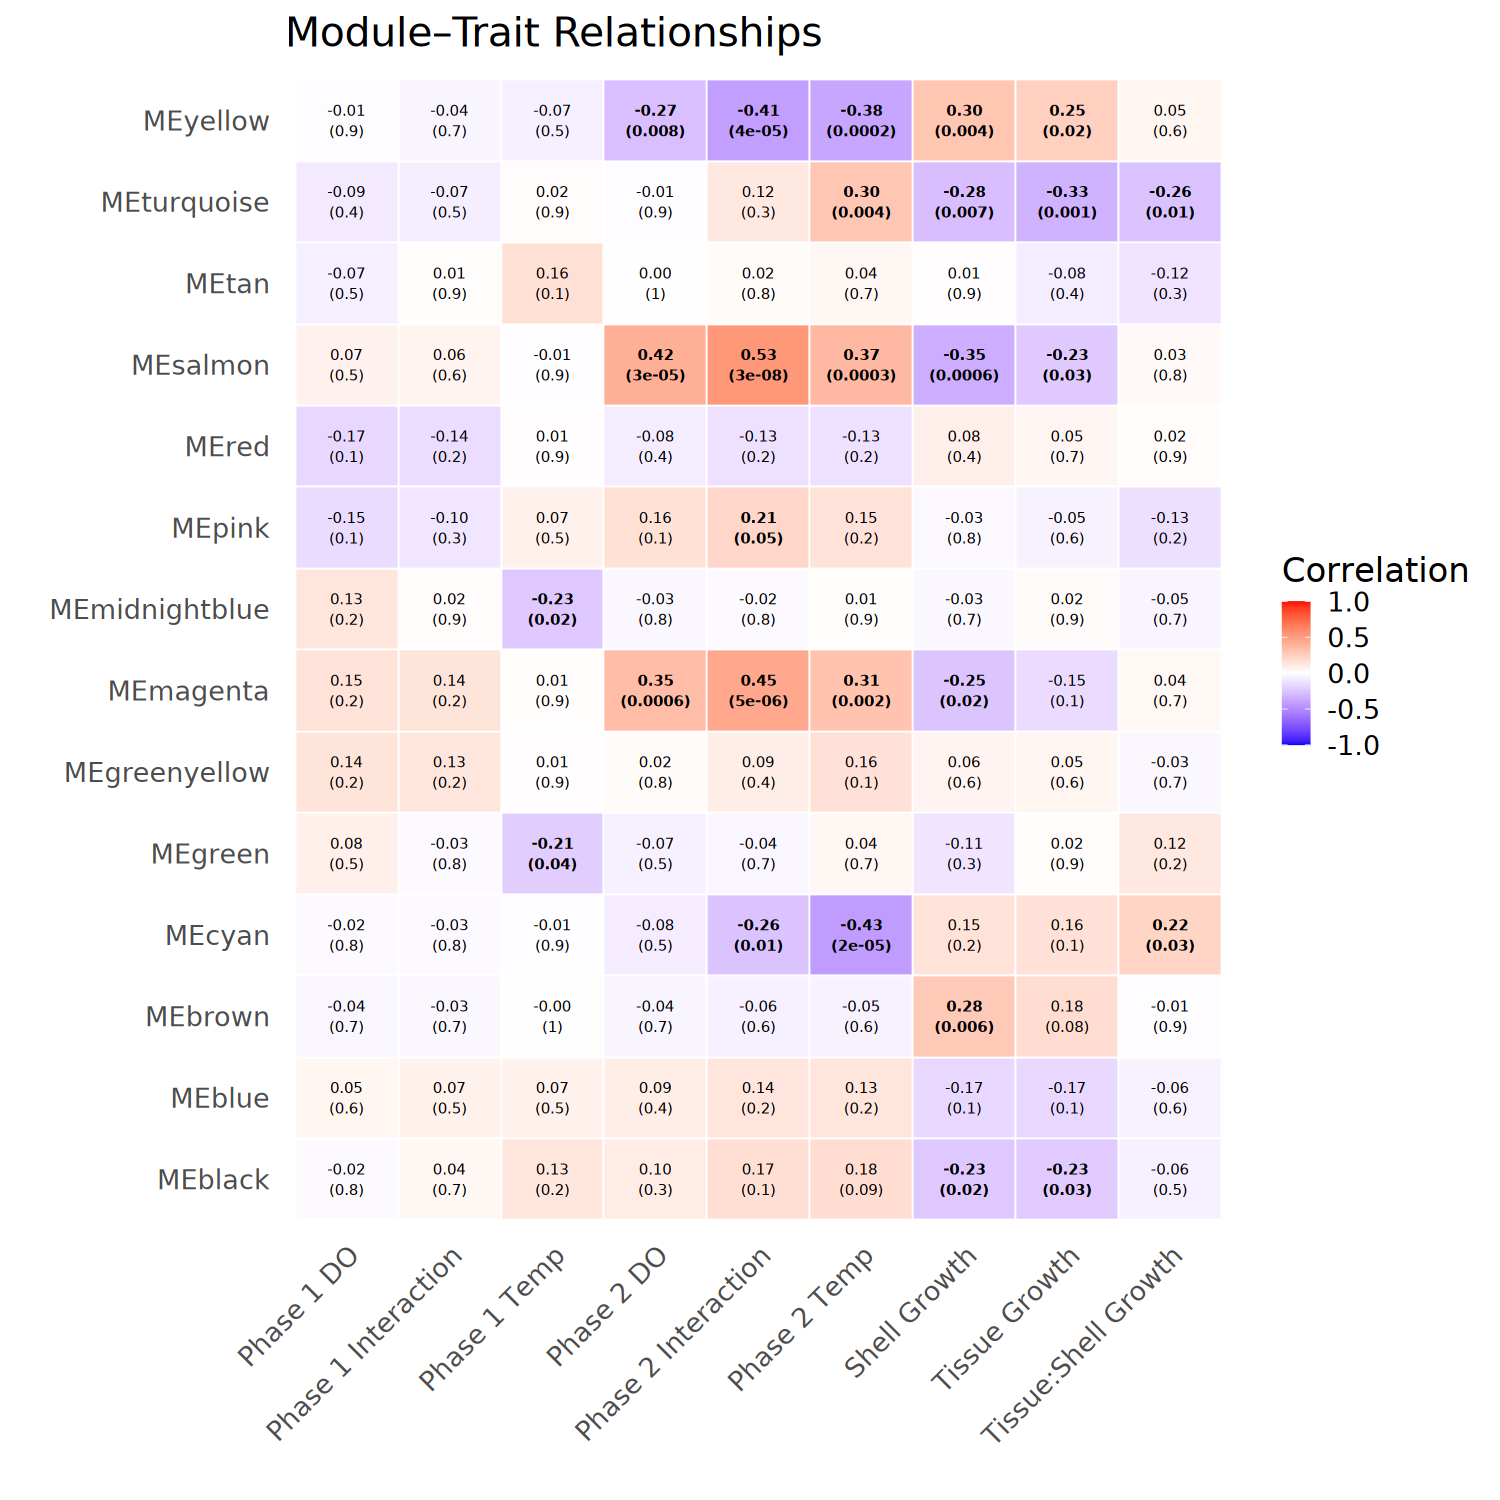

In [183]:
options(repr.plot.width = 12.5, repr.plot.height = 12.5)

ggplot(df.clean, aes(x = Trait, y = module, fill = Cor)) +
  geom_tile(color = "white") +
  
  # text annotations
  geom_text(
    aes(
      label = label,
      fontface = ifelse(sig, "bold", "plain")
    ),
    size = 3
  ) +
  
  scale_fill_gradient2(
    low = "blue",
    mid = "white",
    high = "red",
    limits = c(-1, 1)
  ) +
  
  theme_minimal(base_size = 20) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid = element_blank()
  ) +
  
  labs(
    title = "Module–Trait Relationships",
    x = "",
    y = "",
    fill = "Correlation"
  )

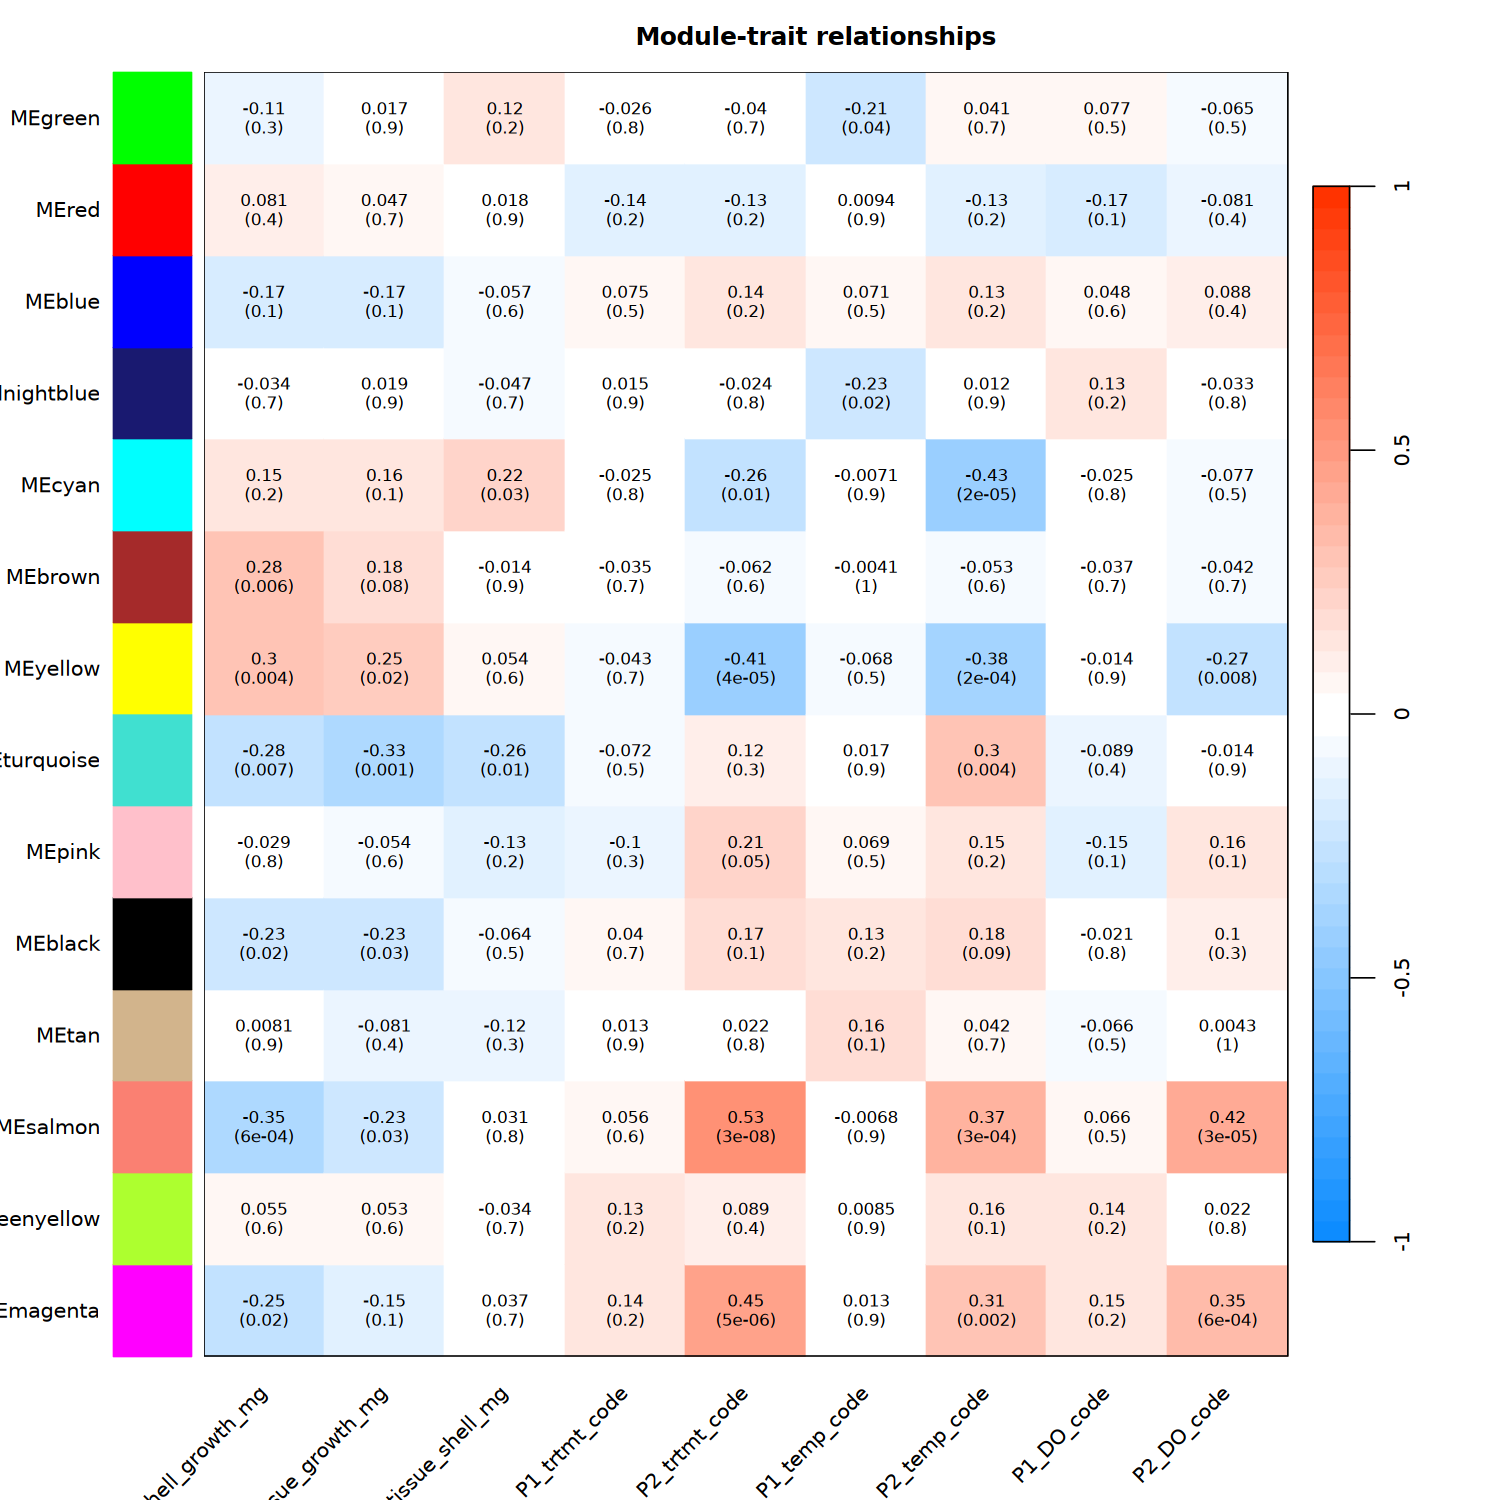

In [52]:
options(repr.plot.width = 12.5, repr.plot.height = 12.5)

# Will display correlations and their p-values
textMatrix = paste(signif(moduleTraitCor, 2), "\n(",
signif(moduleTraitPvalue, 1), ")", sep = "");
dim(textMatrix) = dim(moduleTraitCor)
par(mar = c(6, 8.5, 3, 3))

# Display the correlation values within a heatmap plot
labeledHeatmap(Matrix = moduleTraitCor, 
               xLabels = names(metaData_merge), 
               yLabels = names(MEs),
               ySymbols = names(MEs),
               colorLabels = FALSE,
               colors = blueWhiteRed(50),
               textMatrix = textMatrix,
               setStdMargins = FALSE,
               cex.text = 0.8,
               zlim = c(-1,1),
               main = paste("Module-trait relationships"))

each row corresponds to a module eigengene, column to a treatment

each cell contains the corresponding correlation and p-value and the table is colored by correlation (in my case, I've assigned numerical codes to categorical treatments, with the control/normoxic/ambient treatment always being 1)

red cells indicate positive correlation, blue cells a negative correlation - looking for dark cells with significant pvalues to identify module of interest

**specifically looking for...**:
- modules with opposing relationships between phase 1 and phase 2 (whether that's DO, temp, or treatment altogether; can also be growth as in red for tissue but blue for shell)
- modules with significant relationships (number within the paratheses)

**observations**:
- none of the modules have a significant relationship with p1_treatment or p1_DO, which makes sense since these samples were taken after p2 and we expect most GE to be short-term
    - there are 5 modules with a sig. relationship with p2_treatment (three red and two blue)
- there are 3 modules with a sig. relationship with a DO treatment (cols 8 and 9) and 7 modules with a significant relationship with a temp treatment (cols 6 and 7)
- there are a few modules with sig. relationships with tissue/shell growth, and they're in the same direction for tissue and shell
    - only 2 modules with a sig. relationship with the ratio of tissue to shell growth, one pos. and one neg.

based on this, **potentially interesting modules include**:
- for **P2_trtmt_code**: MEsalmon, MEmagent, MEyellow
- for **Actual_shell_growth_mg**: MEbrown, MEsalmon, MEturquoise
- for **Actual_tissue_growth_mg**: MEturquoise
- for **P1_Temp_code**: MEmidnightblue
- for **P2_Temp_code**: MEyellow, MEsalmon, MEcyan
- for **P2_DO_code**: MEyellow, MEsalmon, MEmagenta



In [53]:
# write csv to save the module eigengenes
# write.csv(MEs, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/p2.wgcna_ModuleEigengenes.csv')

#### module-trait relationship splitting phase 1 and 2 treatments

In [54]:
MEs <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/p2.wgcna_ModuleEigengenes.csv')
rownames(MEs) <- MEs$X

MEs <- MEs %>% select(-X)

head(MEs)

,MEgreen,MEred,MEblue,MEmidnightblue,MEcyan,MEbrown,MEyellow,MEturquoise,MEpink,MEblack,MEtan,MEsalmon,MEgreenyellow,MEmagenta
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B1_B1_O01,-0.07267705,0.009714088,0.07436860,0.09833391,-0.02897813,-0.08966684,-0.045985040,-0.057655106,-0.01372923,0.12300519,-0.008507769,0.03748471,-0.003100380,0.0569358089
B1_W5_O50,0.11259458,-0.111083731,-0.01475526,0.06474712,0.02224133,-0.04285216,0.069049606,0.024580716,-0.06167656,-0.08471081,-0.060693622,-0.07017904,0.085117905,0.0008981644
B2_B5_O51,-0.08984971,-0.182351212,-0.06468166,0.02734566,0.05313499,0.01917650,0.071772224,0.053675425,0.01991438,0.18247916,0.615392900,-0.03895601,0.135324346,0.1043639581
B2_C4_O40,0.10140997,0.079992546,0.04727654,0.09989979,0.05347520,-0.07355731,0.008702442,-0.005810909,-0.04119296,-0.06401295,-0.054877888,-0.10511121,-0.083771035,-0.1177197358
B3_B4_O41,0.09981873,-0.152270648,-0.04321488,0.05547935,0.01493320,-0.02548241,0.075045647,0.035097388,-0.02785136,-0.07482059,-0.066988659,-0.04015863,0.090254076,0.0899543403
B3_C3_O30,0.13421227,-0.054919285,-0.22153019,-0.02394812,0.10739413,0.13503628,0.107547430,-0.016895555,-0.03253327,-0.07544965,-0.077105937,-0.04242012,-0.004583379,-0.0529921250


In [55]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/p2.wgcna_metadata.csv') %>%
select(-c(X, Phase1_TankRep, Phase2_TankRep, Actual_shell_growth_mg, Actual_tissue_growth_mg, Ratio_tissue_shell_mg)) %>% # remove cols we don't need like tank reps - not focusing on growth here either rn
distinct(Sample, .keep_all = TRUE) # at some point, rows got duplicated, so just keeping the distinct rows

# set rownames as sample names
rownames(meta) <- meta$Sample

# check out df
dim(meta)
head(meta)

[1] 93  8

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase2_treatment,Phase2_temp,Phase2_DO,combo_trtmt
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
B1_B1_O01,B1_B1_O01,both,warm,hypoxic,both,warm,hypoxic,both_both
B1_W5_O50,B1_W5_O50,both,warm,hypoxic,warm,warm,normoxic,both_warm
B2_B5_O51,B2_B5_O51,both,warm,hypoxic,both,warm,hypoxic,both_both
B2_C4_O40,B2_C4_O40,both,warm,hypoxic,control,ambient,normoxic,both_control
B3_B4_O41,B3_B4_O41,both,warm,hypoxic,both,warm,hypoxic,both_both
B3_C3_O30,B3_C3_O30,both,warm,hypoxic,control,ambient,normoxic,both_control


In [56]:
# add factors
meta$Phase1_DO <- factor(meta$Phase1_DO, c('normoxic', 'hypoxic'))
meta$Phase2_DO <- factor(meta$Phase2_DO, c('normoxic', 'hypoxic'))
meta$Phase1_temp <- factor(meta$Phase1_temp, c('ambient', 'warm'))
meta$Phase2_temp <- factor(meta$Phase2_temp, c('ambient', 'warm'))

will want to create dummy variables for WGCNA - basically 0/1 to denate yes or no to a treatment

In [57]:
# creating dummy variables

#### PHASE 1 ####
# phase 1 treatments
phase1.treatments <- meta %>%
  select(Sample, Phase1_treatment) %>%
  mutate(value = 1) %>%
  pivot_wider(
    id_cols = Sample,
    names_from = Phase1_treatment,
    values_from = value,
    values_fill = list(value = 0)
  )

head(phase1.treatments)

# phase 1 DO
phase1.DO <- meta %>%
  select(Sample, Phase1_DO) %>%
  mutate(value = 1) %>%
  pivot_wider(
    id_cols = Sample,
    names_from = Phase1_DO,
    values_from = value,
    values_fill = list(value = 0)
  )

# phase 1 temperature
phase1.temp <- meta %>%
  select(Sample, Phase1_temp) %>%
  mutate(value = 1) %>%
  pivot_wider(
    id_cols = Sample,
    names_from = Phase1_temp,
    values_from = value,
    values_fill = list(value = 0)
  )


#### PHASE 2 ####
# phase 2 treatments
phase2.treatments <- meta %>%
  select(Sample, Phase2_treatment) %>%
  mutate(value = 1) %>%
  pivot_wider(
    id_cols = Sample,
    names_from = Phase2_treatment,
    values_from = value,
    values_fill = list(value = 0)
  )

# phase 2 DO
phase2.DO <- meta %>%
  select(Sample, Phase2_DO) %>%
  mutate(value = 1) %>%
  pivot_wider(
    id_cols = Sample,
    names_from = Phase2_DO,
    values_from = value,
    values_fill = list(value = 0)
  )

# phase 2 temperature
phase2.temp <- meta %>%
  select(Sample, Phase2_temp) %>%
  mutate(value = 1) %>%
  pivot_wider(
    id_cols = Sample,
    names_from = Phase2_temp,
    values_from = value,
    values_fill = list(value = 0)
  )

head(phase2.DO)

#### P1/P2 COMBO ####
combo.treatments <- meta %>%
  select(Sample, combo_trtmt) %>%
  mutate(value = 1) %>%
  pivot_wider(
    id_cols = Sample,
    names_from = combo_trtmt,
    values_from = value,
    values_fill = list(value = 0)
  )

head(combo.treatments)

Sample,both,control,hypoxic,warm
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
B1_B1_O01,1,0,0,0
B1_W5_O50,1,0,0,0
B2_B5_O51,1,0,0,0
B2_C4_O40,1,0,0,0
B3_B4_O41,1,0,0,0
B3_C3_O30,1,0,0,0


Sample,hypoxic,normoxic
<chr>,<dbl>,<dbl>
B1_B1_O01,1,0
B1_W5_O50,0,1
B2_B5_O51,1,0
B2_C4_O40,0,1
B3_B4_O41,1,0
B3_C3_O30,0,1


Sample,both_both,both_warm,both_control,both_hypoxic,control_control,control_hypoxic,control_both,control_warm,hypoxic_both,hypoxic_control,hypoxic_warm,hypoxic_hypoxic,warm_control,warm_hypoxic,warm_warm,warm_both
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B1_B1_O01,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
B1_W5_O50,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
B2_B5_O51,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
B2_C4_O40,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
B3_B4_O41,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
B3_C3_O30,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [58]:
nSamples <- nrow(dataExpr) # 93 samples
nGenes <- ncol(dataExpr) # 26547 genes

In [59]:
# module trait correlation

## PHASE 1 ##
# phase 1 treatment
moduleTraitCor_p1 = cor(MEs, phase1.treatments[-1], use = "p")
moduleTraitPvalue_p1 = corPvalueStudent(moduleTraitCor_p1, nSamples)

# phase 1 DO
moduleTraitCor_p1.DO = cor(MEs, phase1.DO[-1], use = "p")
moduleTraitPvalue_p1.DO = corPvalueStudent(moduleTraitCor_p1.DO, nSamples)

# phase 1 temp
moduleTraitCor_p1.temp = cor(MEs, phase1.temp[-1], use = "p")
moduleTraitPvalue_p1.temp = corPvalueStudent(moduleTraitCor_p1.temp, nSamples)

## PHASE 2 ##
# phase 2 treatment
moduleTraitCor_p2 = cor(MEs, phase2.treatments[-1], use = "p")
moduleTraitPvalue_p2 = corPvalueStudent(moduleTraitCor_p2, nSamples)

# phase 2 DO
moduleTraitCor_p2.DO = cor(MEs, phase2.DO[-1], use = "p")
moduleTraitPvalue_p2.DO = corPvalueStudent(moduleTraitCor_p2.DO, nSamples)

# phase 2 temp
moduleTraitCor_p2.temp = cor(MEs, phase2.temp[-1], use = "p")
moduleTraitPvalue_p2.temp = corPvalueStudent(moduleTraitCor_p2.temp, nSamples)

## P1/P2 COMBO ##
moduleTraitCor_combo = cor(MEs, combo.treatments[-1], use = "p")
moduleTraitPvalue_combo = corPvalueStudent(moduleTraitCor_combo, nSamples)

#### phase 1 treatments

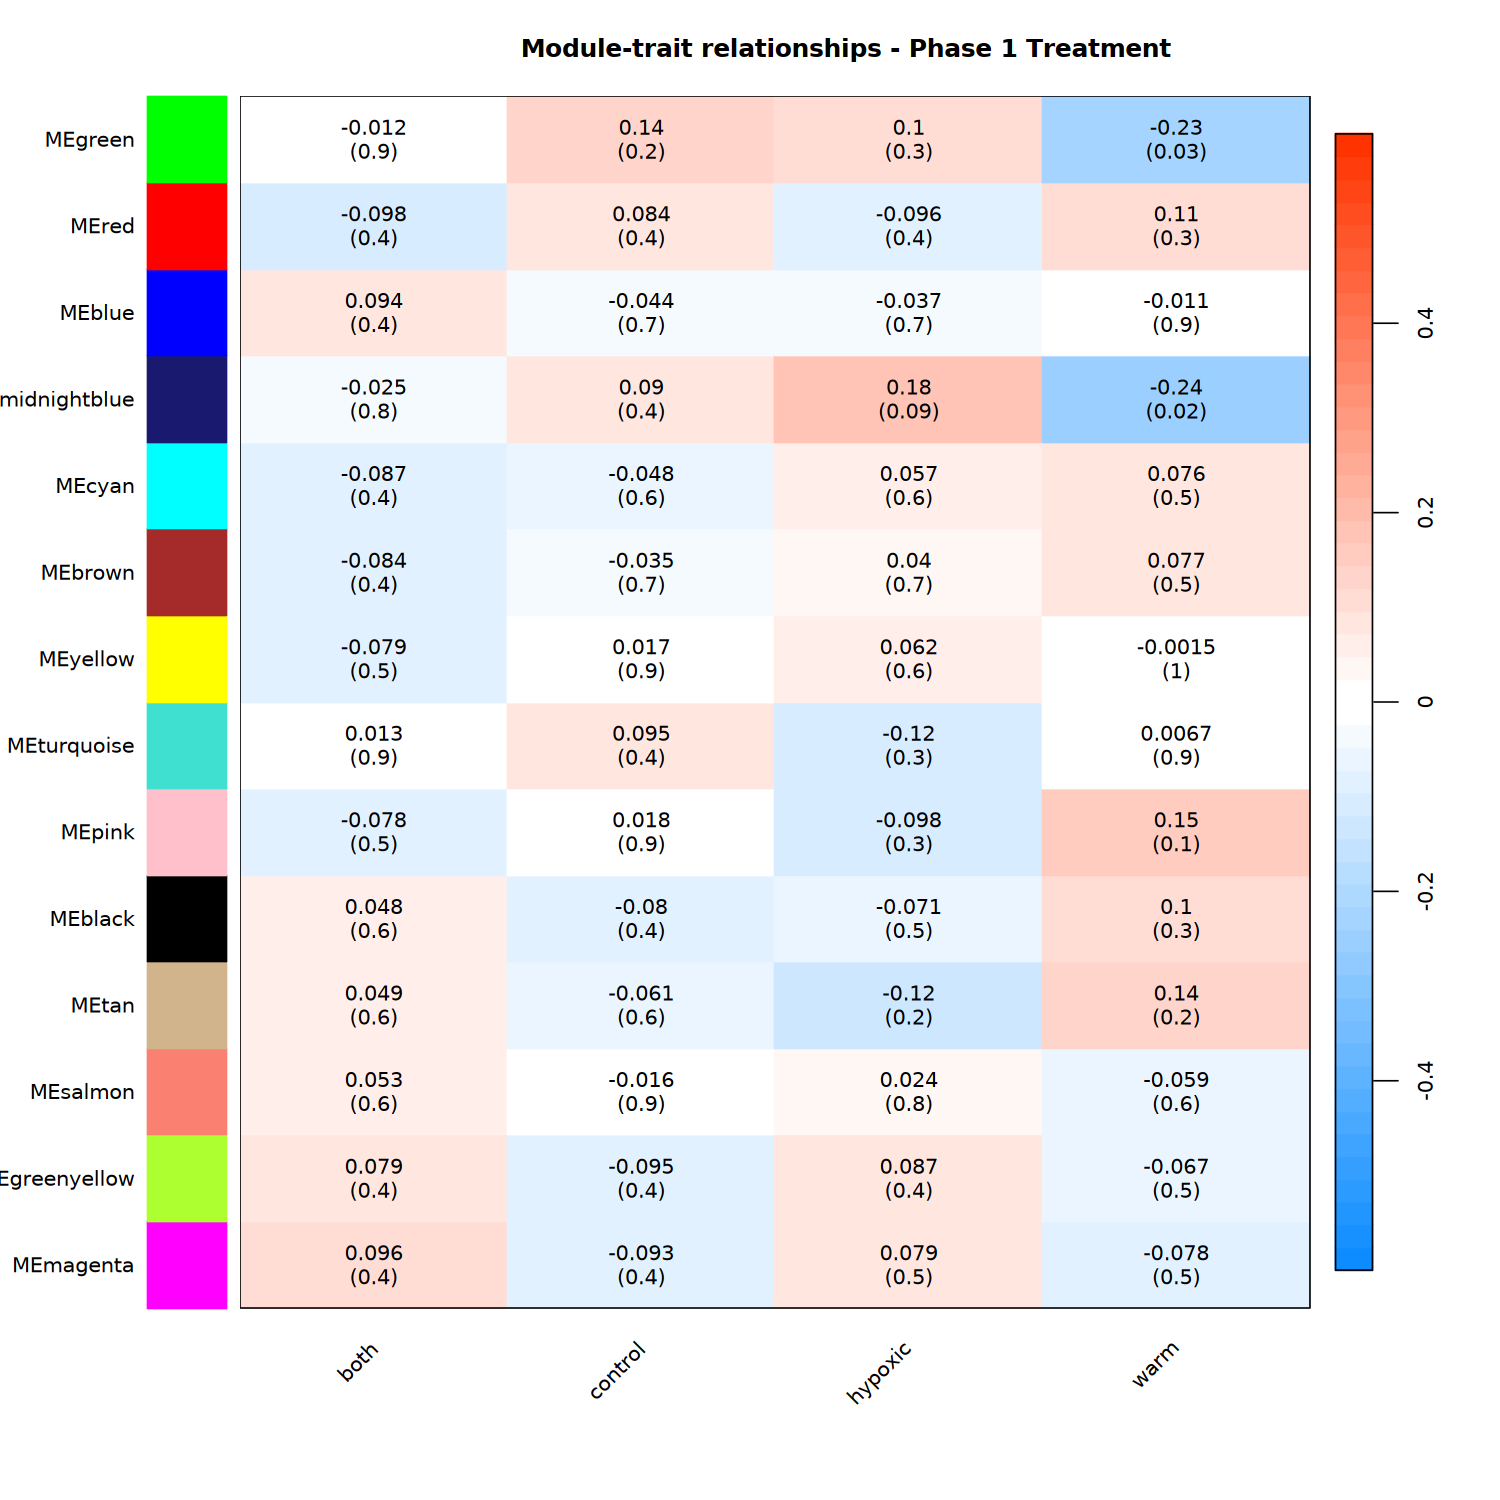

In [60]:
phase1.treatments.matrix <-  paste(signif(moduleTraitCor_p1, 2), "\n(",
                                      signif(moduleTraitPvalue_p1, 1), ")", sep = "")

par(mar = c(8, 10, 4, 2))  # increase bottom & left margins

labeledHeatmap(Matrix = moduleTraitCor_p1,
               xLabels = names(phase1.treatments[-1]),
               yLabels = names(MEs),
               ySymbols = names(MEs),
               colorLabels = TRUE,
               colors = blueWhiteRed(50),
               textMatrix = phase1.treatments.matrix,
               setStdMargins = FALSE,
               cex.text = 1,
               zlim = c(-0.6,0.6),
               main = paste("Module-trait relationships - Phase 1 Treatment"))

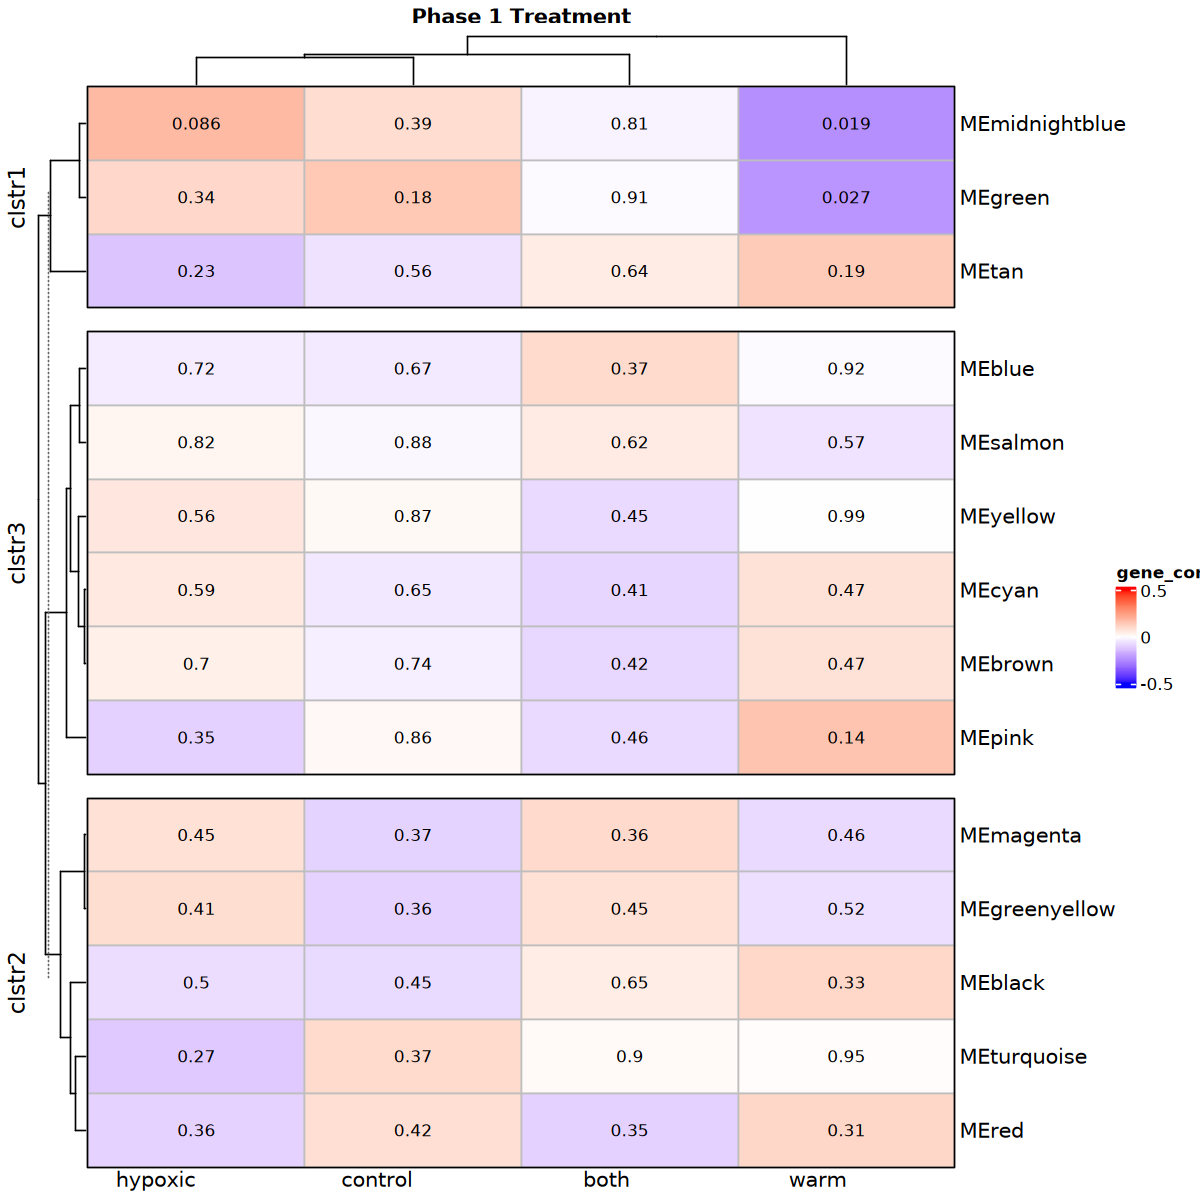

In [61]:
options(repr.plot.width = 10, repr.plot.height = 10)

p1.treatment.text <-  as.matrix(signif(moduleTraitPvalue_p1, 4))
# cluster modules based on p-value similarity
pa = cluster::pam(p1.treatment.text, k = 3)
col_fun = colorRamp2(c(-0.5, 0, 0.5), c("blue", "white", "red"))

p1_treatment.heatmap <- Heatmap(moduleTraitCor_p1, 
        name = "gene_cor", 
        rect_gp = gpar(col = "grey", lwd = 1),
        column_title = "Phase 1 Treatment", 
        column_title_gp = gpar(fontsize = 12, fontface = "bold"),
        # row_title = "WGCNA modules",
        #row_km = 4, 
        column_names_rot = 0,
        column_km = 1,
        row_split = paste0("clstr", pa$clustering),
        row_gap = unit(5, "mm"),
        column_gap = unit(5, "mm"),
        # grid.text(matrix(textMatrix)),
        # border = TRUE,
        border = TRUE,
        col = col_fun,
        cell_fun = function(j, i, x, y, width, height, fill) {
          grid.text(sprintf("%.2g", p1.treatment.text[i, j]), x, y,
          gp = gpar(fontsize = 10))
        })

p1_treatment.heatmap

so the color denotes the correlation, the text within the heatmap denotes the p-value

**higher module eigengene-treatment correlation = higher expression of the module with the given trait/treatment**
- red = lower expression in the given treatment
- blue = higher expression in the given treatment

#### conclusions here:
- only two significantly correlated modules: midnight blue and green
- midnight blue and green are neg. correlated with phase 1 warm (these genes have lower expression in phase 1 warm vs. everything else aka H,C,B)

#### phase 1 temp

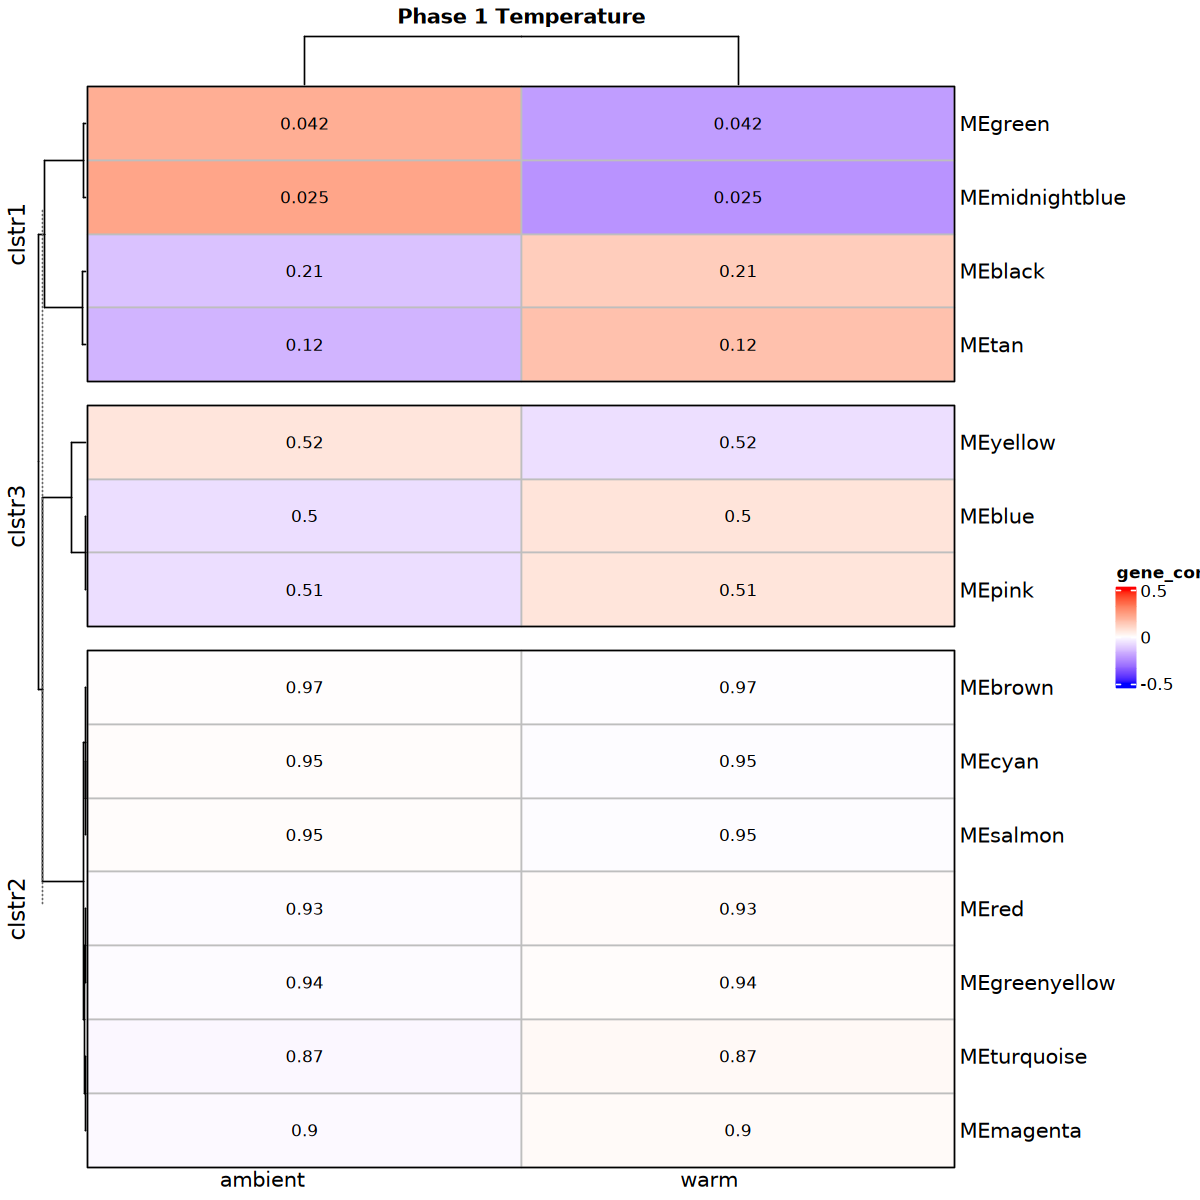

In [62]:
options(repr.plot.width = 10, repr.plot.height = 10)

p1.temp.text <-  as.matrix(signif(moduleTraitPvalue_p1.temp, 4))
# cluster modules based on p-value similarity
pa = cluster::pam(p1.temp.text, k = 3)
col_fun = colorRamp2(c(-0.5, 0, 0.5), c("blue", "white", "red"))

p1_temp.heatmap <- Heatmap(moduleTraitCor_p1.temp, 
        name = "gene_cor", 
        rect_gp = gpar(col = "grey", lwd = 1),
        column_title = "Phase 1 Temperature", 
        column_title_gp = gpar(fontsize = 12, fontface = "bold"),
        # row_title = "WGCNA modules",
        #row_km = 4, 
        column_names_rot = 0,
        column_km = 1,
        row_split = paste0("clstr", pa$clustering),
        row_gap = unit(5, "mm"),
        column_gap = unit(5, "mm"),
        # grid.text(matrix(textMatrix)),
        # border = TRUE,
        border = TRUE,
        col = col_fun,
        cell_fun = function(j, i, x, y, width, height, fill) {
          grid.text(sprintf("%.2g", p1.temp.text[i, j]), x, y,
          gp = gpar(fontsize = 10))
        })

p1_temp.heatmap

#### conclusions here:
- only two significantly correlated modules: midnight blue and green (and they're the same two signif. modules as phase 1 treatments)
- midnight blue and green are neg. correlated with warm and pos. correlated with ambient - so, these genes have lower expression in phase 1 warming and higher expression in phase 1 control conditions, despite experiencing a second exposure
    - this makes sense/follows from the previous heatmap of phase 1 treatments

#### phase 1 DO

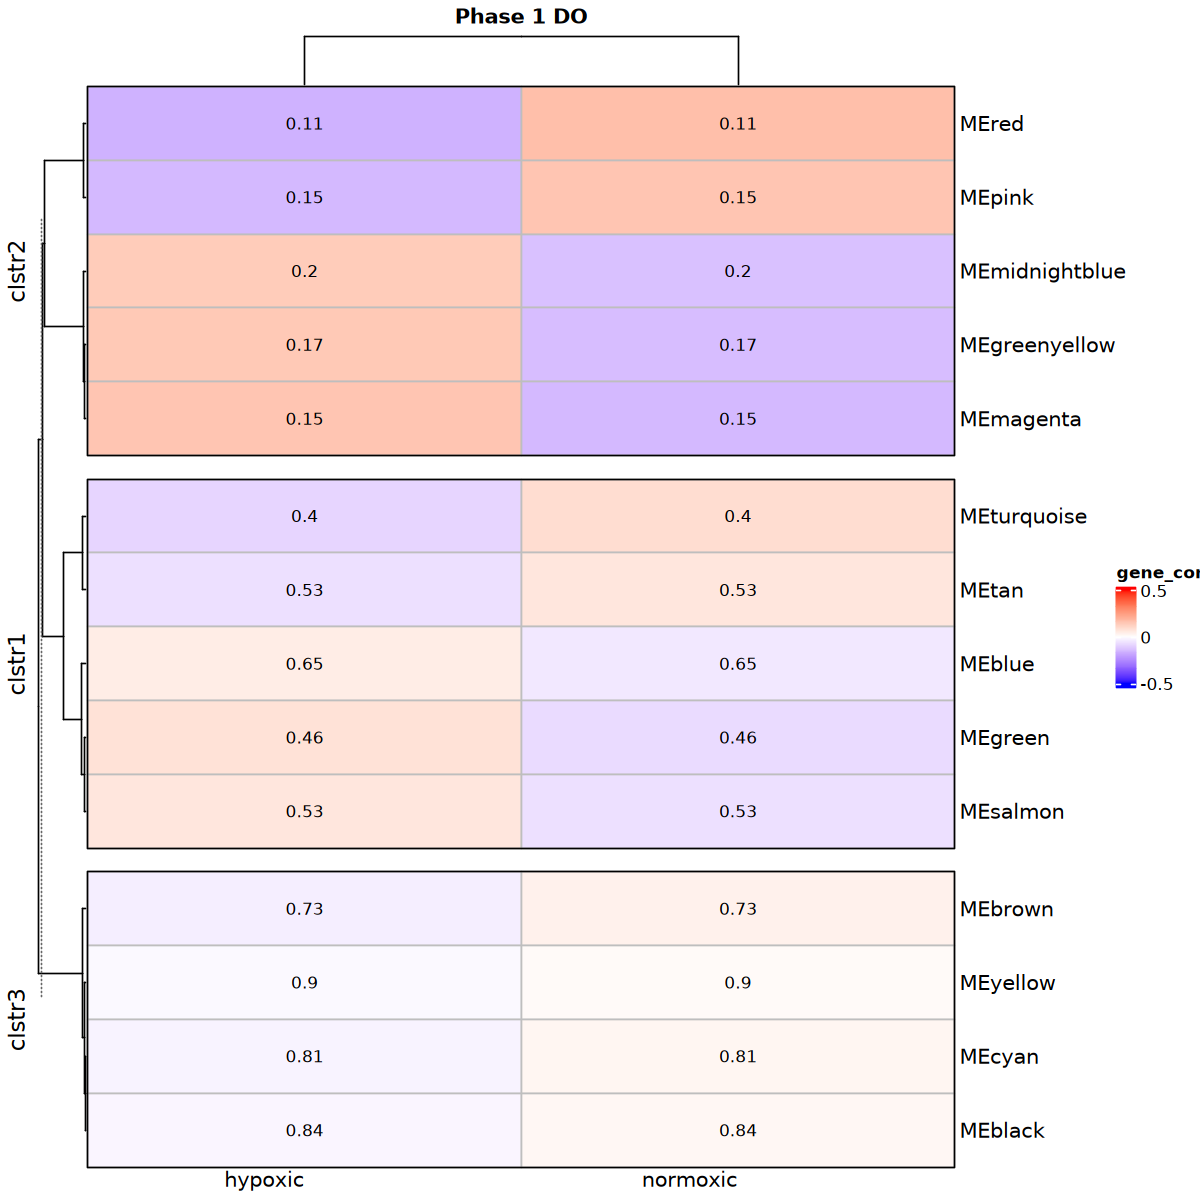

In [63]:
options(repr.plot.width = 10, repr.plot.height = 10)

p1.DO.text <-  as.matrix(signif(moduleTraitPvalue_p1.DO, 4))
# cluster modules based on p-value similarity
pa = cluster::pam(p1.DO.text, k = 3)
col_fun = colorRamp2(c(-0.5, 0, 0.5), c("blue", "white", "red"))

p1_DO.heatmap <- Heatmap(moduleTraitCor_p1.DO, 
        name = "gene_cor", 
        rect_gp = gpar(col = "grey", lwd = 1),
        column_title = "Phase 1 DO", 
        column_title_gp = gpar(fontsize = 12, fontface = "bold"),
        # row_title = "WGCNA modules",
        #row_km = 4, 
        column_names_rot = 0,
        column_km = 1,
        row_split = paste0("clstr", pa$clustering),
        row_gap = unit(5, "mm"),
        column_gap = unit(5, "mm"),
        # grid.text(matrix(textMatrix)),
        # border = TRUE,
        border = TRUE,
        col = col_fun,
        cell_fun = function(j, i, x, y, width, height, fill) {
          grid.text(sprintf("%.2g", p1.DO.text[i, j]), x, y,
          gp = gpar(fontsize = 10))
        })

p1_DO.heatmap

#### conclusions here:
- no significant modules for phase 1 DO

#### phase 2 treatment

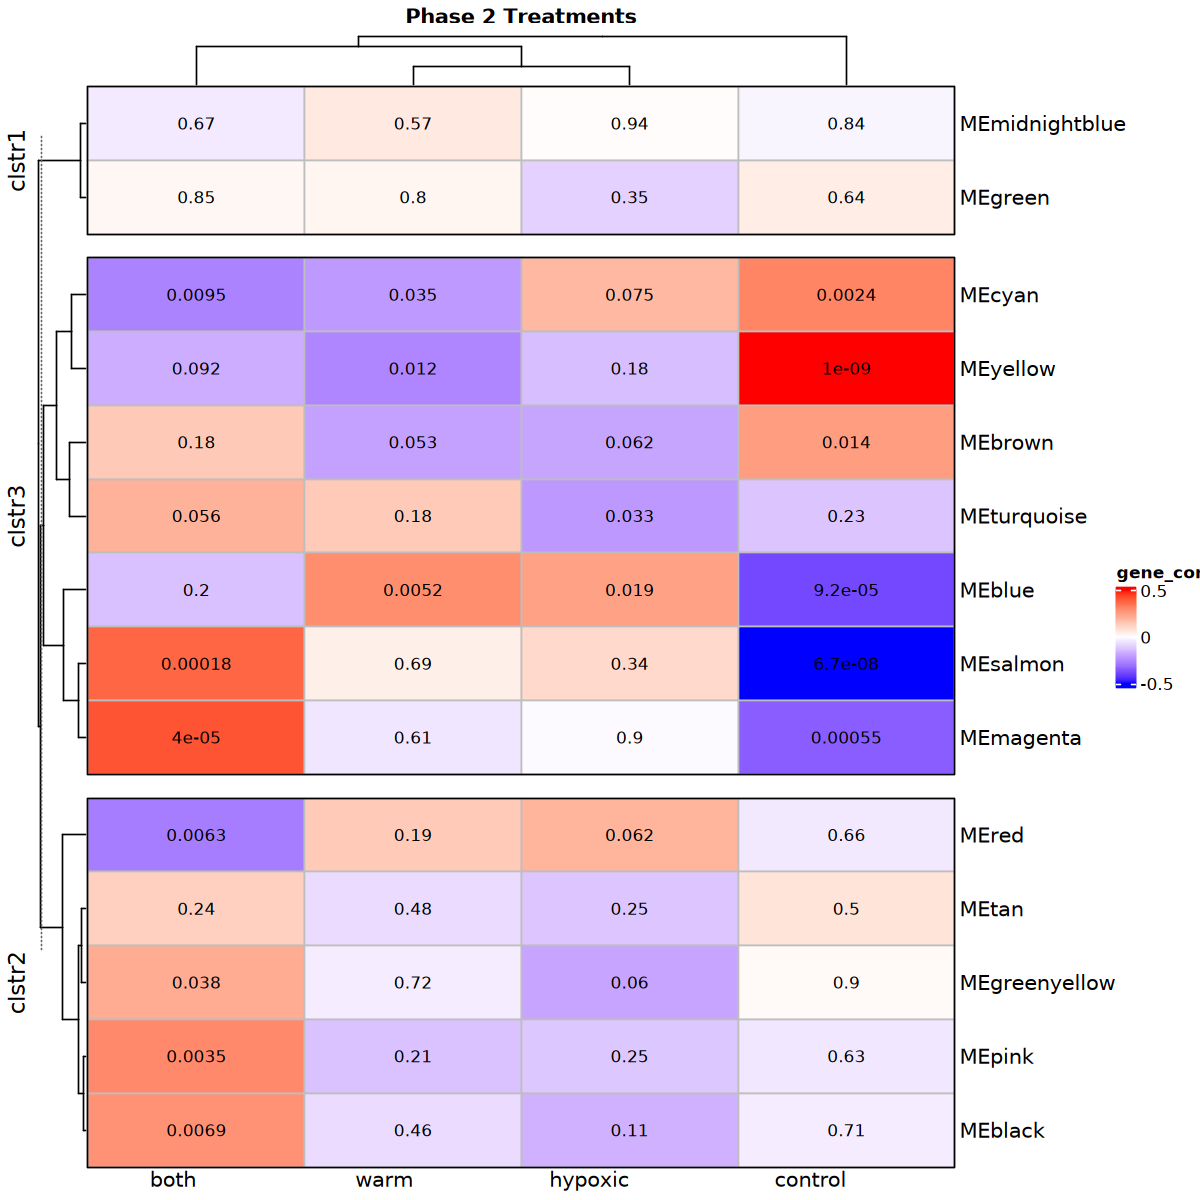

In [64]:
options(repr.plot.width = 10, repr.plot.height = 10)

p2.treatment.text <-  as.matrix(signif(moduleTraitPvalue_p2, 4))
# cluster modules based on p-value similarity
pa = cluster::pam(p2.treatment.text, k = 3)
col_fun = colorRamp2(c(-0.5, 0, 0.5), c("blue", "white", "red"))

p2_treatment.heatmap <- Heatmap(moduleTraitCor_p2, 
        name = "gene_cor", 
        rect_gp = gpar(col = "grey", lwd = 1),
        column_title = "Phase 2 Treatments", 
        column_title_gp = gpar(fontsize = 12, fontface = "bold"),
        # row_title = "WGCNA modules",
        #row_km = 4, 
        column_names_rot = 0,
        column_km = 1,
        row_split = paste0("clstr", pa$clustering),
        row_gap = unit(5, "mm"),
        column_gap = unit(5, "mm"),
        # grid.text(matrix(textMatrix)),
        # border = TRUE,
        border = TRUE,
        col = col_fun,
        cell_fun = function(j, i, x, y, width, height, fill) {
          grid.text(sprintf("%.2g", p2.treatment.text[i, j]), x, y,
          gp = gpar(fontsize = 10))
        })

p2_treatment.heatmap

#### conclusions here:
- lots of significantly correlated modules here!
    - red ~ phase 2 stressors (neg. cor with both, pos. cor with warm and hypoxic)
    - greenyellow ~ pos. both
    - pink ~ pos. both
    - black ~ pos. both
    - magenta and salmon ~ neg. control, pos. both
    - blue ~ neg. control, pos. warm
    - yellow ~ pos. control, neg. warm

#### phase 2 DO

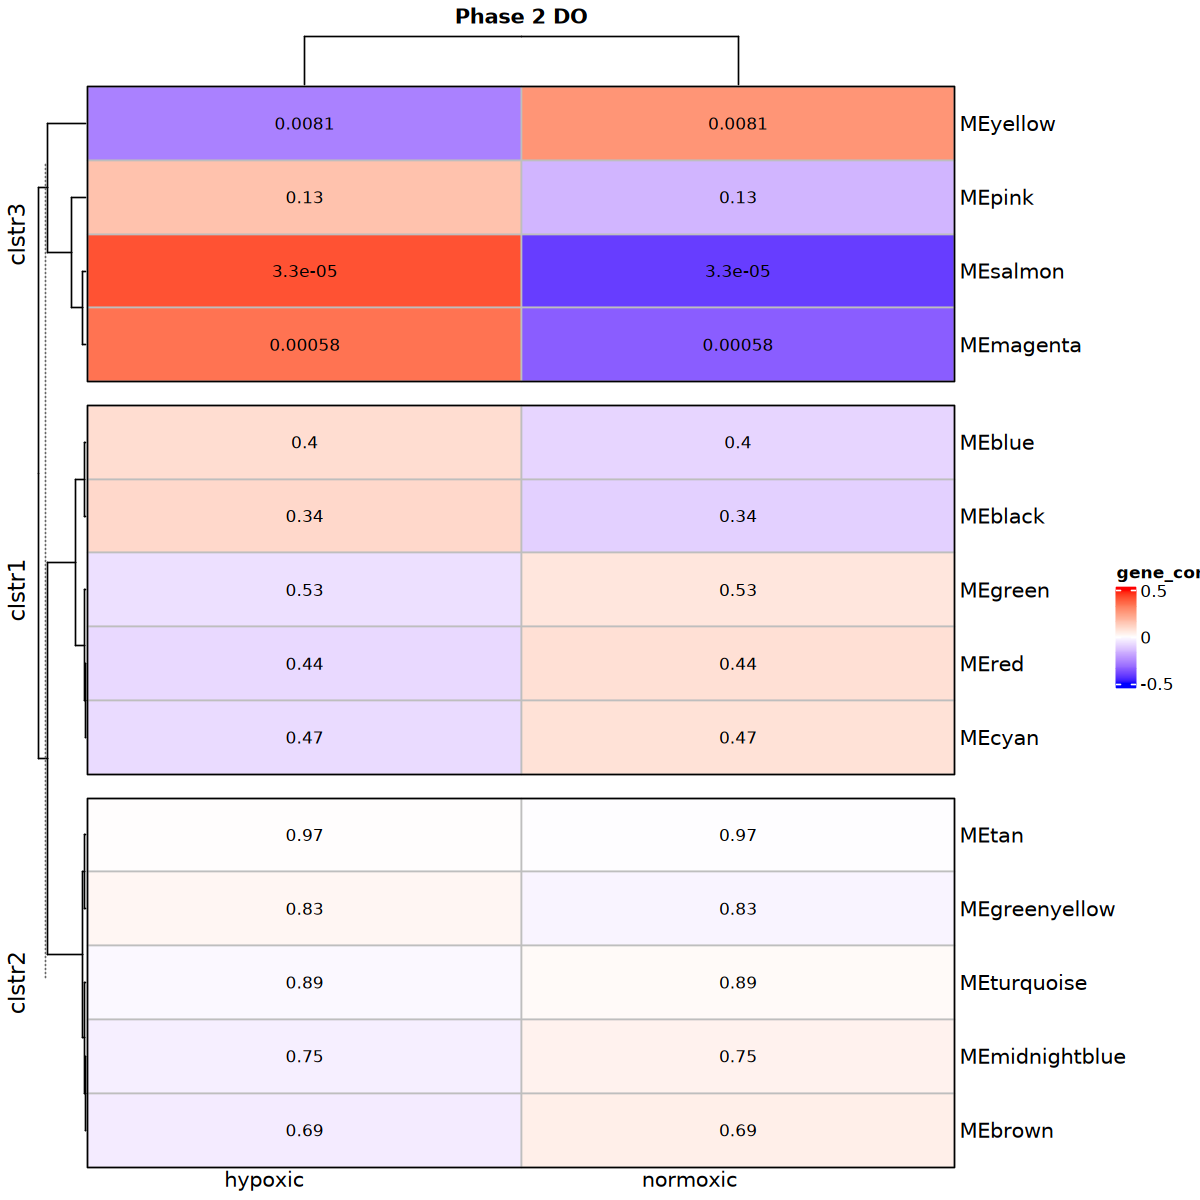

In [65]:
options(repr.plot.width = 10, repr.plot.height = 10)

p2.DO.text <-  as.matrix(signif(moduleTraitPvalue_p2.DO, 4))
# cluster modules based on p-value similarity
pa = cluster::pam(p2.DO.text, k = 3)
col_fun = colorRamp2(c(-0.5, 0, 0.5), c("blue", "white", "red"))

p2_DO.heatmap <- Heatmap(moduleTraitCor_p2.DO, 
        name = "gene_cor", 
        rect_gp = gpar(col = "grey", lwd = 1),
        column_title = "Phase 2 DO", 
        column_title_gp = gpar(fontsize = 12, fontface = "bold"),
        # row_title = "WGCNA modules",
        #row_km = 4, 
        column_names_rot = 0,
        column_km = 1,
        row_split = paste0("clstr", pa$clustering),
        row_gap = unit(5, "mm"),
        column_gap = unit(5, "mm"),
        # grid.text(matrix(textMatrix)),
        # border = TRUE,
        border = TRUE,
        col = col_fun,
        cell_fun = function(j, i, x, y, width, height, fill) {
          grid.text(sprintf("%.2g", p2.DO.text[i, j]), x, y,
          gp = gpar(fontsize = 10))
        })

p2_DO.heatmap

#### conclusions here:
- four significantly correlated modules: yellow, pink, salmon, magenta
- salmon and magenta are correlated in the same direction (neg. for normoxic, pos. for hypoxic) - meaning that the genes in those modules have higher expression in phase 2 hypoxia than normoxia (regardless of temperature treatment)

####  phase 2 temperature

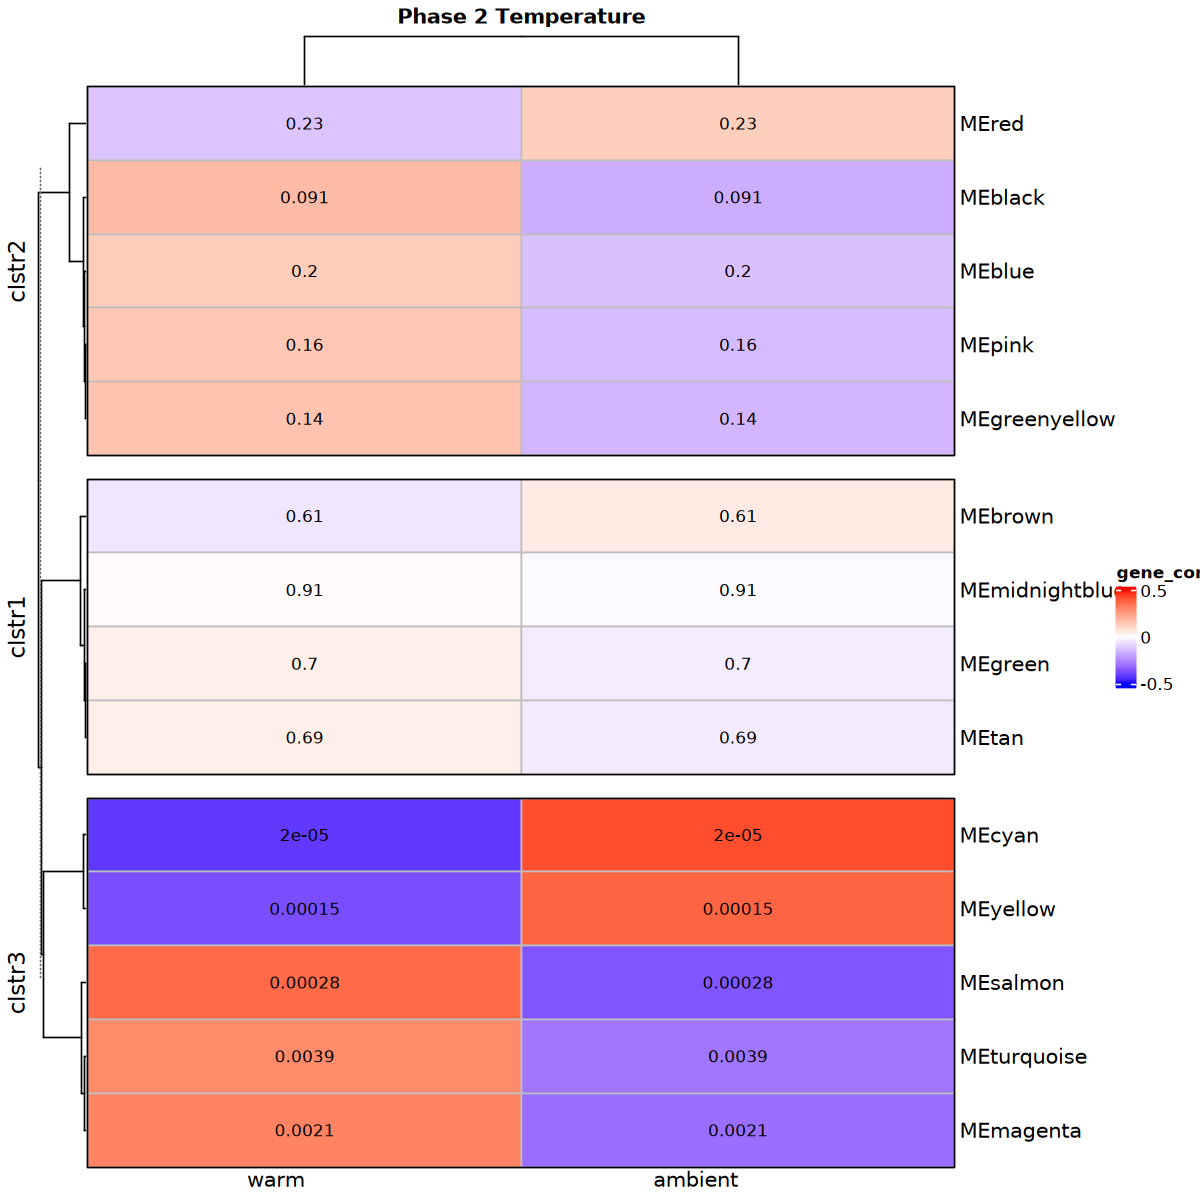

In [66]:
options(repr.plot.width = 10, repr.plot.height = 10)

p2.temp.text <-  as.matrix(signif(moduleTraitPvalue_p2.temp, 4))
# cluster modules based on p-value similarity
pa = cluster::pam(p2.temp.text, k = 3)
col_fun = colorRamp2(c(-0.5, 0, 0.5), c("blue", "white", "red"))

p2_temp.heatmap <- Heatmap(moduleTraitCor_p2.temp, 
        name = "gene_cor", 
        rect_gp = gpar(col = "grey", lwd = 1),
        column_title = "Phase 2 Temperature", 
        column_title_gp = gpar(fontsize = 12, fontface = "bold"),
        # row_title = "WGCNA modules",
        #row_km = 4, 
        column_names_rot = 0,
        column_km = 1,
        row_split = paste0("clstr", pa$clustering),
        row_gap = unit(5, "mm"),
        column_gap = unit(5, "mm"),
        # grid.text(matrix(textMatrix)),
        # border = TRUE,
        border = TRUE,
        col = col_fun,
        cell_fun = function(j, i, x, y, width, height, fill) {
          grid.text(sprintf("%.2g", p2.temp.text[i, j]), x, y,
          gp = gpar(fontsize = 10))
        })

p2_temp.heatmap

#### conclusions here:
- six significantly correlated modules - black, cyan, yellow, salmon, turquoise, and magenta
- salmon, turquoise, and magenta (and black but to a lesser degree) are all neg. correlated with ambient temperatures, meaning that they have lower expression in phase 2 ambient conditions (or higher expression in phase 2 warm conditions), regardless of DO treatment
- cyan and yellow are all neg. correlated with warm temps, meaning they have lower expression in phase 2 warm conditions

In [67]:
library(cowplot)
library(grid)

In [68]:
# 1. Create a helper function to convert ComplexHeatmap to a grob
as_grob_hm <- function(hm) {
  grid.grabExpr(draw(hm))
}

# 2. Convert all your heatmaps
p1_temp_g <- as_grob_hm(p1_temp.heatmap)
p1_DO_g <- as_grob_hm(p1_DO.heatmap)
p1_treatment_g <- as_grob_hm(p1_treatment.heatmap)
p2_temp_g <- as_grob_hm(p2_temp.heatmap)
p2_DO_g <- as_grob_hm(p2_DO.heatmap)
p2_treatment_g <- as_grob_hm(p2_treatment.heatmap)

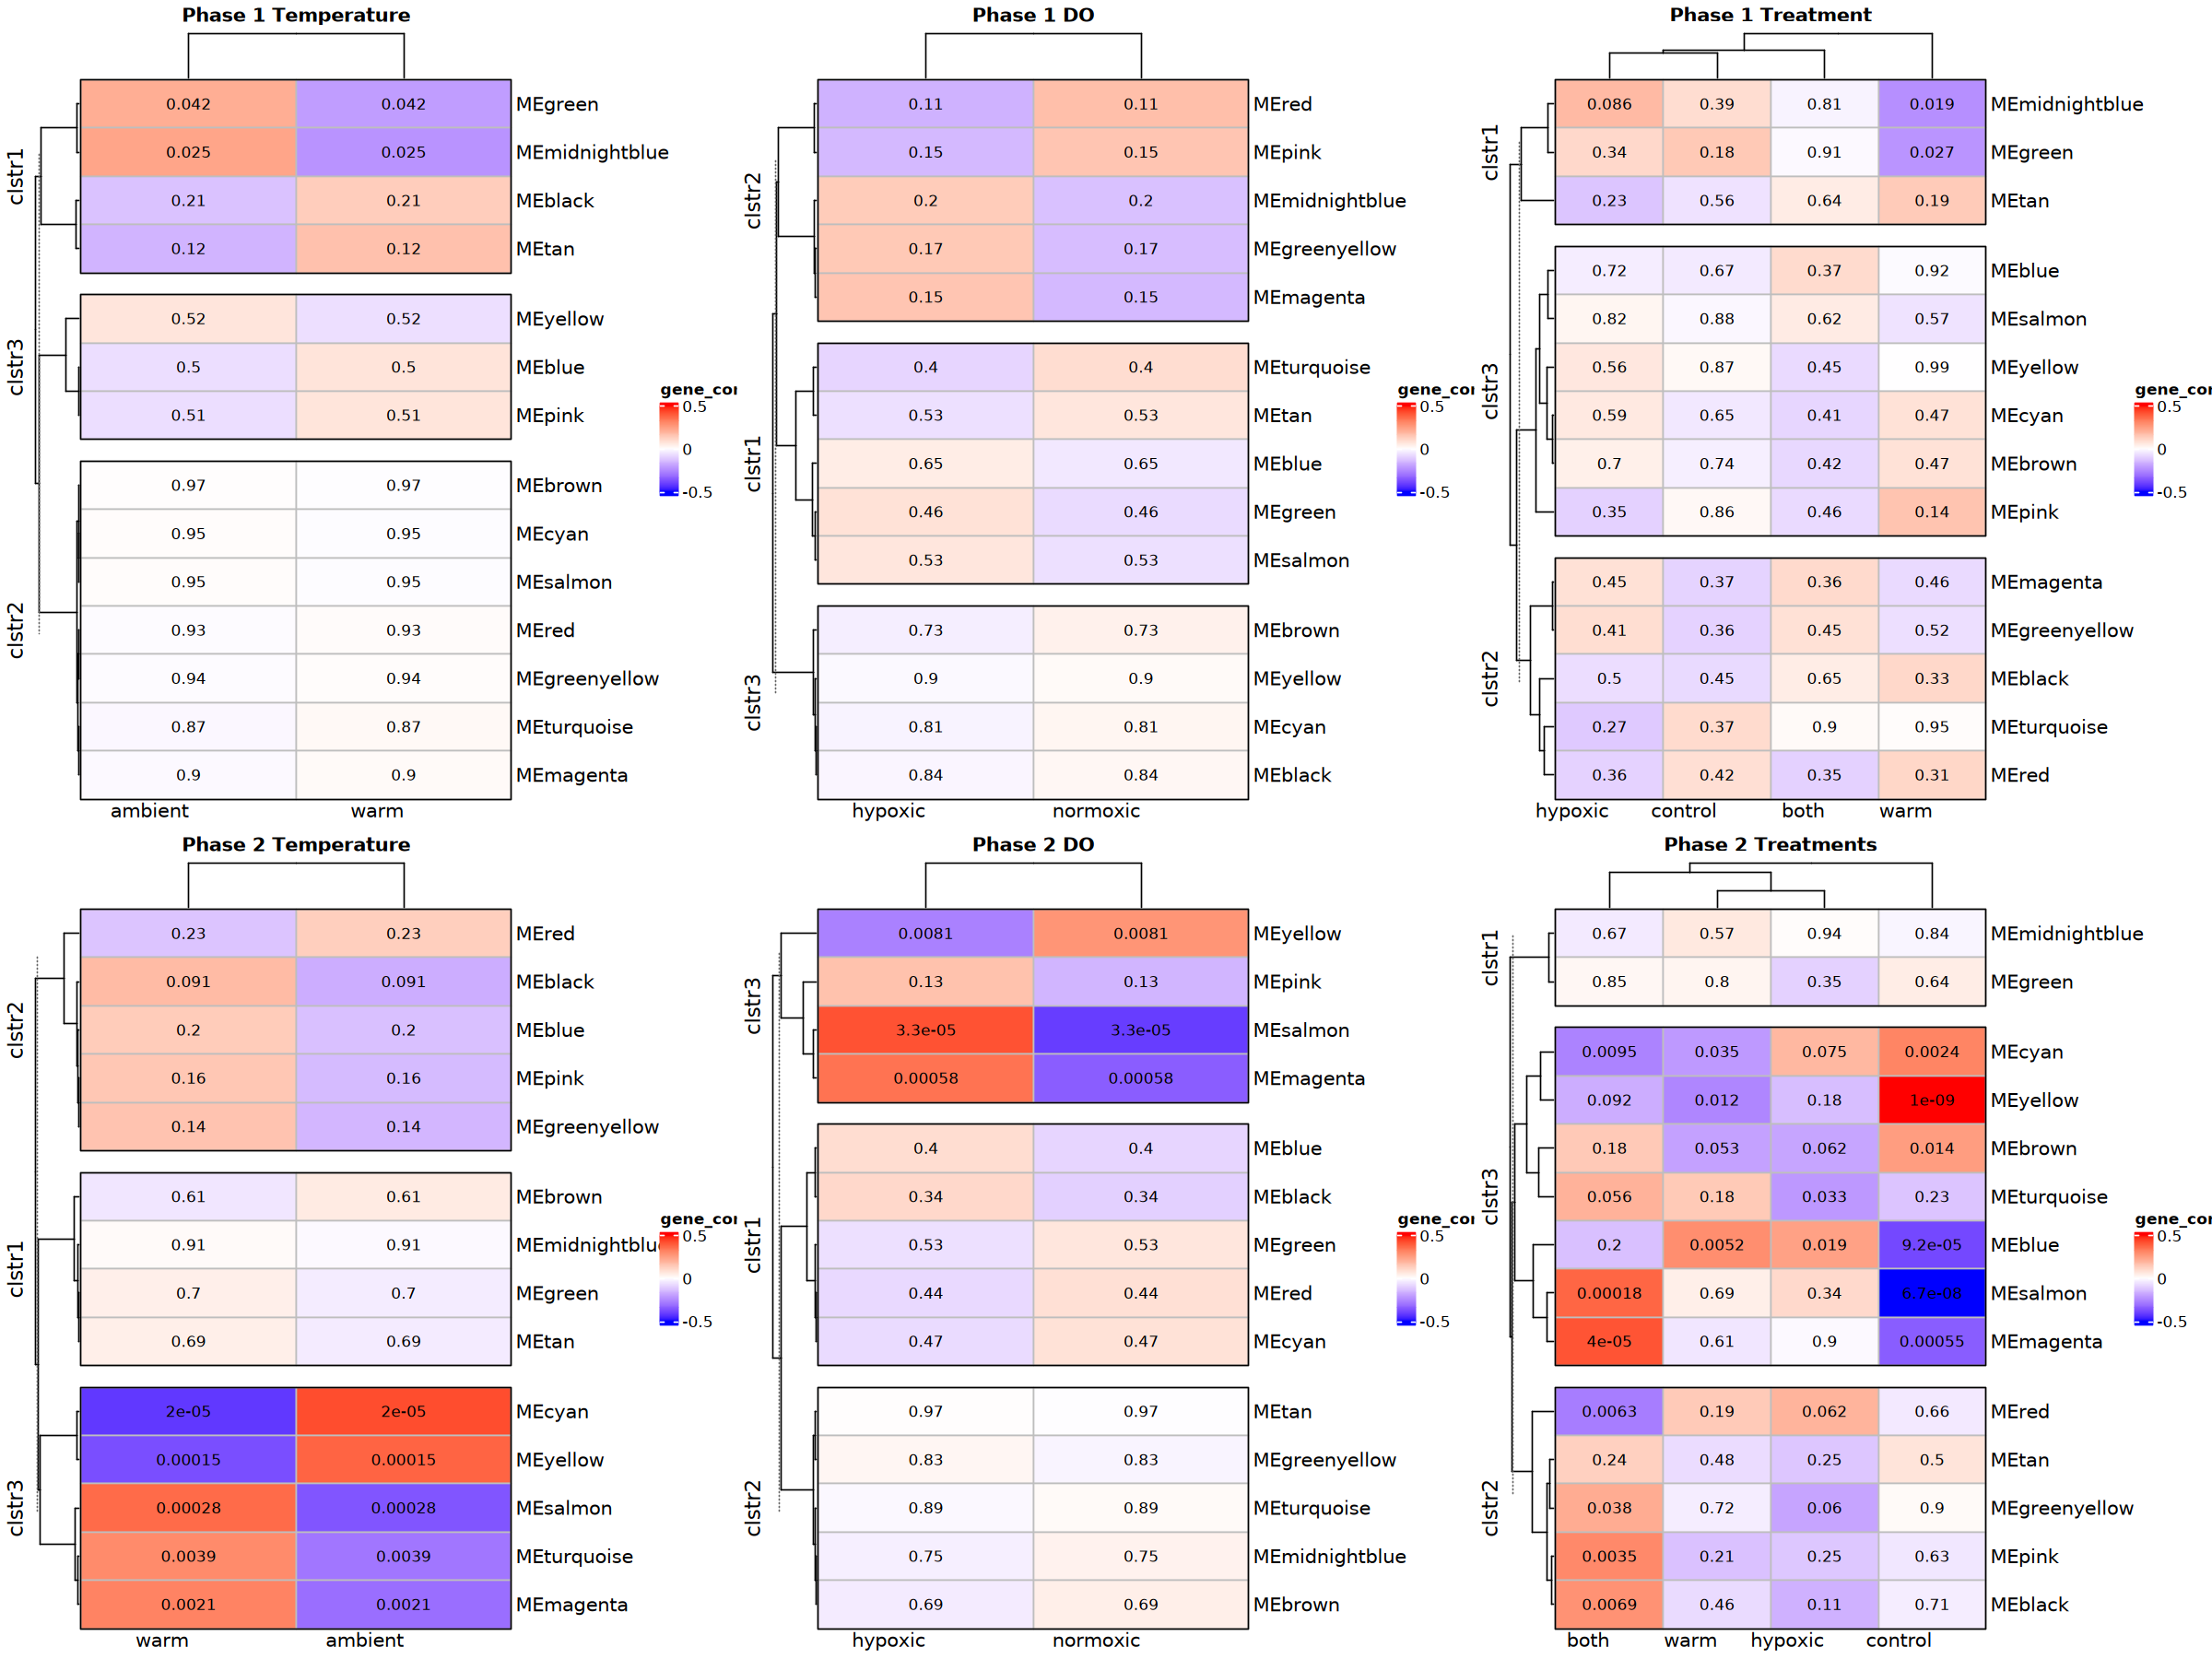

In [69]:
options(repr.plot.width = 20, repr.plot.height = 15)

# 3. Use plot_grid with the new grob objects
all_heatmaps <- plot_grid(p1_temp_g, p1_DO_g, p1_treatment_g, 
          p2_temp_g, p2_DO_g, p2_treatment_g,
          nrow = 2, ncol = 3)

all_heatmaps

some of the axes are not in the same order bc of clustering - I think I'm okay with that since it's informative for the treatments

In [70]:
ggsave(
  filename = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/plots/module_heatmaps_p2.png', 
  plot = all_heatmaps, 
  width = 20,       # Half the width
  height = 15,     # Roughly half the height
  units = "in", 
  dpi = 300         # High resolution for clarity
)

####  Combo of P1 & P2

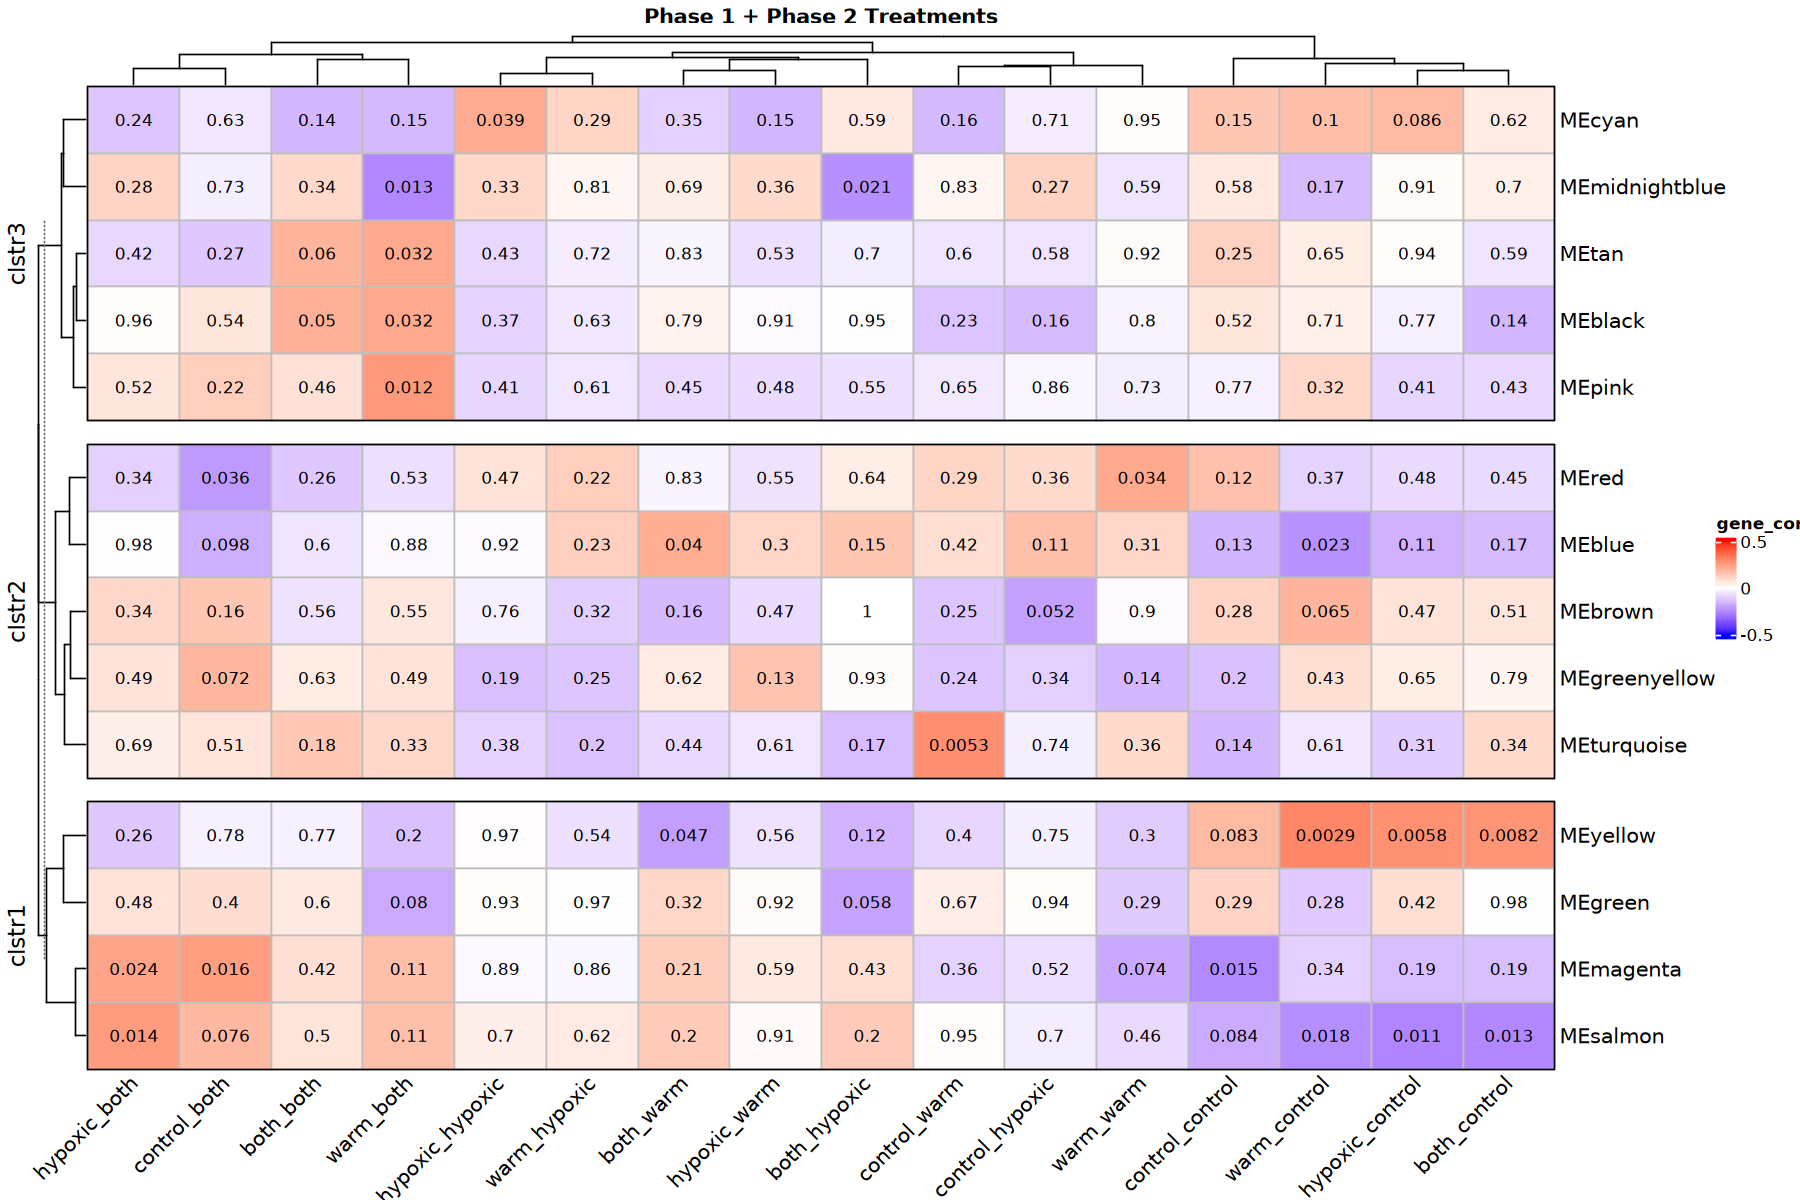

In [71]:
options(repr.plot.width = 15, repr.plot.height = 10)

combo.text <-  as.matrix(signif(moduleTraitPvalue_combo, 4))
# cluster modules based on p-value similarity
pa = cluster::pam(combo.text, k = 3)
col_fun = colorRamp2(c(-0.5, 0, 0.5), c("blue", "white", "red"))

Heatmap(moduleTraitCor_combo, 
        name = "gene_cor", 
        rect_gp = gpar(col = "grey", lwd = 1),
        column_title = "Phase 1 + Phase 2 Treatments", 
        column_title_gp = gpar(fontsize = 12, fontface = "bold"),
        # row_title = "WGCNA modules",
        #row_km = 4, 
        column_names_rot = 45,
        column_km = 1,
        row_split = paste0("clstr", pa$clustering),
        row_gap = unit(5, "mm"),
        column_gap = unit(5, "mm"),
        # grid.text(matrix(textMatrix)),
        # border = TRUE,
        border = TRUE,
        col = col_fun,
        cell_fun = function(j, i, x, y, width, height, fill) {
          grid.text(sprintf("%.2g", combo.text[i, j]), x, y,
          gp = gpar(fontsize = 10))
        })

column clustering = shows similarity of the treatments with similar correlation patterns across modules

## MEs boxplots by treatment group

inspo for this comes from [Gurr's code](https://github.com/SamGurr/Pgenerosa_OA_TagSeq/blob/main/TagSeq/Analysis/Scripts/Day21_WGCNA_all.R) - plotting every module's ME (module eigengene) for each treatment combination - this will allow me to take a closer look at the relationship between modules and phase 1 and 2 treatments

first - need to make sure the sample name mixup from above carries down here

In [72]:
# add missing rep number to sample name
rownames(metaData_merge)[rownames(metaData_merge) == 'C_W5_W52'] <- 'C2_W5_W52'
rownames(dataMeta)[rownames(dataMeta) == 'C_W5_W52'] <- 'C2_W5_W52'

# fix wrong rep number to sample name
rownames(metaData_merge)[rownames(metaData_merge) == 'W2_B2_G04'] <- 'W2_B1_G04'
rownames(dataMeta)[rownames(dataMeta) == 'W2_B2_G04'] <- 'W2_B1_G04'

# update sample column info
metaData_merge$Sample <- rownames(metaData_merge)
dataMeta$Sample <- rownames(dataMeta)

then create df to plot boxplots - want the metadata and module eigengene info in long format

In [73]:
# Create ME table
MEs_df <- as.data.frame(MEs)
MEs_df$Sample <- rownames(MEs_df)

# format metadata and merge with MEs
dataMeta2 <- dataMeta[,1:10]
meta_merge <- merge(dataMeta2, metaData_merge, by = 'Sample')
dim(meta_merge)

# merge MEs and metadata
MEsPlotting <- merge(MEs_df, meta_merge, by = 'Sample')

# Melt to long format
MEsPlotting_melt <- reshape2::melt(
  MEsPlotting,
  id.vars = c("Sample",
              "Phase1_treatment",
              "Phase1_temp",
              "Phase1_DO",
              "Phase1_TankRep",
              "Phase2_treatment",
              "Phase2_temp",
              "Phase2_DO",
              "Phase2_TankRep",
              "combo_trtmt",
              'Actual_shell_growth_mg',
              'Actual_tissue_growth_mg', 
              'Ratio_tissue_shell_mg'
             ),
  variable.name = "Module",
  value.name = "Eigengene"
)

MEsPlotting_melt <- MEsPlotting_melt %>%
filter(!grepl('code', Module)) # remove treatment code rows

head(MEsPlotting_melt)

[1] 93 19

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo_trtmt,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,Module,Eigengene
,<chr>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<chr>,<dbl>,<dbl>,<chr>,<fct>,<dbl>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,210.2755,120.72448,0.574125224,MEgreen,-0.07267705
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,315.8883,85.61170,0.271018901,MEgreen,0.11259458
3,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both_both,114.3215,44.47852,0.389065292,MEgreen,-0.08984971
4,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control,164.9903,55.10972,0.33401798,MEgreen,0.10140997
5,B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4,both_both,197.9250,116.17500,0.586964759,MEgreen,0.09981873
6,B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3,both_control,316.0466,241.35336,0.763663743,MEgreen,0.13421227


In [74]:
# save metadata in case I skip code above
# write.csv(MEsPlotting_melt[,1:13], '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/p2.wgcna_metadata.csv')

make boxplot!

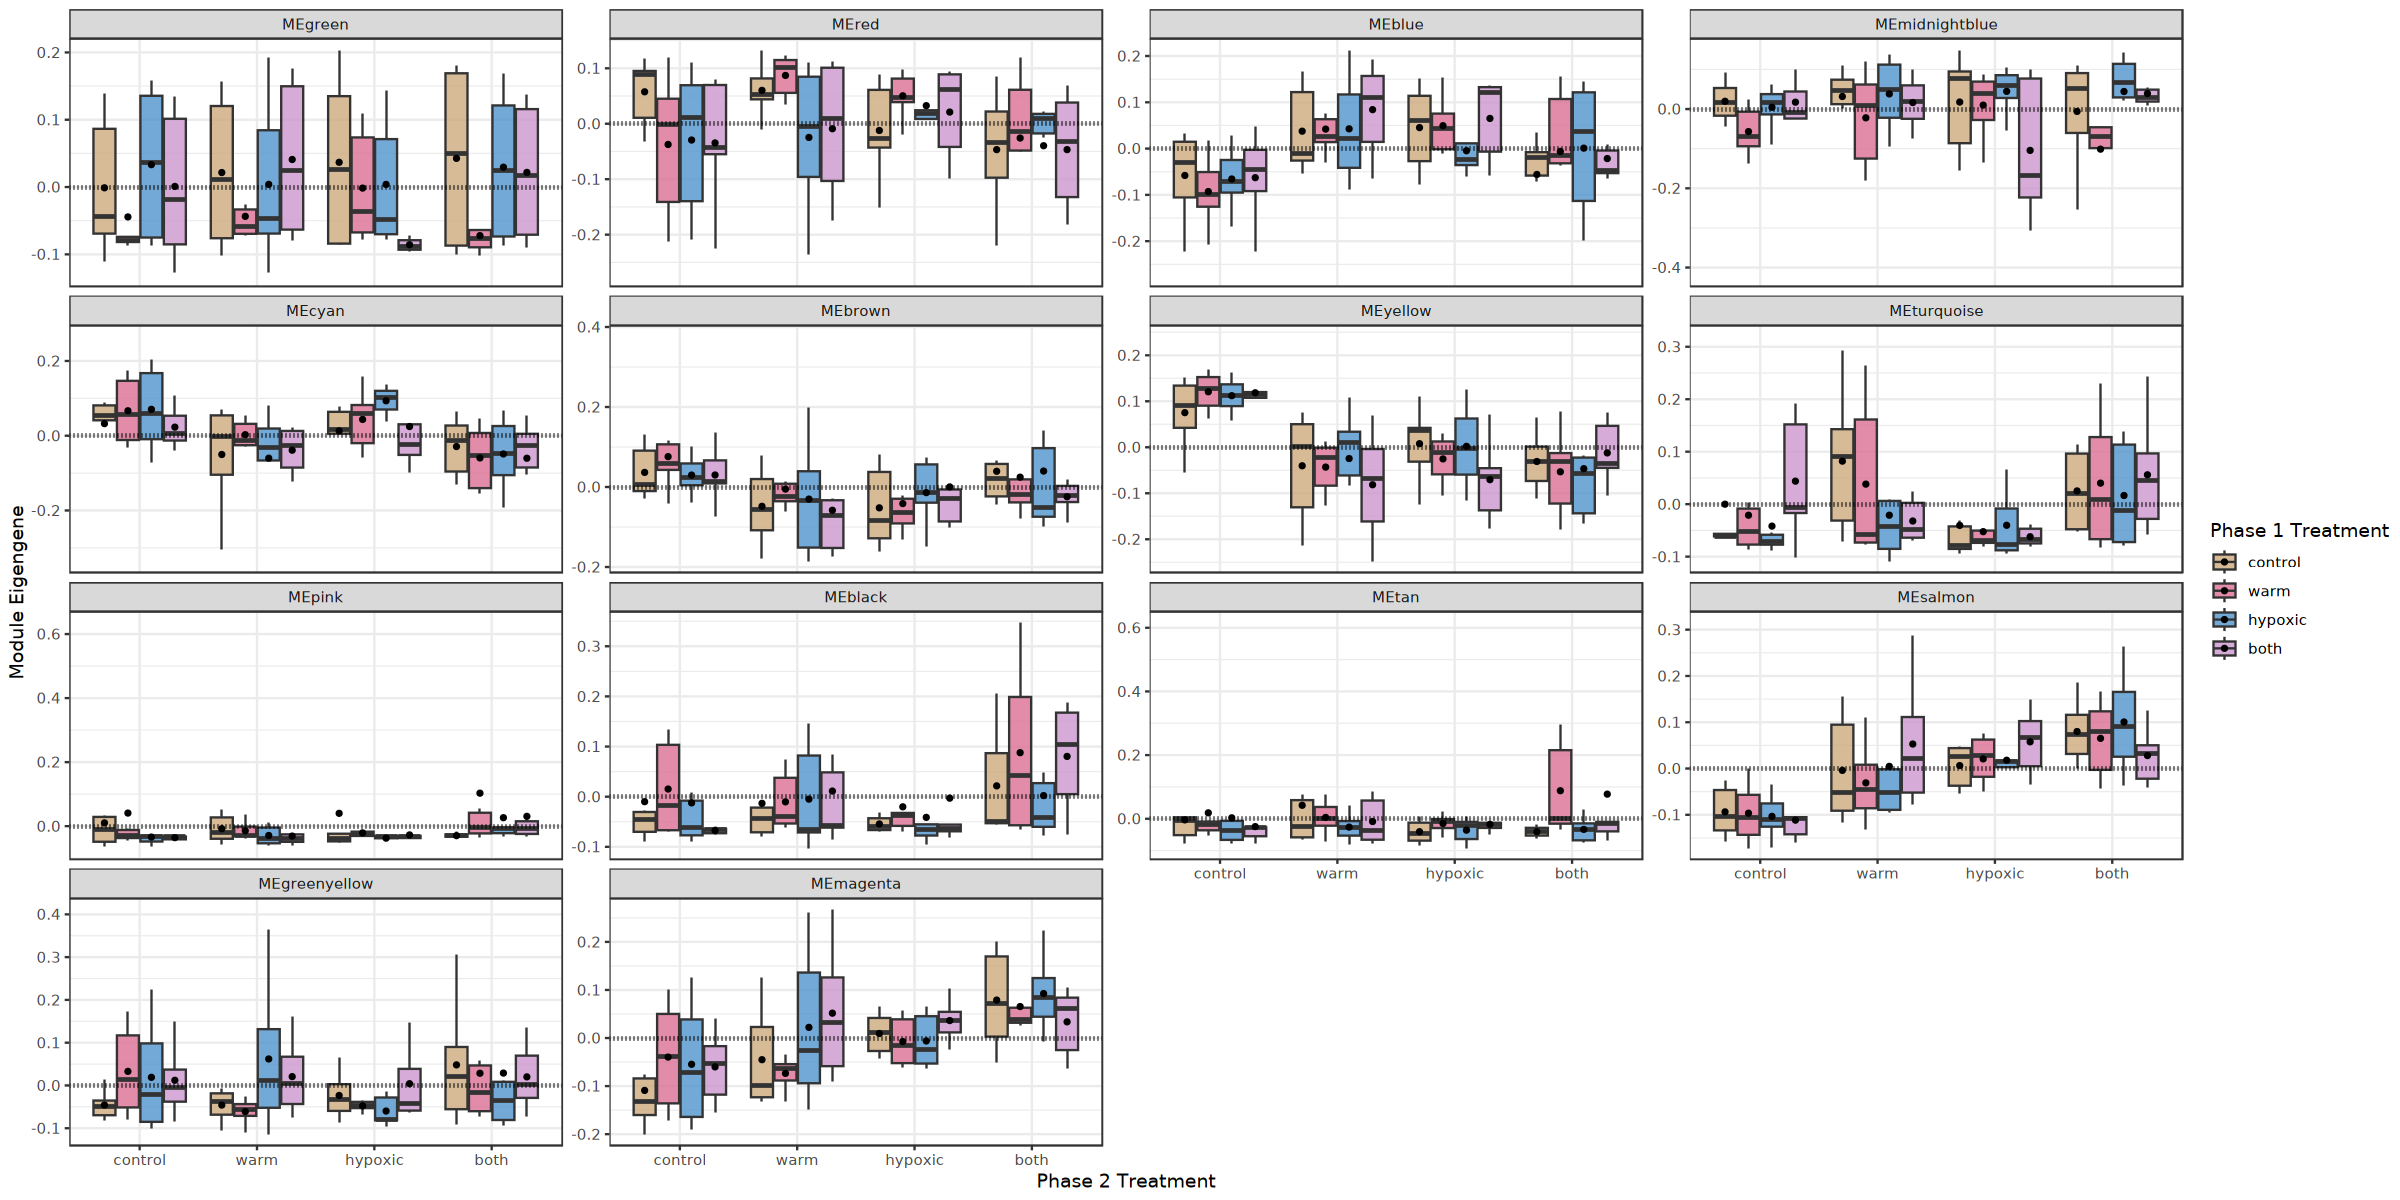

In [75]:
options(repr.plot.width = 20, repr.plot.hieght = 20)

MEs_boxplot <- ggplot(MEsPlotting_melt,
       aes(x = Phase2_treatment,
           y = Eigengene,
           fill = factor(Phase1_treatment))) +
  
  geom_boxplot(position = position_dodge(0.8),
               outlier.shape = NA,
               alpha = 0.8) +

scale_fill_manual(values = c("hypoxic" = "steelblue3", 
                             "warm" = "palevioletred", 
                             "control" = "burlywood3", 
                             "both" = "plum3")) +
  
  stat_summary(fun = mean,
               geom = "point",
               color = "black",
               position = position_dodge(0.8),
               size = 1) +
  
  geom_hline(yintercept = 0,
             linetype = "dotted",
             linewidth = 1) +
  
  ylab("Module Eigengene") +
labs(fill = 'Phase 1 Treatment', x = 'Phase 2 Treatment') +
  theme_bw() +
  facet_wrap(~ Module, scales = "free_y")

MEs_boxplot

x-axis: module eigengene - representative gene expression profile for that module

dotted line denotes no expression, pos = higher expr and neg = lower expr

In [76]:
ggsave(
  filename = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/plots/MEs_boxplots_p2.png', 
  plot = MEs_boxplot, 
  width = 10,       # Half the width
  height = 8.5,     # Roughly half the height
  units = "in", 
  dpi = 300         # High resolution for clarity
)

## ANOVA on MEs

In [77]:
head(meta_merge)

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo_trtmt,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,P1_trtmt_code,P2_trtmt_code,P1_temp_code,P2_temp_code,P1_DO_code,P2_DO_code
,<chr>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both,210.2755,120.72448,0.574125224,4,4,2,2,2,2
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm,315.8883,85.61170,0.271018901,4,2,2,2,2,1
3,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both_both,114.3215,44.47852,0.389065292,4,4,2,2,2,2
4,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control,164.9903,55.10972,0.33401798,4,1,2,1,2,1
5,B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4,both_both,197.9250,116.17500,0.586964759,4,4,2,2,2,2
6,B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3,both_control,316.0466,241.35336,0.763663743,4,1,2,1,2,1


In [78]:
# Create a storage list or data frame for results
anova_results <- list()

for(module in colnames(MEs)) {
  # Create a temporary formula: Module_Eigengene ~ Phase1 * Phase2
  # The '*' denotes Interaction (Phase1 + Phase2 + Phase1:Phase2)
  fit <- aov(MEs[[module]] ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta_merge)
  
  # Summarize and save
  anova_results[[module]] <- summary(fit)
}

In [79]:
head(anova_results)

$MEgreen
                                            Df Sum Sq Mean Sq F value Pr(>F)  
Phase1_temp                                  1 0.0446 0.04459   3.978 0.0496 *
Phase1_DO                                    1 0.0056 0.00560   0.499 0.4820  
Phase2_temp                                  1 0.0017 0.00167   0.149 0.7002  
Phase2_DO                                    1 0.0039 0.00393   0.351 0.5555  
Phase1_temp:Phase1_DO                        1 0.0118 0.01175   1.048 0.3091  
Phase1_temp:Phase2_temp                      1 0.0016 0.00162   0.145 0.7046  
Phase1_DO:Phase2_temp                        1 0.0150 0.01501   1.339 0.2508  
Phase1_temp:Phase2_DO                        1 0.0010 0.00101   0.090 0.7645  
Phase1_DO:Phase2_DO                          1 0.0031 0.00314   0.280 0.5981  
Phase2_temp:Phase2_DO                        1 0.0040 0.00402   0.359 0.5509  
Phase1_temp:Phase1_DO:Phase2_temp            1 0.0185 0.01848   1.649 0.2029  
Phase1_temp:Phase1_DO:Phase2_DO            

#### post-hoc Tukey test

In [80]:
# Run Tukey on a specific module of interest
#specific_fit <- aov(MEs[MEblue] ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta_merge)
specific_fit <- aov(MEs$MEsalmon ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta_merge)
tukey_out <- TukeyHSD(specific_fit)

# Look specifically at the interaction comparisons
head(tukey_out)

,diff,lwr,upr,p adj
warm-ambient,-0.001403388,-0.03844946,0.03564269,0.9400657
,diff,lwr,upr,p adj
hypoxic-normoxic,0.01363117,-0.02343205,0.05069439,0.4661804
,diff,lwr,upr,p adj
warm-ambient,0.07606058,0.03899736,0.1131238,0.0001065255
,diff,lwr,upr,p adj
hypoxic-normoxic,0.08561952,0.04857345,0.1226656,1.619227e-05
,diff,lwr,upr,p adj
warm:normoxic-ambient:normoxic,-0.005761962,-0.07376239,0.06223846,0.9960806
ambient:hypoxic-ambient:normoxic,0.009024898,-0.05971069,0.07776048,0.9858035


In [81]:
# Extract p-values for different biological questions
anova_summary <- lapply(colnames(MEs), function(mod) {
  fit <- aov(MEs[[mod]] ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta_merge)
  pvals <- summary(fit)[[1]][["Pr(>F)"]]
  names(pvals) <- rownames(summary(fit)[[1]])
  return(pvals)
})

# Convert to a clean data frame
anova_df <- as.data.frame(do.call(rbind, anova_summary))
rownames(anova_df) <- colnames(MEs)

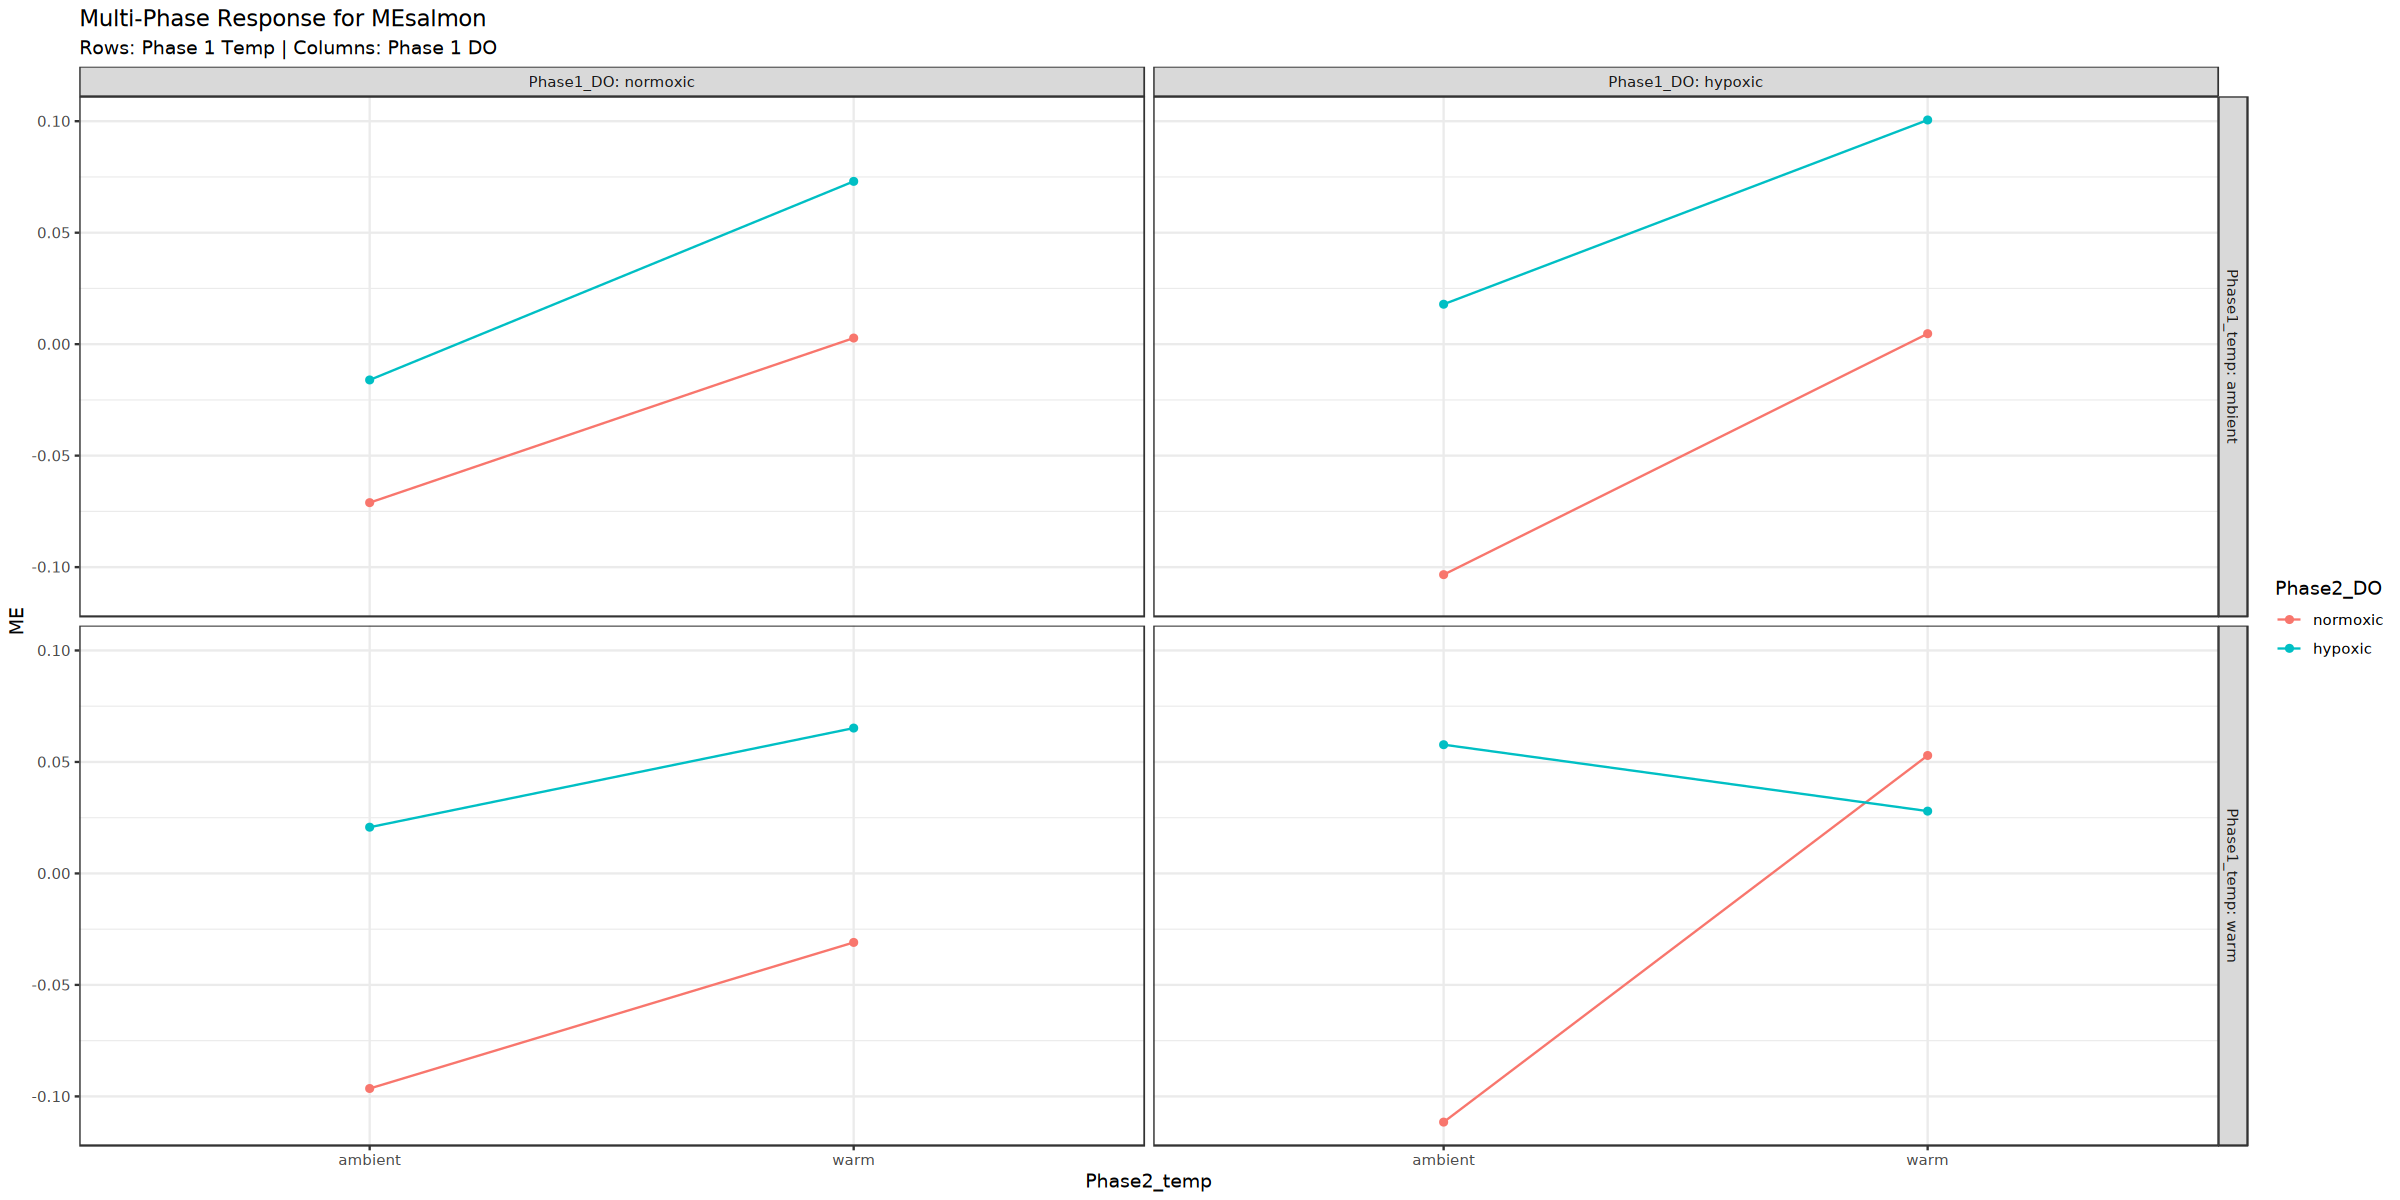

In [82]:
# Choose a module significant for the interaction
mod_to_plot <- "MEsalmon" 

plot_data <- cbind(meta_merge, ME = MEs[[mod_to_plot]])

ggplot(plot_data, aes(x = Phase2_temp, y = ME, color = Phase2_DO, group = Phase2_DO)) +
  stat_summary(fun = mean, geom = "line") +
  stat_summary(fun = mean, geom = "point") +
  # This creates a grid: Phase 1 Temp vs Phase 1 DO
  facet_grid(Phase1_temp ~ Phase1_DO, labeller = label_both) + 
  theme_bw() +
  labs(title = paste("Multi-Phase Response for", mod_to_plot),
       subtitle = "Rows: Phase 1 Temp | Columns: Phase 1 DO")

so this is just showing how module eigengene changes in phase 2 treatments (all of the points within a box have the same phase 1 treatment) - the blue lines are phase 2 hypoxic and red are normoxic - so appears that phase 2 hypoxic conditions, regardless of phase 1, have higher eigengenes (in the salmon module) than normoxic samples - when in phase 2 warm temps, this pattern remains, but slightly increases, *except* for when oysters experience phase 1 both (bottom right panel) - we actually see an interaction, where BW has higher eigengene expression than BB

I think there are better, more logical setups for this type of plot though

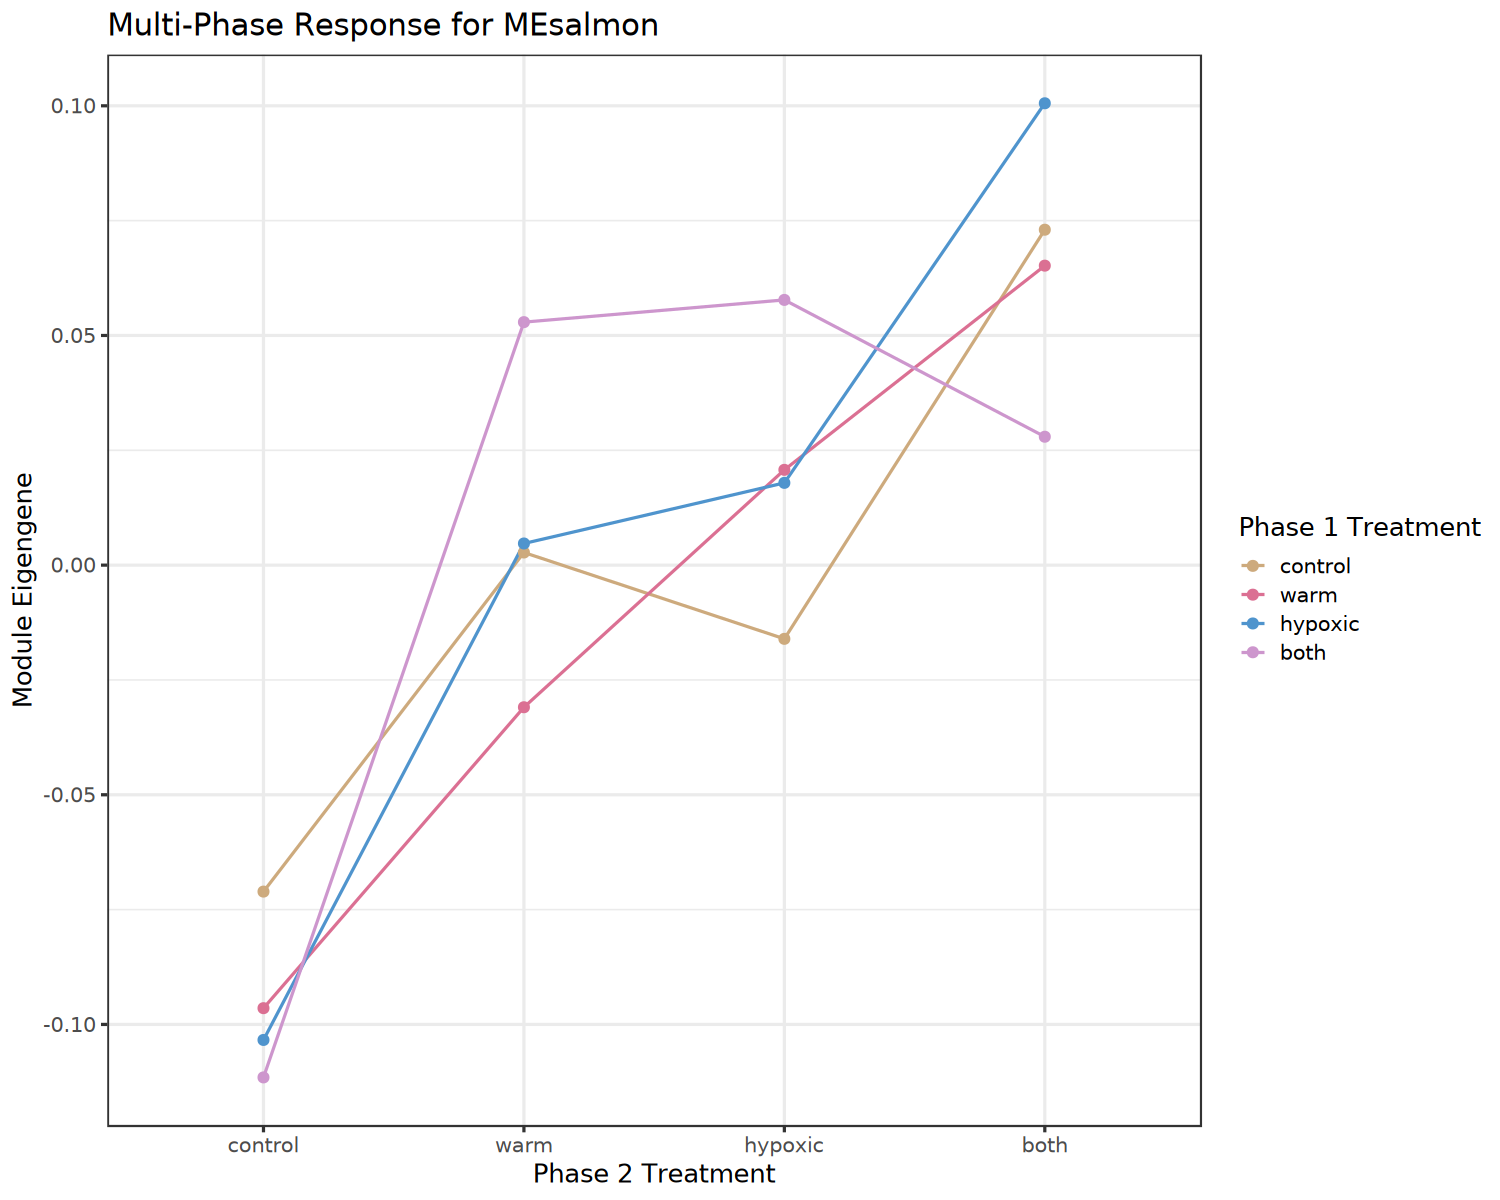

In [83]:
options(repr.plot.width = 12.5, repr.plot.height = 10)
# Choose a module significant for the interaction
mod_to_plot <- "MEsalmon" 

plot_data <- cbind(meta_merge, ME = MEs[[mod_to_plot]])

ggplot(plot_data, aes(x = Phase2_treatment, y = ME, color = Phase1_treatment, group = Phase1_treatment)) +
  stat_summary(fun = mean, geom = "line") +
  stat_summary(fun = mean, geom = "point") +
  # This creates a grid: Phase 1 Temp vs Phase 1 DO
 # facet_grid(Phase1_temp ~ Phase1_DO, labeller = label_both) + 
scale_color_manual(values = c("hypoxic" = "steelblue3", 
                             "warm" = "palevioletred", 
                             "control" = "burlywood3", 
                             "both" = "plum3")) +
  theme_bw(base_size = 15) +
  labs(title = paste("Multi-Phase Response for", mod_to_plot),
      x = 'Phase 2 Treatment',
      y = 'Module Eigengene',
      color = 'Phase 1 Treatment')

this is really just another way to look at the ME boxplots

for MEsalmon:
- all MEs are larger in phase 2 stressors than control
- phase 1 both seems to have higher ME when in phase 2 hypoxia or warm, but not control or both
- from heatmap - WC, HC, and BC had a sig neg. corr and HB has sig. pos. corr - can see that here

## Identify hub genes
hub genes = gene with the most connectivity within its module 

In [84]:
hubGenes <- chooseTopHubInEachModule(dataExpr, # vst expr. matrix
                         mergedColors_sign, # from dendogram above
                         omitColors = "grey", # grey module = genes not assigned to any module
                         power = 5, 
                         type = "signed")

# make into df, assign modules in column
hubGenes.df <- as.data.frame(hubGenes) %>%
mutate(module = rownames(.))
# remove row names
rownames(hubGenes.df) <- NULL

hubGenes.df

hubGenes,module
<chr>,<chr>
LOC111121348,black
LOC111108426,blue
LOC111133766,brown
LOC111136057,cyan
LOC111102039,green
LOC111129175,greenyellow
LOC111119101,magenta
LOC111130108,midnightblue
LOC111104655,pink


from the heatmap and boxplots above, the modules I'm most interested is:
- **green**: p1_temp
    - hub gene: *LOC111102039* - E3 ubiquitin-protein ligase, but withdrawn by NCBI Jan 2026
- **yellow**: p2_trtmt, p2_DO, p2_temp, tissue and shell growth
    - hub gene: *LOC111135316* - enoyl-CoA delta isomerase 2-like
- **salmon**: p2_trtmt, p2_DO, p2_temp, tissue and shell growth
    - hub gene: *LOC111119855* - forkhead box protein K1-like
- **magenta**: p2_trtmt, p2_DO, p2_temp, shell growth
    - hub gene: *LOC111119101* - putative E3 ubiquitin-protein ligase UNKL

## Gene significance (GS) and module membership (MM)
both are critical metrics for identifying hub genes within modules that are associated with specific treatment/traits
- GS = correlates gene expression with treatment/trait
- MM = how well a gene belongs to a module

basically select a module of interest and validate with GS and MM - combine GS and MM to find genes that are highly connected *and* strongly associated with the treatment/trait

In [85]:
modNames <- substring(names(MEs), 3)
modNames

[1] "green"        "red"          "blue"         "midnightblue" "cyan"        
 [6] "brown"        "yellow"       "turquoise"    "pink"         "black"       
[11] "tan"          "salmon"       "greenyellow"  "magenta"

#### module membership
MM is the same across all treatments

In [86]:
geneModuleMembership = as.data.frame(cor(dataExpr, MEs, use = "p"))
MMPvalue = as.data.frame(corPvalueStudent(as.matrix(geneModuleMembership), nSamples))

names(geneModuleMembership) = paste("MM", modNames, sep="")
names(MMPvalue) = paste("p.MM", modNames, sep="")

In [87]:
head(geneModuleMembership)

,MMgreen,MMred,MMblue,MMmidnightblue,MMcyan,MMbrown,MMyellow,MMturquoise,MMpink,MMblack,MMtan,MMsalmon,MMgreenyellow,MMmagenta
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111126949,-0.29131501,-0.41227355,0.11966094,0.10531261,-0.42733147,-0.12748182,-0.118591219,0.07454674,0.16785589,0.35333236,0.30953368,0.210578762,0.47017151,0.52444279
LOC111120752,-0.11377871,0.17704776,-0.54304750,-0.37744924,0.41867198,0.66129985,0.397522474,0.05965289,0.09464446,-0.04621819,0.10549091,-0.289872345,-0.20700554,-0.40432308
LOC111105691,0.07747739,-0.07983363,-0.03811632,-0.01667698,0.02404631,0.05422716,0.007444635,-0.02336339,0.02232239,0.07532960,0.10503673,0.038893059,0.05409074,0.05947199
LOC111113860,0.07821217,0.02207649,-0.12657345,0.08711989,0.09883905,0.03153799,0.282311092,-0.02388304,0.03012267,0.03335159,-0.06064519,-0.257005221,-0.11392521,-0.25493077
LOC111109550,-0.25482209,0.08180723,0.03327907,-0.06078129,-0.03377160,0.08119176,-0.075317074,-0.04866860,0.06626850,0.27558623,0.25754052,-0.019358840,0.01796356,-0.03180158
LOC111109753,-0.16215593,-0.06347819,-0.03184050,-0.17004572,-0.14010436,-0.07522357,-0.082157545,0.47689288,0.04774739,0.23515441,0.43133343,0.009847284,0.03141847,0.01523514


#### gene significance
calculated for each treatment combination

In [88]:
# List all trait sets you want to process
trait_sets <- list(
  Combo_treatments = combo.treatments[-1],  # exclude first column 
  phase1_temp = phase1.temp[-1],
  phase1_DO = phase1.DO[-1],
    phase2_temp = phase2.temp[-1],
    phase2_DO = phase2.DO[-1],
    phase1_treatment = phase1.treatments[-1],
    phase2_treatment = phase2.treatments[-1]
)

# Initialize lists to store results
geneTraitSignificance_all <- list()
GSPvalue_all <- list()

# Loop over each trait set
for(set_name in names(trait_sets)){
  traits_df <- trait_sets[[set_name]]
  
  # Get trait names
  trait_names <- colnames(traits_df)
  
  # Initialize lists for this set
  gs_list <- list()
  gs_p_list <- list()
  
  for(trt in trait_names){
    trt_df <- as.data.frame(traits_df[[trt]])
    names(trt_df) <- trt
    
    # Compute gene-trait significance and p-values
    gs <- as.data.frame(cor(dataExpr, trt_df, use = "p"))
    gs_p <- as.data.frame(corPvalueStudent(as.matrix(gs), nSamples))
    
    # Rename columns
    names(gs) <- paste0("GS.", trt)
    names(gs_p) <- paste0("p.GS.", trt)
    
    # Store in lists
    gs_list[[trt]] <- gs
    gs_p_list[[trt]] <- gs_p
  }
  
  # Combine into data frames for this set
  geneTraitSignificance_all[[set_name]] <- do.call(cbind, gs_list)
  GSPvalue_all[[set_name]] <- do.call(cbind, gs_p_list)
}

# Optional: combine all sets into one big data frame each
geneTraitSignificance_df <- do.call(cbind, geneTraitSignificance_all)
GSPvalue_df <- do.call(cbind, GSPvalue_all)

In [89]:
head(geneTraitSignificance_df) 
head(GSPvalue_df)

,Combo_treatments.GS.both_both,Combo_treatments.GS.both_warm,Combo_treatments.GS.both_control,Combo_treatments.GS.both_hypoxic,Combo_treatments.GS.control_control,Combo_treatments.GS.control_hypoxic,Combo_treatments.GS.control_both,Combo_treatments.GS.control_warm,Combo_treatments.GS.hypoxic_both,Combo_treatments.GS.hypoxic_control,⋯,phase2_DO.GS.hypoxic,phase2_DO.GS.normoxic,phase1_treatment.GS.both,phase1_treatment.GS.control,phase1_treatment.GS.hypoxic,phase1_treatment.GS.warm,phase2_treatment.GS.both,phase2_treatment.GS.warm,phase2_treatment.GS.control,phase2_treatment.GS.hypoxic
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111126949,0.134535297,0.08106639,-0.01984269,-0.125567373,-0.10214362,0.05743467,0.07744699,-0.002278528,0.12191108,-0.07840426,⋯,0.05012042,-0.05012042,0.04746133,0.017101260,-0.008029922,-0.0552782665,0.291697813,0.105025629,-0.16459583,-0.241380626
LOC111120752,-0.097786103,-0.21956669,0.03168394,0.018923029,0.27477457,-0.10304631,-0.09459133,-0.033011911,0.06183621,0.11424134,⋯,-0.16086092,0.16086092,-0.15659878,0.024773649,0.092643875,0.0359675808,-0.105704375,-0.092536133,0.28025715,-0.080412346
LOC111105691,0.126973620,-0.06603745,0.05948199,0.213544037,-0.02228376,-0.13581772,0.29495394,-0.128277402,-0.04301547,-0.07651353,⋯,0.16779073,-0.16779073,0.18013370,0.004814397,-0.245404509,0.0622111868,0.200283176,-0.136605864,-0.05589514,-0.008817879
LOC111113860,0.003623701,0.01218615,0.21263364,-0.157464093,0.05464115,0.03189497,-0.03010524,0.022315762,-0.21582543,0.13700159,⋯,-0.25046864,0.25046864,0.03842045,0.044211686,-0.084110272,0.0014080723,-0.177094732,0.001825044,0.28839641,-0.112327627
LOC111109550,-0.042907100,-0.07502565,-0.10499058,-0.009942346,0.03629926,-0.13884252,-0.05268374,-0.067752474,-0.11075267,0.18718037,⋯,-0.12712241,0.12712241,-0.12917569,-0.125190094,-0.070194980,0.3198591944,0.005332106,0.100107290,0.04578430,-0.155048128
LOC111109753,0.197258378,0.01029226,0.10515980,-0.099310563,-0.05652168,-0.09445992,-0.04151125,0.271375884,-0.09442279,-0.05215162,⋯,-0.08821365,0.08821365,0.12308720,0.044288267,-0.166682588,0.0005202304,0.067747554,0.137403793,-0.03712939,-0.173538535


,Combo_treatments.p.GS.both_both,Combo_treatments.p.GS.both_warm,Combo_treatments.p.GS.both_control,Combo_treatments.p.GS.both_hypoxic,Combo_treatments.p.GS.control_control,Combo_treatments.p.GS.control_hypoxic,Combo_treatments.p.GS.control_both,Combo_treatments.p.GS.control_warm,Combo_treatments.p.GS.hypoxic_both,Combo_treatments.p.GS.hypoxic_control,⋯,phase2_DO.p.GS.hypoxic,phase2_DO.p.GS.normoxic,phase1_treatment.p.GS.both,phase1_treatment.p.GS.control,phase1_treatment.p.GS.hypoxic,phase1_treatment.p.GS.warm,phase2_treatment.p.GS.both,phase2_treatment.p.GS.warm,phase2_treatment.p.GS.control,phase2_treatment.p.GS.hypoxic
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111126949,0.19854141,0.43983301,0.85026017,0.23040979,0.32992440,0.5844883,0.460587512,0.982706270,0.24437726,0.45504648,⋯,0.63328611,0.63328611,0.65143836,0.8707547,0.93910751,0.598695656,0.004554529,0.3163888,0.114885206,0.01975933
LOC111120752,0.35107905,0.03445851,0.76303926,0.85712501,0.00768726,0.3256457,0.367113770,0.753418270,0.55597826,0.27554677,⋯,0.12347368,0.12347368,0.13386735,0.8136551,0.37710478,0.732141389,0.313253921,0.3776623,0.006510356,0.44354388
LOC111105691,0.22518935,0.52940404,0.57114416,0.03985356,0.83209404,0.1942569,0.004103337,0.220424014,0.68224219,0.46602624,⋯,0.10791173,0.10791173,0.08402124,0.9634691,0.01774167,0.553580655,0.054243068,0.1916572,0.594615673,0.93314543
LOC111113860,0.97249983,0.90770500,0.04072737,0.13170509,0.60292257,0.7615080,0.774523661,0.831856421,0.03773234,0.19036137,⋯,0.01545676,0.01545676,0.71463567,0.6739000,0.42279503,0.989312408,0.089471428,0.9861478,0.005056596,0.28372241
LOC111109550,0.68299987,0.47476726,0.31655122,0.92464361,0.72976596,0.1844166,0.615990645,0.518741546,0.29057078,0.07239858,⋯,0.22464191,0.22464191,0.21718242,0.2318247,0.50374688,0.001775433,0.959543969,0.3397072,0.662992812,0.13780956
LOC111109753,0.05806197,0.92199967,0.31576752,0.34358400,0.59048464,0.3677828,0.692786716,0.008507588,0.36797198,0.61956420,⋯,0.40043925,0.40043925,0.23982200,0.6733673,0.11029213,0.996051232,0.518771975,0.1890509,0.723832031,0.09620065


In [90]:
colnames(geneTraitSignificance_df)
colnames(GSPvalue_df)

[1] "Combo_treatments.GS.both_both"       "Combo_treatments.GS.both_warm"      
 [3] "Combo_treatments.GS.both_control"    "Combo_treatments.GS.both_hypoxic"   
 [5] "Combo_treatments.GS.control_control" "Combo_treatments.GS.control_hypoxic"
 [7] "Combo_treatments.GS.control_both"    "Combo_treatments.GS.control_warm"   
 [9] "Combo_treatments.GS.hypoxic_both"    "Combo_treatments.GS.hypoxic_control"
[11] "Combo_treatments.GS.hypoxic_warm"    "Combo_treatments.GS.hypoxic_hypoxic"
[13] "Combo_treatments.GS.warm_control"    "Combo_treatments.GS.warm_hypoxic"   
[15] "Combo_treatments.GS.warm_warm"       "Combo_treatments.GS.warm_both"      
[17] "phase1_temp.GS.warm"                 "phase1_temp.GS.ambient"             
[19] "phase1_DO.GS.hypoxic"                "phase1_DO.GS.normoxic"              
[21] "phase2_temp.GS.warm"                 "phase2_temp.GS.ambient"             
[23] "phase2_DO.GS.hypoxic"                "phase2_DO.GS.normoxic"              
[25] "phase1_treatment.GS.both"            "phase1_treatment.GS.control"        
[27] "phase1_treatment.GS.hypoxic"         "phase1_treatment.GS.warm"           
[29] "phase2_treatment.GS.both"            "phase2_treatment.GS.warm"           
[31] "phase2_treatment.GS.control"         "phase2_treatment.GS.hypoxic"

[1] "Combo_treatments.p.GS.both_both"      
 [2] "Combo_treatments.p.GS.both_warm"      
 [3] "Combo_treatments.p.GS.both_control"   
 [4] "Combo_treatments.p.GS.both_hypoxic"   
 [5] "Combo_treatments.p.GS.control_control"
 [6] "Combo_treatments.p.GS.control_hypoxic"
 [7] "Combo_treatments.p.GS.control_both"   
 [8] "Combo_treatments.p.GS.control_warm"   
 [9] "Combo_treatments.p.GS.hypoxic_both"   
[10] "Combo_treatments.p.GS.hypoxic_control"
[11] "Combo_treatments.p.GS.hypoxic_warm"   
[12] "Combo_treatments.p.GS.hypoxic_hypoxic"
[13] "Combo_treatments.p.GS.warm_control"   
[14] "Combo_treatments.p.GS.warm_hypoxic"   
[15] "Combo_treatments.p.GS.warm_warm"      
[16] "Combo_treatments.p.GS.warm_both"      
[17] "phase1_temp.p.GS.warm"                
[18] "phase1_temp.p.GS.ambient"             
[19] "phase1_DO.p.GS.hypoxic"               
[20] "phase1_DO.p.GS.normoxic"              
[21] "phase2_temp.p.GS.warm"                
[22] "phase2_temp.p.GS.ambient"             
[23] "phase2_DO.p.GS.hypoxic"               
[24] "phase2_DO.p.GS.normoxic"              
[25] "phase1_treatment.p.GS.both"           
[26] "phase1_treatment.p.GS.control"        
[27] "phase1_treatment.p.GS.hypoxic"        
[28] "phase1_treatment.p.GS.warm"           
[29] "phase2_treatment.p.GS.both"           
[30] "phase2_treatment.p.GS.warm"           
[31] "phase2_treatment.p.GS.control"        
[32] "phase2_treatment.p.GS.hypoxic"

In [91]:
annot <- read.csv('//work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ref_files/annotations/geneGO.txt', sep = '\t')
colnames(annot)[1] <- 'Gene'
colnames(annot)[2] <- 'GO.terms'
head(annot)

,Gene,GO.terms
,<chr>,<chr>
1,LOC111126949,GO:0005042; GO:0005737; GO:0008233; GO:0016020; GO:0043123; GO:0046330
2,LOC111112434,GO:0000981; GO:0003700; GO:0005634; GO:0016607; GO:0043565; GO:0045944
3,LOC111120752,GO:0004750; GO:0005829; GO:0005975; GO:0006098; GO:0009052; GO:0042802; GO:0042803; GO:0046872; GO:0070062
4,LOC111105685,GO:0003682; GO:0004518; GO:0005634; GO:0035098; GO:0035102; GO:0040029; GO:0046872
5,LOC111113860,GO:0004062; GO:0005737; GO:0006068; GO:0006805; GO:0008146; GO:0009812; GO:0030855; GO:0042403; GO:0050427; GO:0051923
6,LOC111109550,GO:0004062; GO:0005737; GO:0005764; GO:0008146; GO:0051923


In [92]:
# 1. Create a data frame for gene information
# Ensure the names of the vector match your gene names
gene_info <- data.frame(
  Gene = colnames(dataExpr),
  ModuleColor = mergedColors_sign
)

# 2. Bind it with  MM and GS dataframes
# (Assuming these have genes as row names in the same order)
final_results <- cbind(gene_info, geneTraitSignificance_df,GSPvalue_df, geneModuleMembership)

# 3. Add GO terms
final_res <- merge(annot, final_results, by = 'Gene')

# 3. Take a look
head(final_res)

,Gene,GO.terms,ModuleColor,Combo_treatments.GS.both_both,Combo_treatments.GS.both_warm,Combo_treatments.GS.both_control,Combo_treatments.GS.both_hypoxic,Combo_treatments.GS.control_control,Combo_treatments.GS.control_hypoxic,Combo_treatments.GS.control_both,⋯,MMcyan,MMbrown,MMyellow,MMturquoise,MMpink,MMblack,MMtan,MMsalmon,MMgreenyellow,MMmagenta
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,COX1,GO:0004129; GO:0005743; GO:0006119; GO:0020037; GO:0045277; GO:0046872,brown,0.01890862,-0.0565456949,-0.07639120,-0.15771421,-0.07403373,-0.01311223,0.088481991,⋯,0.17223558,0.52972753,0.2700327,0.27599905,-0.02328820,-0.04901975,0.03370438,-0.03980008,0.13300933,0.09993804
2,COX2,GO:0004129; GO:0005507; GO:0005743; GO:0070469,brown,-0.02712349,-0.0763355202,-0.04636546,-0.07633242,0.01938493,-0.11795616,0.177115626,⋯,0.20624426,0.60966090,0.1083271,0.24229607,-0.05538884,-0.03260110,-0.06000427,0.04928647,-0.06837658,-0.01441653
3,COX3,GO:0004129; GO:0005743; GO:0008535; GO:0019646; GO:0045277,brown,0.01199400,-0.0923327745,-0.02501484,-0.05114432,0.02632895,-0.07263109,0.105828221,⋯,0.43047835,0.63169637,0.2772417,0.20909597,-0.08887830,-0.04963871,-0.01473983,-0.18648499,-0.23508693,-0.29661590
4,CYTB,GO:0005743; GO:0008121; GO:0022904; GO:0045275; GO:0046872,brown,0.06678880,-0.0001181687,-0.05187666,-0.32304961,0.08920278,-0.20809823,0.006858974,⋯,0.09911882,0.54351840,0.2707225,0.27827386,-0.01382435,0.04921847,0.10926803,-0.08622249,0.05725341,-0.01082276
5,LOC111099029,GO:0005886; GO:0015280; GO:0035725; GO:0046872; GO:0047631; GO:0070588; GO:0099604,blue,0.02251138,0.0324885000,0.06112436,-0.04309088,0.03163502,-0.05860583,-0.036712566,⋯,-0.10486420,-0.17749325,-0.1687577,-0.10730071,-0.17455884,-0.12058475,0.03029584,0.08641709,-0.00399179,0.13704505
6,LOC111099033,GO:0005737; GO:0005886; GO:0005903; GO:0006814; GO:0007420; GO:0008520; GO:0009636; GO:0009925; GO:0015081; GO:0015229; GO:0015882; GO:0016324; GO:0030324; GO:0033300; GO:0043229; GO:0070837,salmon,0.03262849,-0.0054834451,-0.14770857,0.24694553,-0.03531460,-0.10445214,0.128748715,⋯,-0.20497309,-0.02989429,-0.4049090,-0.01626329,0.14476401,0.43674437,0.07854242,0.60551361,0.08920579,0.45935926


In [93]:
#write.csv(final_res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/p2.wgcna_GeneInfo.csv', row.names = FALSE)

## vst expression of modules

In [94]:
final_res <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/wgcna/p2.wgcna_GeneInfo.csv')

In [95]:
# convert vst matrix to df
vst_expr <- as.data.frame(dataExpr)
# add sample column from rowname
vst_expr$Sample <- rownames(vst_expr)

head(vst_expr)

,LOC111126949,LOC111120752,LOC111105691,LOC111113860,LOC111109550,LOC111109753,LOC111109452,LOC111124802,LOC111101273,LOC111101250,⋯,COX2,ATP6,ND2,ND4,ND5,ND6,ND3,ND1,ND4L,Sample
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
B1_B1_O01,10.197580,9.363550,7.692872,10.302224,8.131067,7.692872,11.31884,11.25794,10.35382,10.544786,⋯,17.35567,16.72734,16.55278,17.40296,17.50511,15.27334,14.40950,17.08613,13.21049,B1_B1_O01
B1_W5_O50,9.653169,9.355360,7.845404,10.031913,7.805746,7.730536,11.32200,11.37617,10.47538,10.170402,⋯,17.60046,17.05547,16.54477,16.97662,17.30129,15.59674,14.95796,17.21506,13.41728,B1_W5_O50
B2_B5_O51,9.900281,9.509373,8.595408,9.556539,8.743886,9.497301,11.18147,11.50604,10.33112,9.856560,⋯,17.94342,17.27196,17.23549,17.79404,18.11808,15.98559,15.64247,17.74181,13.77409,B2_B5_O51
B2_C4_O40,9.718856,9.284512,8.101515,10.120153,7.928364,7.843091,11.37670,10.99368,10.35334,10.335596,⋯,17.79882,17.27281,16.61824,17.19524,17.19285,15.14694,14.83363,17.01083,13.11047,B2_C4_O40
B3_B4_O41,9.612738,9.198871,8.014009,9.338809,7.708812,7.548551,10.88706,11.02026,10.68052,10.109437,⋯,18.17021,17.54836,17.11674,17.49138,17.97654,15.71235,15.28878,17.71717,13.87237,B3_B4_O41
B3_C3_O30,9.545333,9.337765,8.149132,10.341242,7.803846,7.776953,11.66343,11.29785,10.70259,9.960555,⋯,17.87689,17.64807,17.08072,17.29751,17.13546,15.58747,15.14063,17.14174,13.28853,B3_C3_O30


creating plots showing vst expression of significantly correlated modules and treatments - 

plot vst expression +- standard error
- SE = estimates the precision or uncertainty of the sample mean relative to the true population mean
- SD = measures dispersion or spread of individual data points within a single sample - reflecting data variability

#### midnightblue module
significant negative correlation with Phase 1 temp (warm)

In [96]:
midnightblue_genes <- final_res %>%
  filter(ModuleColor == "midnightblue") %>%
  pull(Gene) # This returns just the vector of gene names

head(midnightblue_genes)
length(midnightblue_genes) # 165 genes in the midnightblue module

[1] "LOC111099165" "LOC111100400" "LOC111100546" "LOC111100576" "LOC111100587"
[6] "LOC111100756"

[1] 165

In [97]:
# pull out vst expr for genes in module of interest
midnightblue_vst <- vst_expr[,colnames(vst_expr) %in% midnightblue_genes] %>%
mutate(Sample = row.names(.)) %>%
  pivot_longer(
    cols = c(1:152), # select gene columns
    names_to = "Gene",
    values_to = "vst"
  ) 

midnightblue_vst <- merge(midnightblue_vst, meta_merge, by = 'Sample')
    
head(midnightblue_vst)
dim(midnightblue_vst)

,Sample,Gene,vst,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,⋯,combo_trtmt,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,P1_trtmt_code,P2_trtmt_code,P1_temp_code,P2_temp_code,P1_DO_code,P2_DO_code
,<chr>,<chr>,<dbl>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,⋯,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,B1_B1_O01,LOC111125882,10.554868,both,warm,hypoxic,1,both,warm,hypoxic,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
2,B1_B1_O01,LOC111108767,9.715772,both,warm,hypoxic,1,both,warm,hypoxic,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
3,B1_B1_O01,LOC111125536,11.496794,both,warm,hypoxic,1,both,warm,hypoxic,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
4,B1_B1_O01,LOC111099165,11.484995,both,warm,hypoxic,1,both,warm,hypoxic,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
5,B1_B1_O01,LOC111118748,11.454823,both,warm,hypoxic,1,both,warm,hypoxic,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
6,B1_B1_O01,LOC111134008,10.795946,both,warm,hypoxic,1,both,warm,hypoxic,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2


[1] 14136    21

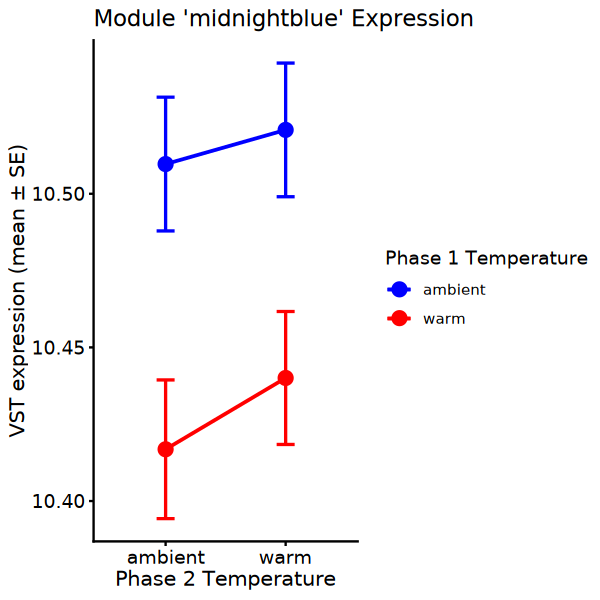

In [98]:
options(repr.plot.width = 5, repr.plot.height = 5)

# 1. Summarise by treatment factors
mb.sd <- midnightblue_vst %>%
  group_by(Phase1_temp, Phase2_temp) %>% 
  summarise(
    meanExp = mean(vst),
    n = n(),
    seExp = sd(vst) / sqrt(n()), # Calculating SE 
    .groups = "drop"
  )

# 2. Plot
ggplot(mb.sd, aes(x = Phase2_temp, y = meanExp, group = Phase1_temp, color = Phase1_temp)) +
  # Lines: 'group' tells ggplot which points to connect
  geom_line(linewidth = 0.8) +
  # Points
  geom_point(size = 3.5) +
  # Error bars
  geom_errorbar(aes(ymin = meanExp - seExp, ymax = meanExp + seExp),
                width = 0.15,
                linewidth = 0.7) +
# color of points
scale_color_manual(values = c("warm" = "red", 
                             "ambient" = "blue")) +
  # Labels
  labs(
    title = "Module 'midnightblue' Expression", 
    x = "Phase 2 Temperature",
    y = "VST expression (mean ± SE)",
    color = "Phase 1 Temperature"
  ) +
  theme_classic() +
  theme(
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12)
  )

in the midnightblue module, phase 1 temperature is correlated with expression of these genes - phase 1 warming is lower than phase 1 ambient temps, regardless of any DO treatment, and regardless of a second (more recent) temperature treatment

taking a closer look at this - splitting apart the samples by DO treatments

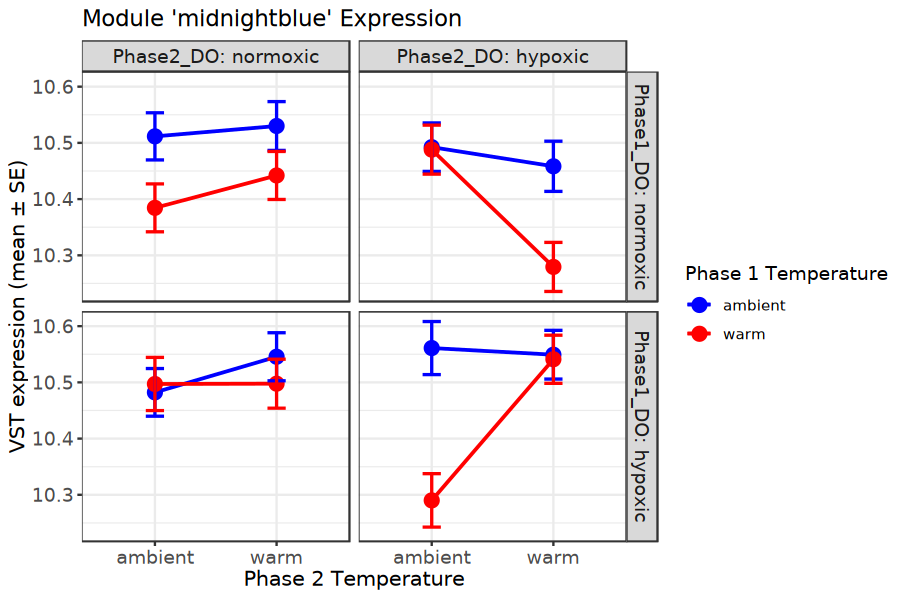

In [99]:
options(repr.plot.width = 7.5, repr.plot.height = 5)

# 1. Summarise by treatment factors
mb.sd <- midnightblue_vst %>%
  group_by(Phase1_temp, Phase2_temp, Phase1_DO, Phase2_DO) %>% 
  summarise(
    meanExp = mean(vst),
    n = n(),
    seExp = sd(vst) / sqrt(n()), # Calculating SE 
    .groups = "drop"
  )

# 2. Plot
ggplot(mb.sd, aes(x = Phase2_temp, y = meanExp, group = Phase1_temp, color = Phase1_temp)) +
  # Lines: 'group' tells ggplot which points to connect
  geom_line(linewidth = 0.8) +
  # Points
  geom_point(size = 3.5) +
facet_grid(Phase1_DO ~ Phase2_DO,
           labeller = labeller(
             Phase1_DO = label_both, 
             Phase2_DO = label_both
           )) + # rows ~ columns
  # Error bars
  geom_errorbar(aes(ymin = meanExp - seExp, ymax = meanExp + seExp),
                width = 0.15,
                linewidth = 0.7) +
scale_color_manual(values = c("warm" = "red", 
                             "ambient" = "blue")) +
  # Labels
  labs(
    title = "Module 'midnightblue' Expression", 
    x = "Phase 2 Temperature",
    y = "VST expression (mean ± SE)",
    color = "Phase 1 Temperature"
  ) +
  theme_bw() +
  theme(
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12),
      strip.text = element_text(size = 11)
  )

when phase 2 DO is hypoxic, we see this shift in expression for the phase 1 warming

when phase 1 DO is hypoxic, phase 1 warming changes depending on the second temperature treatment (increases in warming)

when phase 1 DO is normoxic, phase 1 warming decreases in phase 2 warming

looking at this in another, different way - taking a step back and looking at phase 1 and phase 2 treatments as a whole, facetted by phase 1 temperature)

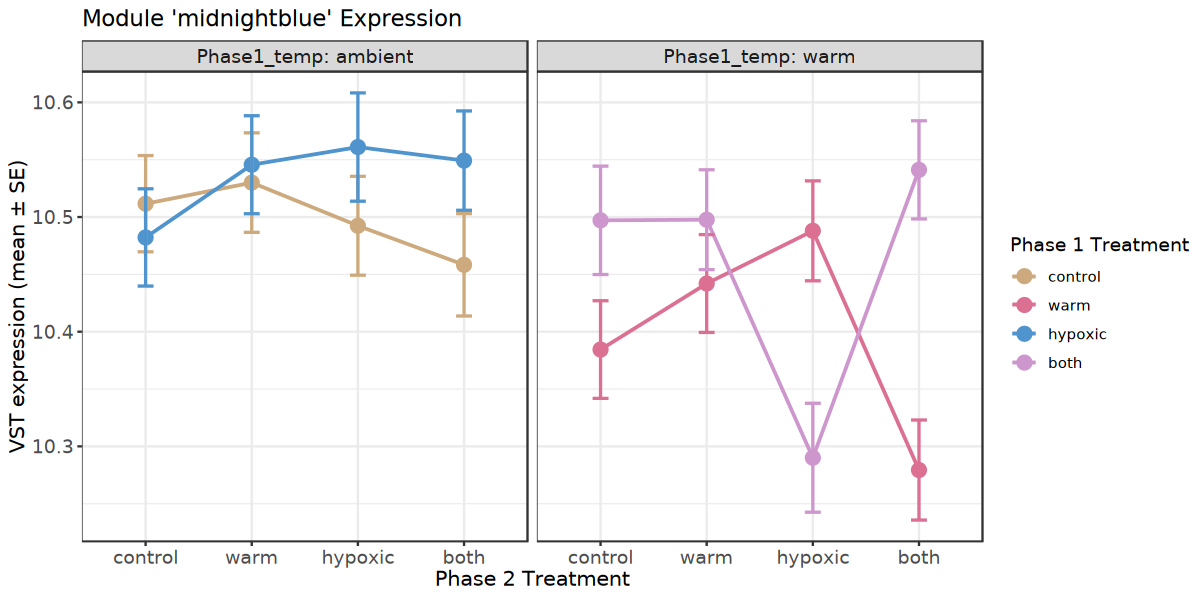

In [100]:
options(repr.plot.width = 10, repr.plot.height = 5)

# 1. Summarise by treatment factors
mb.sd <- midnightblue_vst %>%
  group_by(Phase1_treatment, Phase2_treatment, Phase1_temp) %>% 
  summarise(
    meanExp = mean(vst),
    n = n(),
    seExp = sd(vst) / sqrt(n()), # Calculating SE 
    .groups = "drop"
  )

# 2. Plot
ggplot(mb.sd, aes(x = Phase2_treatment, y = meanExp, group = Phase1_treatment, color = Phase1_treatment)) +
  # Lines: 'group' tells ggplot which points to connect
  geom_line(linewidth = 0.8) +
  # Points
  geom_point(size = 3.5) +
facet_wrap(~Phase1_temp, 
          labeller = label_both
          ) +
  # Error bars
  geom_errorbar(aes(ymin = meanExp - seExp, ymax = meanExp + seExp),
                width = 0.15,
                linewidth = 0.7) +
# colors
scale_color_manual(values = c("hypoxic" = "steelblue3", 
                             "warm" = "palevioletred", 
                             "control" = "burlywood3", 
                             "both" = "plum3")) +
  # Labels
  labs(
    title = "Module 'midnightblue' Expression", 
    x = "Phase 2 Treatment",
    y = "VST expression (mean ± SE)",
    color = "Phase 1 Treatment"
  ) +
  theme_bw() +
  theme(
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12),
      strip.text = element_text(size=11)
  )

so it looks like what's driving warming to be lower is BH and WB treatments - both of these are phase 1 temp = warm, phase 2 DO = hypoxia

#### green module
significant negative correlation with Phase 1 temp (warm)

In [101]:
green_genes <- final_res %>%
  filter(ModuleColor == "green") %>%
  pull(Gene) # This returns just the vector of gene names

head(green_genes)
length(green_genes) # 824 genes in the green module

[1] "LOC111099059" "LOC111099063" "LOC111099123" "LOC111099152" "LOC111099262"
[6] "LOC111099468"

[1] 824

In [102]:
# pull out vst expr for genes in module of interest
green_vst <- vst_expr[,colnames(vst_expr) %in% green_genes] %>%
mutate(Sample = row.names(.)) %>%
  pivot_longer(
    cols = c(1:152), # select gene columns
    names_to = "Gene",
    values_to = "vst"
  ) 

green_vst <- merge(green_vst, meta_merge, by = 'Sample')
    
head(green_vst)
dim(green_vst)

,Sample,LOC111120594,LOC111118546,LOC111119079,LOC111118235,LOC111121254,LOC111119984,LOC111118871,LOC111118872,LOC111117996,⋯,combo_trtmt,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,P1_trtmt_code,P2_trtmt_code,P1_temp_code,P2_temp_code,P1_DO_code,P2_DO_code
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,B1_B1_O01,10.4565,9.390066,8.066342,8.549298,11.13197,10.475,10.46529,8.436148,11.16081,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
2,B1_B1_O01,10.4565,9.390066,8.066342,8.549298,11.13197,10.475,10.46529,8.436148,11.16081,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
3,B1_B1_O01,10.4565,9.390066,8.066342,8.549298,11.13197,10.475,10.46529,8.436148,11.16081,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
4,B1_B1_O01,10.4565,9.390066,8.066342,8.549298,11.13197,10.475,10.46529,8.436148,11.16081,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
5,B1_B1_O01,10.4565,9.390066,8.066342,8.549298,11.13197,10.475,10.46529,8.436148,11.16081,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
6,B1_B1_O01,10.4565,9.390066,8.066342,8.549298,11.13197,10.475,10.46529,8.436148,11.16081,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2


[1] 14136   642

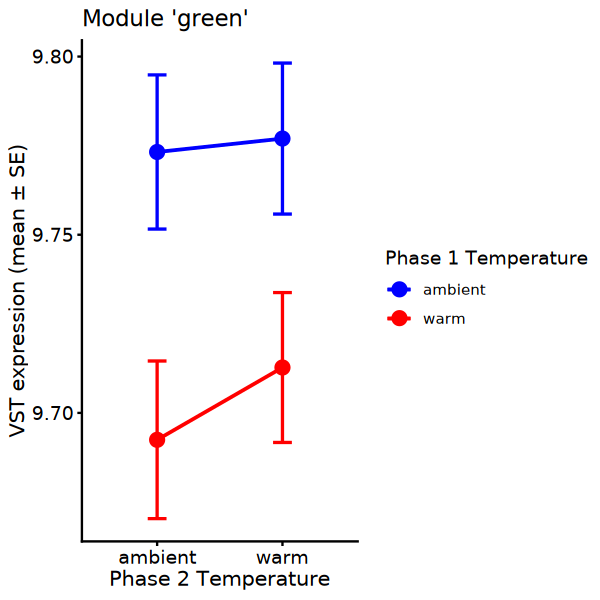

In [103]:
options(repr.plot.width = 5, repr.plot.height = 5)

# 1. Summarise by treatment factors
green.se <- green_vst %>%
  group_by(Phase1_temp, Phase2_temp) %>% 
  summarise(
    meanExp = mean(vst),
    n = n(),
    seExp = sd(vst) / sqrt(n()), # Calculating SE 
    .groups = "drop"
  )

# 2. Plot
ggplot(green.se, aes(x = Phase2_temp, y = meanExp, group = Phase1_temp, color = Phase1_temp)) +
  # Lines: 'group' tells ggplot which points to connect
  geom_line(linewidth = 0.8) +
  # Points
  geom_point(size = 3.5) +
  # Error bars
  geom_errorbar(aes(ymin = meanExp - seExp, ymax = meanExp + seExp),
                width = 0.15,
                linewidth = 0.7) +
# color of points
scale_color_manual(values = c("warm" = "red", 
                             "ambient" = "blue")) +
  # Labels
  labs(
    title = "Module 'green'", 
    x = "Phase 2 Temperature",
    y = "VST expression (mean ± SE)",
    color = "Phase 1 Temperature"
  ) +
  theme_classic() +
  theme(
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12)
  )

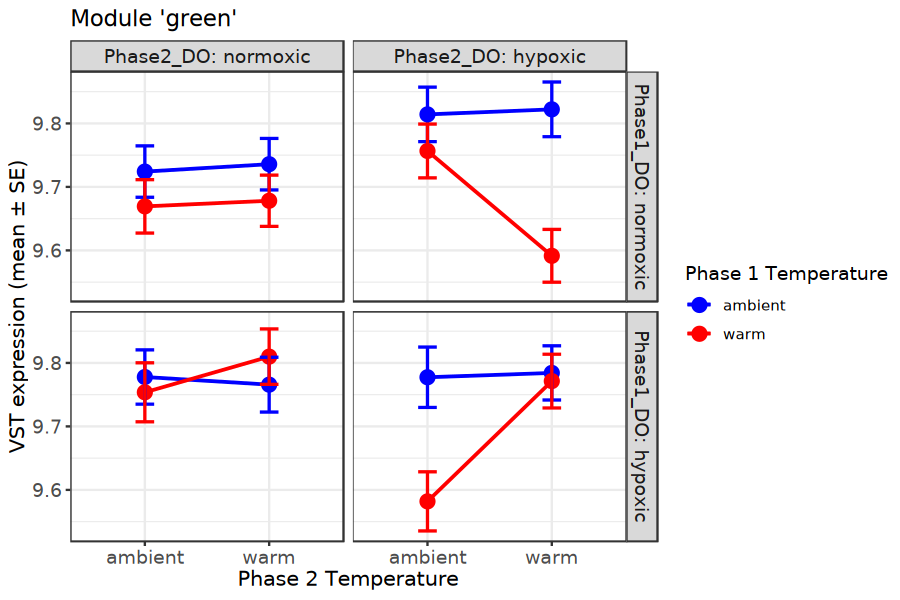

In [104]:
options(repr.plot.width = 7.5, repr.plot.height = 5)

# 1. Summarise by treatment factors
green.se <- green_vst %>%
  group_by(Phase1_temp, Phase2_temp, Phase1_DO, Phase2_DO) %>% 
  summarise(
    meanExp = mean(vst),
    n = n(),
    seExp = sd(vst) / sqrt(n()), # Calculating SE 
    .groups = "drop"
  )

# 2. Plot
ggplot(green.se, aes(x = Phase2_temp, y = meanExp, group = Phase1_temp, color = Phase1_temp)) +
  # Lines: 'group' tells ggplot which points to connect
  geom_line(linewidth = 0.8) +
  # Points
  geom_point(size = 3.5) +
facet_grid(Phase1_DO ~ Phase2_DO,
           labeller = labeller(
             Phase1_DO = label_both, 
             Phase2_DO = label_both
           )) + # rows ~ columns
  # Error bars
  geom_errorbar(aes(ymin = meanExp - seExp, ymax = meanExp + seExp),
                width = 0.15,
                linewidth = 0.7) +
scale_color_manual(values = c("warm" = "red", 
                             "ambient" = "blue")) +
  # Labels
  labs(
    title = "Module 'green'", 
    x = "Phase 2 Temperature",
    y = "VST expression (mean ± SE)",
    color = "Phase 1 Temperature"
  ) +
  theme_bw() +
  theme(
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12),
      strip.text = element_text(size = 11)
  )

looking at this in another, different way - taking a step back and looking at phase 1 and phase 2 treatments as a whole, facetted by phase 1 temperature)

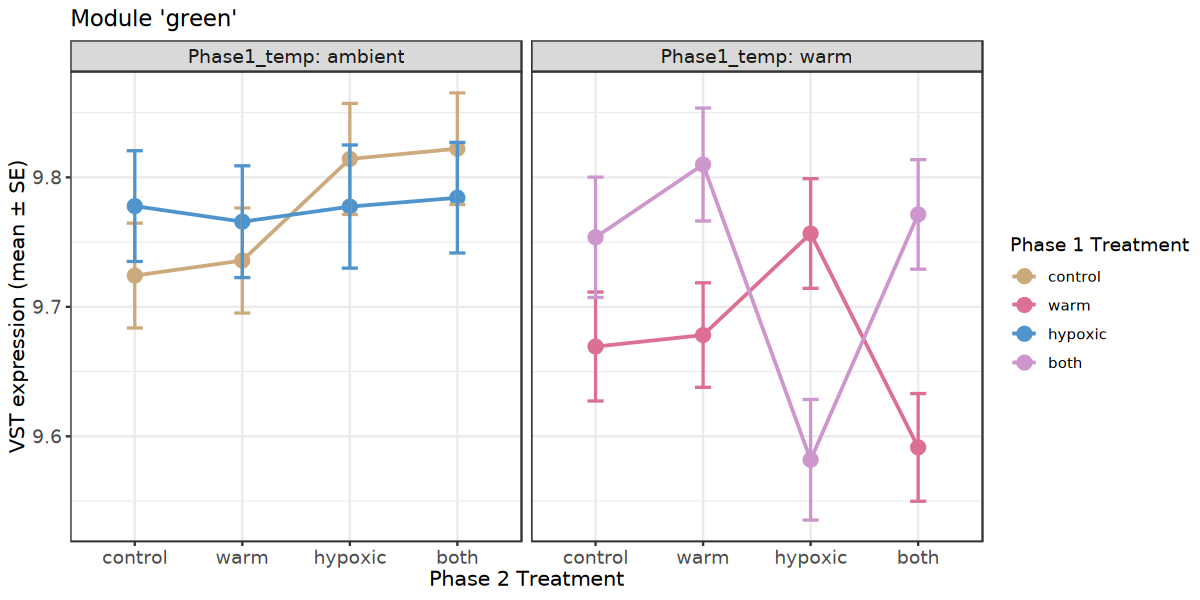

In [105]:
options(repr.plot.width = 10, repr.plot.height = 5)

# 1. Summarise by treatment factors
green.se <- green_vst %>%
  group_by(Phase1_treatment, Phase2_treatment, Phase1_temp) %>% 
  summarise(
    meanExp = mean(vst),
    n = n(),
    seExp = sd(vst) / sqrt(n()), # Calculating SE 
    .groups = "drop"
  )

# 2. Plot
ggplot(green.se, aes(x = Phase2_treatment, y = meanExp, group = Phase1_treatment, color = Phase1_treatment)) +
  # Lines: 'group' tells ggplot which points to connect
  geom_line(linewidth = 0.8) +
  # Points
  geom_point(size = 3.5) +
facet_wrap(~Phase1_temp, 
          labeller = label_both
          ) +
  # Error bars
  geom_errorbar(aes(ymin = meanExp - seExp, ymax = meanExp + seExp),
                width = 0.15,
                linewidth = 0.7) +
# colors
scale_color_manual(values = c("hypoxic" = "steelblue3", 
                             "warm" = "palevioletred", 
                             "control" = "burlywood3", 
                             "both" = "plum3")) +
  # Labels
  labs(
    title = "Module 'green'", 
    x = "Phase 2 Treatment",
    y = "VST expression (mean ± SE)",
    color = "Phase 1 Treatment"
  ) +
  theme_bw() +
  theme(
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12),
      strip.text = element_text(size=11)
  )

there's an interaction of warming and hypoxic when the phase 1 temperature is warming - bc see "movement" in right panel (phase1_temp: warm) and specifically in the phase 2 hypoxic DO treatments (H and B), which deviate from the pattern

#### cyan module
significant positive correlation with Phase 2 temp (warm)

In [106]:
cyan_genes <- final_res %>%
  filter(ModuleColor == "cyan") %>%
  pull(Gene) # This returns just the vector of gene names

head(cyan_genes)
length(cyan_genes) # 249 genes in the midnightblue module

[1] "LOC111099093" "LOC111099138" "LOC111099206" "LOC111099209" "LOC111099845"
[6] "LOC111100294"

[1] 249

In [107]:
# pull out vst expr for genes in module of interest
cyan_vst <- vst_expr[,colnames(vst_expr) %in% cyan_genes] %>%
mutate(Sample = row.names(.)) %>%
  pivot_longer(
    cols = c(1:235), # select gene columns
    names_to = "Gene",
    values_to = "vst"
  ) 

cyan_vst <- merge(cyan_vst, meta_merge, by = 'Sample')
    
head(cyan_vst)
dim(cyan_vst)

,Sample,Gene,vst,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,⋯,combo_trtmt,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,P1_trtmt_code,P2_trtmt_code,P1_temp_code,P2_temp_code,P1_DO_code,P2_DO_code
,<chr>,<chr>,<dbl>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,⋯,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,B1_B1_O01,LOC111101273,10.353823,both,warm,hypoxic,1,both,warm,hypoxic,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
2,B1_B1_O01,LOC111137068,13.556447,both,warm,hypoxic,1,both,warm,hypoxic,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
3,B1_B1_O01,LOC111129311,9.526589,both,warm,hypoxic,1,both,warm,hypoxic,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
4,B1_B1_O01,LOC111134864,13.127496,both,warm,hypoxic,1,both,warm,hypoxic,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
5,B1_B1_O01,LOC111130318,11.830305,both,warm,hypoxic,1,both,warm,hypoxic,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
6,B1_B1_O01,LOC111100444,11.000439,both,warm,hypoxic,1,both,warm,hypoxic,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2


[1] 21855    21

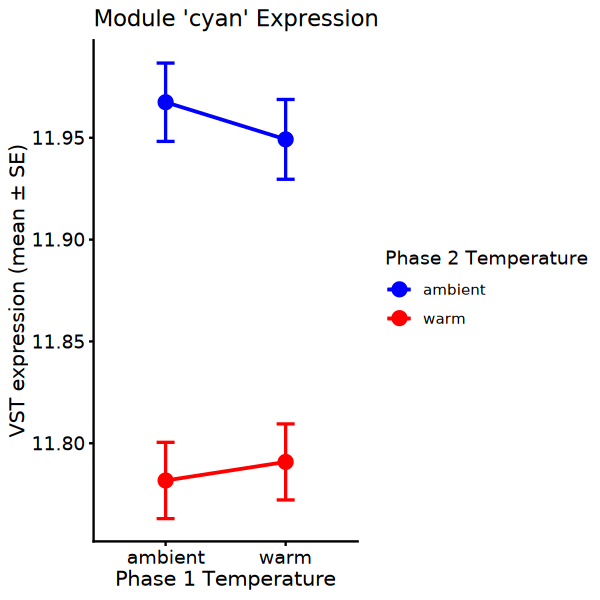

In [108]:
options(repr.plot.width = 5, repr.plot.height = 5)

# 1. Summarise by treatment factors
cyan.se <- cyan_vst %>%
  group_by(Phase1_temp, Phase2_temp) %>% 
  summarise(
    meanExp = mean(vst),
    n = n(),
    seExp = sd(vst) / sqrt(n()), # Calculating SE 
    .groups = "drop"
  )

# 2. Plot
ggplot(cyan.se, aes(x = Phase1_temp, y = meanExp, group = Phase2_temp, color = Phase2_temp)) +
  # Lines: 'group' tells ggplot which points to connect
  geom_line(linewidth = 0.8) +
  # Points
  geom_point(size = 3.5) +
  # Error bars
  geom_errorbar(aes(ymin = meanExp - seExp, ymax = meanExp + seExp),
                width = 0.15,
                linewidth = 0.7) +
# color of points
scale_color_manual(values = c("warm" = "red", 
                             "ambient" = "blue")) +
  # Labels
  labs(
    title = "Module 'cyan' Expression", 
    x = "Phase 1 Temperature",
    y = "VST expression (mean ± SE)",
    color = "Phase 2 Temperature"
  ) +
  theme_classic() +
  theme(
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12)
  )

(be aware that the x-axis and colors are switched in this plot compared to the midnightblue module)

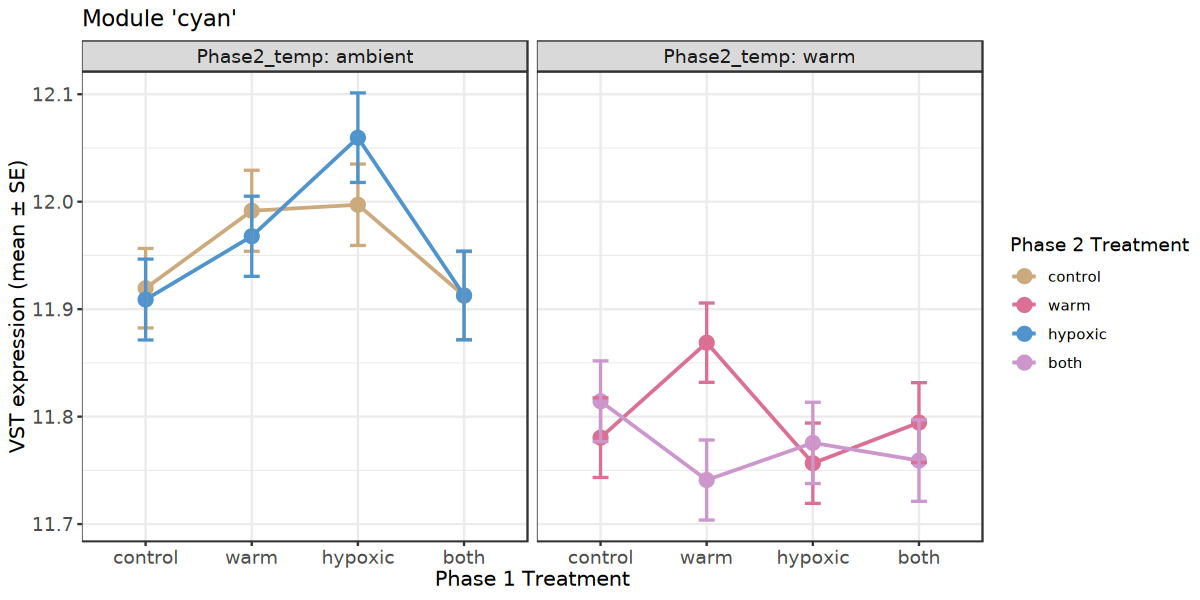

In [109]:
options(repr.plot.width = 10, repr.plot.height = 5)

# 1. Summarise by treatment factors
cyan.se <- cyan_vst %>%
  group_by(Phase1_treatment, Phase2_treatment, Phase2_temp) %>% 
  summarise(
    meanExp = mean(vst),
    n = n(),
    seExp = sd(vst) / sqrt(n()), # Calculating SE 
    .groups = "drop"
  )

# 2. Plot
ggplot(cyan.se, aes(x = Phase1_treatment, y = meanExp, group = Phase2_treatment, color = Phase2_treatment)) +
  # Lines: 'group' tells ggplot which points to connect
  geom_line(linewidth = 0.8) +
  # Points
  geom_point(size = 3.5) +
facet_wrap(~Phase2_temp, 
          labeller = label_both
          ) +
  # Error bars
  geom_errorbar(aes(ymin = meanExp - seExp, ymax = meanExp + seExp),
                width = 0.15,
                linewidth = 0.7) +
# colors
scale_color_manual(values = c("hypoxic" = "steelblue3", 
                             "warm" = "palevioletred", 
                             "control" = "burlywood3", 
                             "both" = "plum3")) +
  # Labels
  labs(
    title = "Module 'cyan'", 
    x = "Phase 1 Treatment",
    y = "VST expression (mean ± SE)",
    color = "Phase 2 Treatment"
  ) +
  theme_bw() +
  theme(
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12),
      strip.text = element_text(size=11)
  )

#### salmon module
significant positive correlation with Phase 2 temp (warm), Phase 2 DO (hypoxic), and treatment (both pos., control neg.)

In [110]:
salmon_genes <- final_res %>%
  filter(ModuleColor == "salmon") %>%
  pull(Gene) # This returns just the vector of gene names

head(salmon_genes)
length(salmon_genes) # 360 genes in the salmon module

[1] "LOC111099033" "LOC111099203" "LOC111099219" "LOC111099585" "LOC111100079"
[6] "LOC111100220"

[1] 360

In [111]:
# pull out vst expr for genes in module of interest
salmon_vst <- vst_expr[,colnames(vst_expr) %in% salmon_genes] %>%
mutate(Sample = row.names(.)) %>%
  pivot_longer(
    cols = c(1:152), # select gene columns
    names_to = "Gene",
    values_to = "vst"
  ) 

salmon_vst <- merge(salmon_vst, meta_merge, by = 'Sample')
    
head(salmon_vst)
dim(salmon_vst)

,Sample,LOC111131531,LOC111131530,LOC111131668,LOC111129912,LOC111131016,LOC111130324,LOC111131301,LOC111130164,LOC111127797,⋯,combo_trtmt,Actual_shell_growth_mg,Actual_tissue_growth_mg,Ratio_tissue_shell_mg,P1_trtmt_code,P2_trtmt_code,P1_temp_code,P2_temp_code,P1_DO_code,P2_DO_code
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,B1_B1_O01,10.40459,11.17737,13.37732,11.17325,8.774183,10.83913,12.49844,13.37452,10.11224,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
2,B1_B1_O01,10.40459,11.17737,13.37732,11.17325,8.774183,10.83913,12.49844,13.37452,10.11224,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
3,B1_B1_O01,10.40459,11.17737,13.37732,11.17325,8.774183,10.83913,12.49844,13.37452,10.11224,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
4,B1_B1_O01,10.40459,11.17737,13.37732,11.17325,8.774183,10.83913,12.49844,13.37452,10.11224,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
5,B1_B1_O01,10.40459,11.17737,13.37732,11.17325,8.774183,10.83913,12.49844,13.37452,10.11224,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2
6,B1_B1_O01,10.40459,11.17737,13.37732,11.17325,8.774183,10.83913,12.49844,13.37452,10.11224,⋯,both_both,210.2755,120.7245,0.574125224,4,4,2,2,2,2


[1] 14136   218

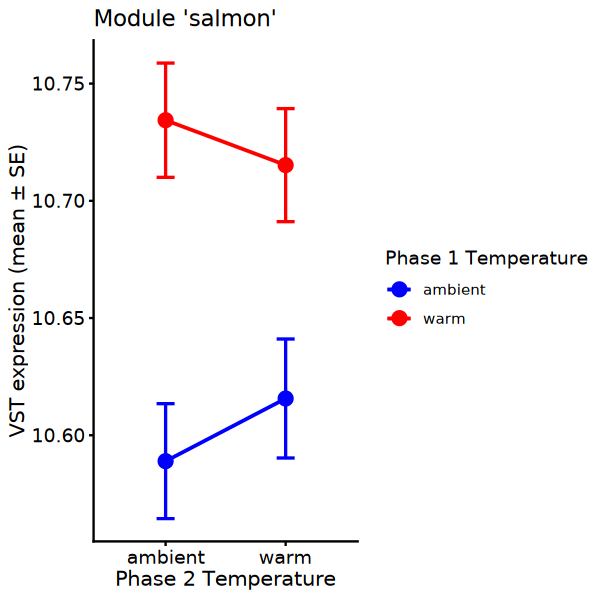

In [112]:
options(repr.plot.width = 5, repr.plot.height = 5)

# 1. Summarise by treatment factors
salmon.se <- salmon_vst %>%
  group_by(Phase1_temp, Phase2_temp) %>% 
  summarise(
    meanExp = mean(vst),
    n = n(),
    seExp = sd(vst) / sqrt(n()), # Calculating SE 
    .groups = "drop"
  )

# 2. Plot
ggplot(salmon.se, aes(x = Phase1_temp, y = meanExp, group = Phase2_temp, color = Phase2_temp)) +
  # Lines: 'group' tells ggplot which points to connect
  geom_line(linewidth = 0.8) +
  # Points
  geom_point(size = 3.5) +
  # Error bars
  geom_errorbar(aes(ymin = meanExp - seExp, ymax = meanExp + seExp),
                width = 0.15,
                linewidth = 0.7) +
# color of points
scale_color_manual(values = c("warm" = "red", 
                             "ambient" = "blue")) +
  # Labels
  labs(
    title = "Module 'salmon'", 
    x = "Phase 2 Temperature",
    y = "VST expression (mean ± SE)",
    color = "Phase 1 Temperature"
  ) +
  theme_classic() +
  theme(
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12)
  )

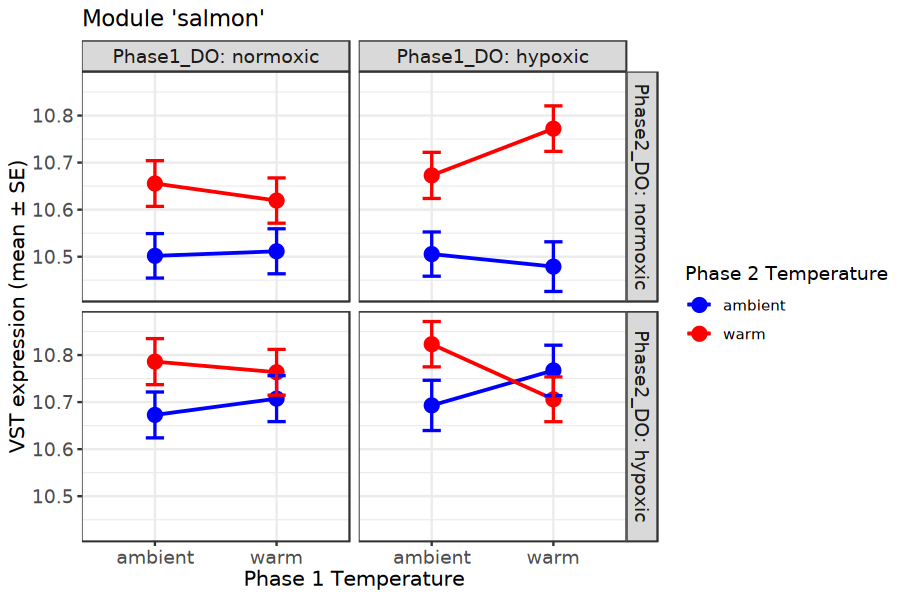

In [113]:
options(repr.plot.width = 7.5, repr.plot.height = 5)

# 1. Summarise by treatment factors
salmon.se <- salmon_vst %>%
  group_by(Phase1_temp, Phase2_temp, Phase1_DO, Phase2_DO) %>% 
  summarise(
    meanExp = mean(vst),
    n = n(),
    seExp = sd(vst) / sqrt(n()), # Calculating SE 
    .groups = "drop"
  )

# 2. Plot
ggplot(salmon.se, aes(x = Phase1_temp, y = meanExp, group = Phase2_temp, color = Phase2_temp)) +
  # Lines: 'group' tells ggplot which points to connect
  geom_line(linewidth = 0.8) +
  # Points
  geom_point(size = 3.5) +
facet_grid(Phase2_DO ~ Phase1_DO,
           labeller = labeller(
             Phase1_DO = label_both, 
             Phase2_DO = label_both
           )) + # rows ~ columns
  # Error bars
  geom_errorbar(aes(ymin = meanExp - seExp, ymax = meanExp + seExp),
                width = 0.15,
                linewidth = 0.7) +
scale_color_manual(values = c("warm" = "red", 
                             "ambient" = "blue")) +
  # Labels
  labs(
    title = "Module 'salmon'", 
    x = "Phase 1 Temperature",
    y = "VST expression (mean ± SE)",
    color = "Phase 2 Temperature"
  ) +
  theme_bw() +
  theme(
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12),
      strip.text = element_text(size = 11)
  )

expression in the salmon module seems to increase or decrease with phase 2 temp depending on the DO - don't see much change when phase 1 DO is normoxic

looking at this in another, different way - taking a step back and looking at phase 1 and phase 2 treatments as a whole, facetted by phase 1 temperature)

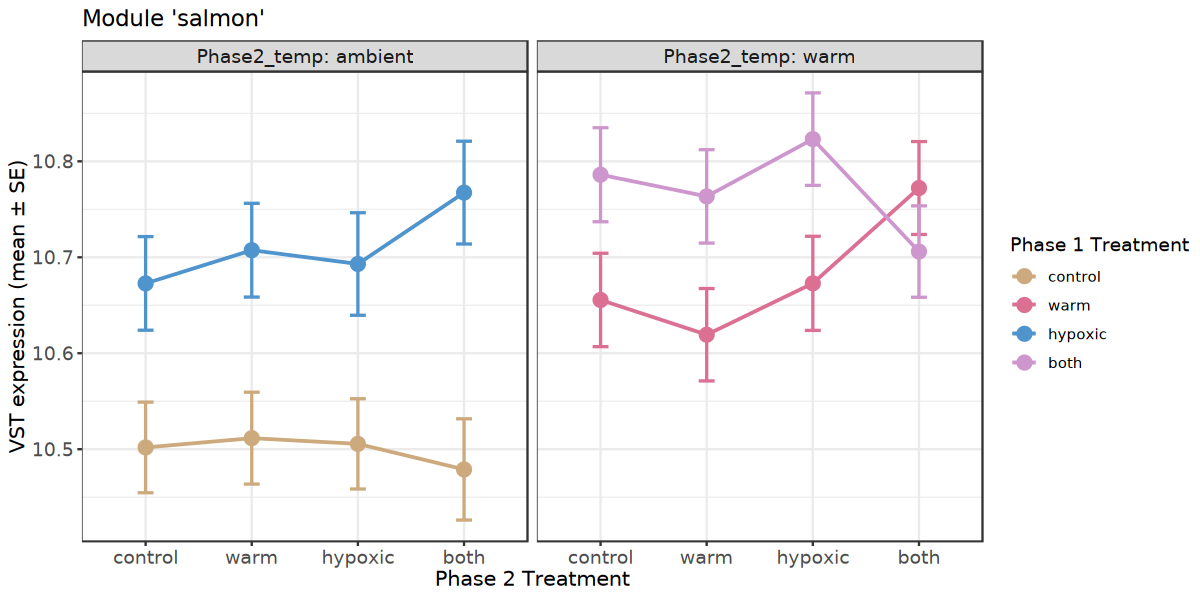

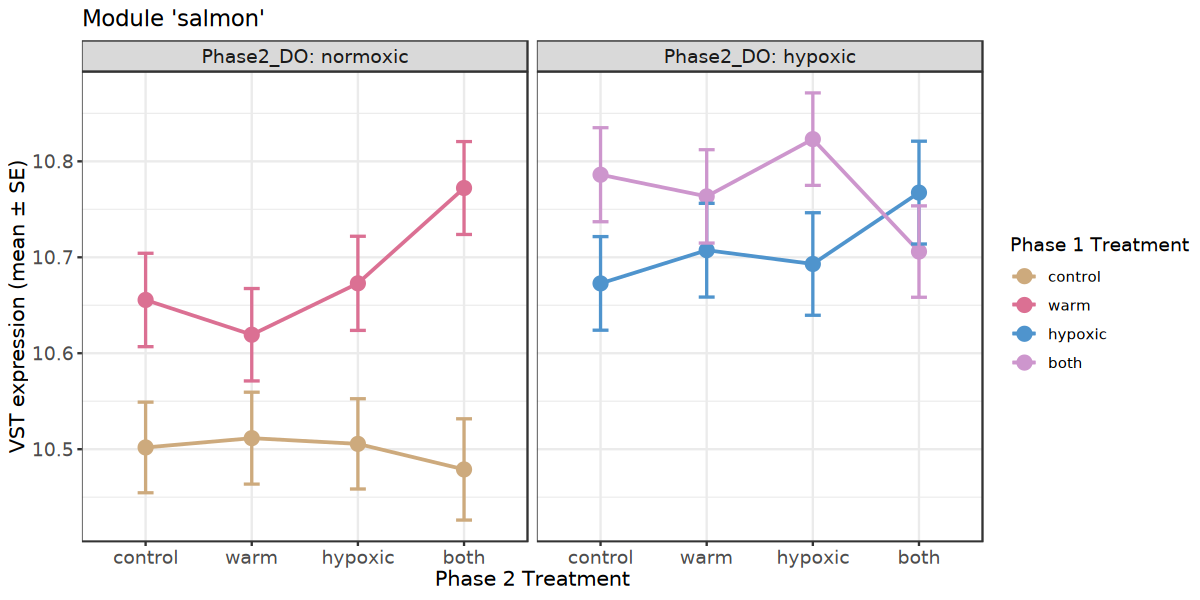

In [114]:
options(repr.plot.width = 10, repr.plot.height = 5)

# 1. Summarise by treatment factors
salmon.se <- salmon_vst %>%
  group_by(Phase1_treatment, Phase2_treatment, Phase2_temp, Phase2_DO) %>% 
  summarise(
    meanExp = mean(vst),
    n = n(),
    seExp = sd(vst) / sqrt(n()), # Calculating SE 
    .groups = "drop"
  )

# 2. Plot
#### FACETING BY PHASE 2 TEMP
ggplot(salmon.se, aes(x = Phase1_treatment, y = meanExp, group = Phase2_treatment, color = Phase2_treatment)) +
  # Lines: 'group' tells ggplot which points to connect
  geom_line(linewidth = 0.8) +
  # Points
  geom_point(size = 3.5) +
facet_wrap(~Phase2_temp, 
          labeller = label_both
          ) +
  # Error bars
  geom_errorbar(aes(ymin = meanExp - seExp, ymax = meanExp + seExp),
                width = 0.15,
                linewidth = 0.7) +
# colors
scale_color_manual(values = c("hypoxic" = "steelblue3", 
                             "warm" = "palevioletred", 
                             "control" = "burlywood3", 
                             "both" = "plum3")) +
  # Labels
  labs(
    title = "Module 'salmon'", 
    x = "Phase 2 Treatment",
    y = "VST expression (mean ± SE)",
    color = "Phase 1 Treatment"
  ) +
  theme_bw() +
  theme(
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12),
      strip.text = element_text(size=11)
  )

# 2. Plot
#### FACETING BY PHASE 2 DO
ggplot(salmon.se, aes(x = Phase1_treatment, y = meanExp, group = Phase2_treatment, color = Phase2_treatment)) +
  # Lines: 'group' tells ggplot which points to connect
  geom_line(linewidth = 0.8) +
  # Points
  geom_point(size = 3.5) +
facet_wrap(~Phase2_DO, 
          labeller = label_both
          ) +
  # Error bars
  geom_errorbar(aes(ymin = meanExp - seExp, ymax = meanExp + seExp),
                width = 0.15,
                linewidth = 0.7) +
# colors
scale_color_manual(values = c("hypoxic" = "steelblue3", 
                             "warm" = "palevioletred", 
                             "control" = "burlywood3", 
                             "both" = "plum3")) +
  # Labels
  labs(
    title = "Module 'salmon'", 
    x = "Phase 2 Treatment",
    y = "VST expression (mean ± SE)",
    color = "Phase 1 Treatment"
  ) +
  theme_bw() +
  theme(
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12),
      strip.text = element_text(size=11)
  )